# **Data Understanding**

Dataset penjualan Adidas adalah kumpulan data yang mencakup informasi mengenai penjualan produk-produk Adidas. Dataset ini biasanya berisi berbagai detail, seperti jumlah unit yang terjual, total pendapatan penjualan, lokasi penjualan, jenis produk yang dijual, serta informasi relevan lainnya.

Data penjualan Adidas dapat dimanfaatkan untuk berbagai keperluan, seperti menganalisis tren penjualan dari waktu ke waktu, mengidentifikasi produk atau kampanye pemasaran yang paling berhasil, serta menyusun strategi untuk meningkatkan penjualan di masa depan. Misalnya, jika data menunjukkan bahwa sepatu lari Adidas lebih laku di wilayah perkotaan daripada pedesaan, maka strategi distribusi atau iklan bisa disesuaikan berdasarkan temuan tersebut.

Selain itu, dataset ini juga dapat digunakan untuk membandingkan performa penjualan Adidas dengan pesaingnya, atau untuk mengevaluasi efektivitas berbagai saluran pemasaran dan penjualan—baik secara online maupun offline.

Sumber data penjualan Adidas bisa berasal dari berbagai pihak, seperti perusahaan Adidas itu sendiri, lembaga riset pasar, instansi pemerintah, maupun organisasi lain yang melakukan pelacakan data penjualan. Namun, poin-poin data yang tersedia dalam dataset dapat bervariasi tergantung dari siapa sumbernya dan tujuan penggunaannya.

# **Install and Load Packages**

In [1806]:
!pip install sktime[all_extras]

In [1807]:
# utilities packages
import datetime

# data wrangling and transformation package
import numpy as np
import pandas as pd
import statsmodels.api as sm

# data visualization package
import matplotlib.pyplot as plt
import seaborn as sns

# time series modeling
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from statsmodels.stats.diagnostic import acorr_ljungbox

# load sktime for time series forecasting
from sktime.utils.plotting import plot_series # from plotting
from sktime.forecasting.naive import NaiveForecaster # for naive forecasting
from sktime.forecasting.arima import AutoARIMA # for automated ARIMA forecasting
from sktime.forecasting.exp_smoothing import ExponentialSmoothing # for exponential smoothing forecasting
from sktime.forecasting.ets import AutoETS # for automated ETS forecasting
from sktime.forecasting.tbats import TBATS # for TBATS forecasting
from sktime.forecasting.fbprophet import Prophet # for Prophet forecasting
from sktime.forecasting.base import ForecastingHorizon # for creating forecast horizon
from sktime.forecasting.model_selection import (
    temporal_train_test_split,
    ExpandingWindowSplitter,
    SlidingWindowSplitter
) # for train-test split and cross validation
from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
) # for evaluation metrics
from sktime.forecasting.model_evaluation import evaluate # for evaluating CV results

%matplotlib inline

# **Load Dataset**

In [1808]:
df = pd.read_csv('C:/DIBIMBING/adidas_us.csv')

In [1809]:
df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,1/1/2020,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","$600,000","$300,000",50%,In-store
1,Foot Locker,1185732,1/2/2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","$500,000","$150,000",30%,In-store
2,Foot Locker,1185732,1/3/2020,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","$400,000","$140,000",35%,In-store
3,Foot Locker,1185732,1/4/2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"$382,500","$133,875",35%,In-store
4,Foot Locker,1185732,1/5/2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"$540,000","$162,000",30%,In-store


# **Data Cleaning**

In [1810]:
# Menampilkan baris yang memiliki duplikat berdasarkan semua kolom
df.duplicated().sum()

0

In [1811]:
# Melihat jumlah rows dan columns
df.shape

(9648, 13)

In [1812]:
# Format data cleaning
df['Price per Unit'] = df['Price per Unit'].replace('[\$,]', '', regex=True).astype(float)
df['Total Sales'] = df['Total Sales'].replace('[\$,]', '', regex=True).astype(float)
df['Operating Profit'] = df['Operating Profit'].replace('[\$,]', '', regex=True).astype(float)
df['Operating Margin'] = df['Operating Margin'].replace('%', '', regex=True).astype(float)
df['Units Sold'] = df['Units Sold'].replace('[,]', '', regex=True).astype(int)

In [1813]:
# Melihat tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Retailer          9648 non-null   object 
 1   Retailer ID       9648 non-null   int64  
 2   Invoice Date      9648 non-null   object 
 3   Region            9648 non-null   object 
 4   State             9648 non-null   object 
 5   City              9648 non-null   object 
 6   Product           9648 non-null   object 
 7   Price per Unit    9648 non-null   float64
 8   Units Sold        9648 non-null   int32  
 9   Total Sales       9648 non-null   float64
 10  Operating Profit  9648 non-null   float64
 11  Operating Margin  9648 non-null   float64
 12  Sales Method      9648 non-null   object 
dtypes: float64(4), int32(1), int64(1), object(7)
memory usage: 942.3+ KB


In [1814]:
# Mengecek Missing Values
df.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

# **Data Preprocessing**

In [1815]:
# Convert 'Invoice Date' column to datetime format and extract year, month, day columns
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['year'] = df['Invoice Date'].dt.year
df['month'] = df['Invoice Date'].dt.month
df['day'] = df['Invoice Date'].dt.day

In [1816]:
# Display basic information and statistics about the data
print(df.info(),end='\n\n')
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int32         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
 13  year              9648 non-null   int32         
 14  month             9648 n

# **Exploratory Data Analysis**

1. Berapakah total penjualan pada masing-masing region?
2. Bagaimana pembagian metode penjualannya?
3. Apa saja Top Produk dengan total penjualan terbanyak?
4. Region mana yang mendapatkan profit operasional terbesar?
5. Berapa jumlah transaksi pada masing-masing retailers?
6. Berapa besar market share yang dimiliki oleh masing-masing retailers berdasarkan total sales?
7. Bagaimana total penjualan pada masing-masing retailers berdasarkan region?
8. Bagaimana tren total sales dan units sold berdasarkan tahun dan bulan?
9. Bagaimana tren total sales dan units sold berdasarkan hari?

### **1. Berapakah total penjualan pada masing-masing region?**

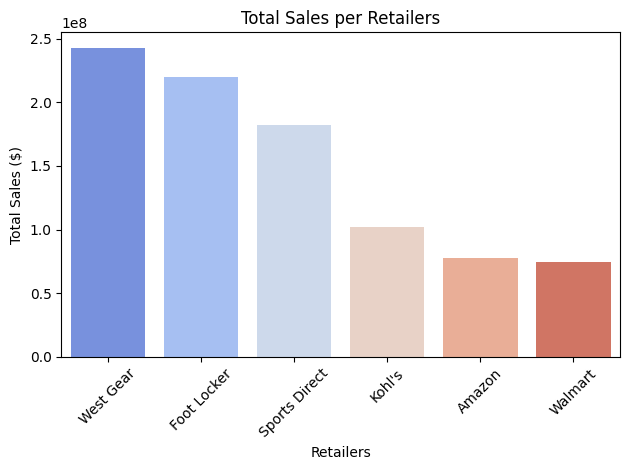

In [1817]:
# Grouping data by Region and summing Total Sales
region_sales = df.groupby('Retailer')['Total Sales'].sum().sort_values(ascending=False)


sns.barplot(x=region_sales.index, y=region_sales.values, palette="coolwarm")
plt.title("Total Sales per Retailers")
plt.xlabel("Retailers")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [1818]:
retailer_sales = df.groupby("Retailer")["Total Sales"].sum()
print(retailer_sales)

Retailer
Amazon            77698912.0
Foot Locker      220094720.0
Kohl's           102114753.0
Sports Direct    182470997.0
Walmart           74558410.0
West Gear        242964333.0
Name: Total Sales, dtype: float64


### **2. Bagaimana pembagian metode penjualannya?**

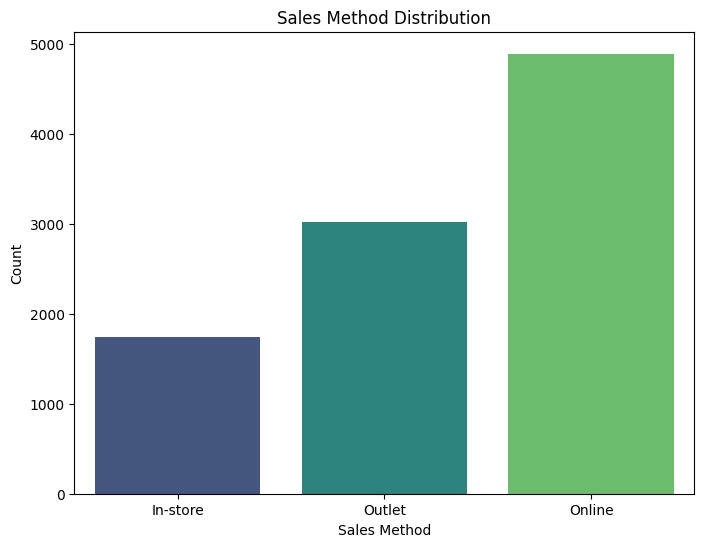

In [1819]:
# Count plot for Sales Method
plt.figure(figsize=(8, 6))
sns.countplot(x='Sales Method', data=df, palette='viridis')
plt.title('Sales Method Distribution')
plt.xlabel('Sales Method')
plt.ylabel('Count')
plt.show()

In [1820]:
# Hitung jumlah masing-masing metode penjualan
sales_method_counts = df['Sales Method'].value_counts()
print(sales_method_counts)

Sales Method
Online      4889
Outlet      3019
In-store    1740
Name: count, dtype: int64


### **3. Apa saja Produk dengan total penjualan terbanyak?**

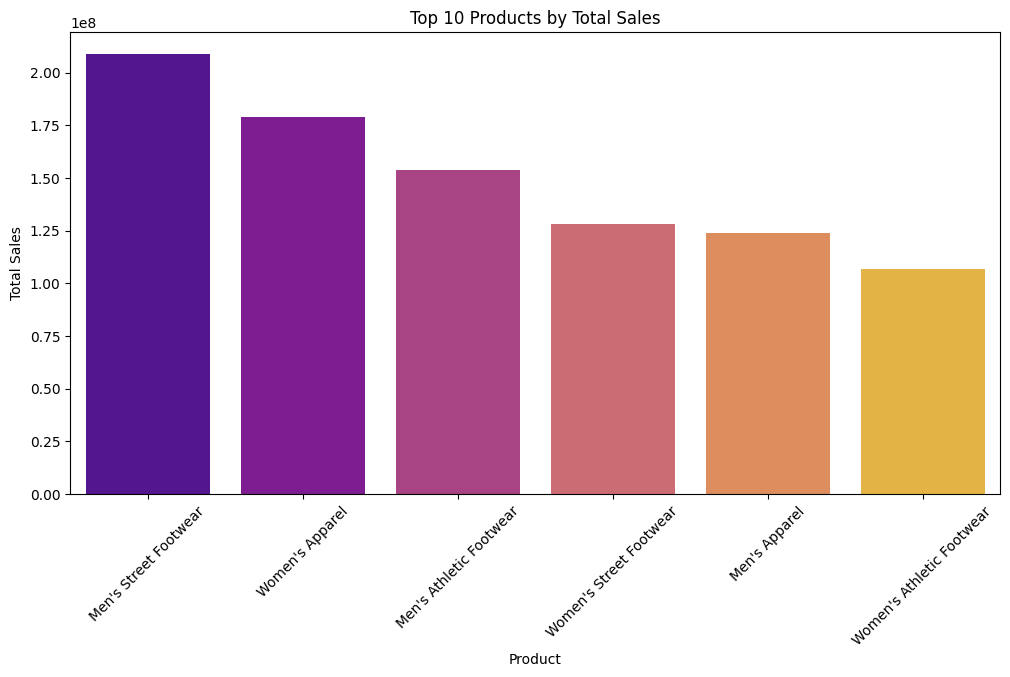

In [1821]:
# Grouping data by Product and summing Total Sales
product_sales = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).head(10)

# Creating a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=product_sales.index, y=product_sales.values, palette='plasma')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [1822]:
product_sales

Product
Men's Street Footwear        208826244.0
Women's Apparel              179038860.0
Men's Athletic Footwear      153673680.0
Women's Street Footwear      128002813.0
Men's Apparel                123728632.0
Women's Athletic Footwear    106631896.0
Name: Total Sales, dtype: float64

### **4. Region mana yang mendapatkan profit operasional terbesar?**

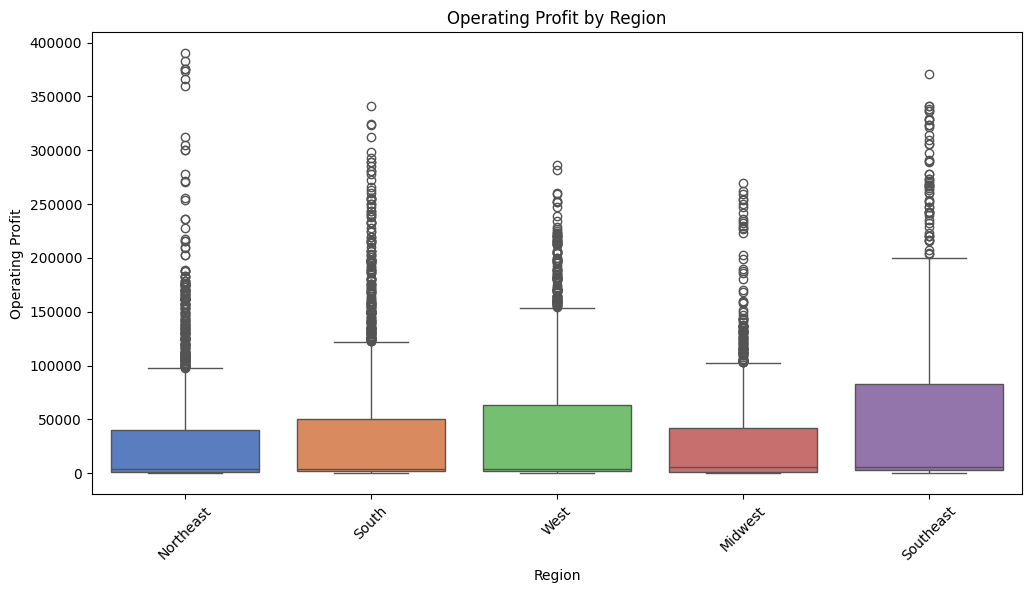

In [1823]:
# Box plot for Operating Profit by Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Operating Profit', data=df, palette='muted')
plt.title('Operating Profit by Region')
plt.xticks(rotation=45)
plt.show()

In [1824]:
# Hitung jumlah data Operating Profit per Region (tanpa NaN)
region_profit_counts = df.groupby('Region')['Operating Profit'].count()
print(region_profit_counts)


Region
Midwest      1872
Northeast    2376
South        1728
Southeast    1224
West         2448
Name: Operating Profit, dtype: int64


### **5.Berapa jumlah transaksi pada masing-masing retailers?**

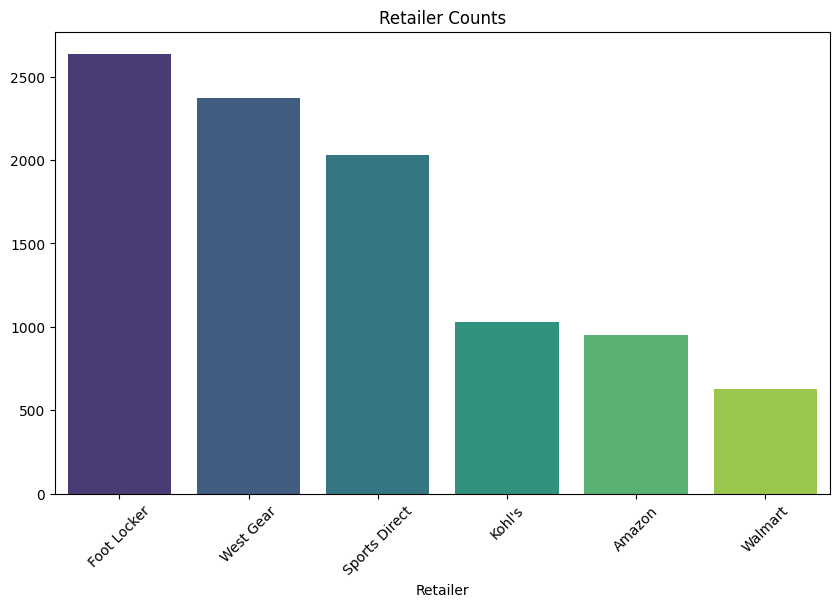

In [1825]:
# Analysis and visualization of retailer counts
retailer_counts = df['Retailer'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=retailer_counts.index, y=retailer_counts.values, hue=retailer_counts.index, dodge=False, palette='viridis')
plt.title('Retailer Counts')
plt.xticks(rotation=45)
plt.show()

### **6. Berapa besar market share yang dimiliki oleh masing-masing retailers berdasarkan total sales?**

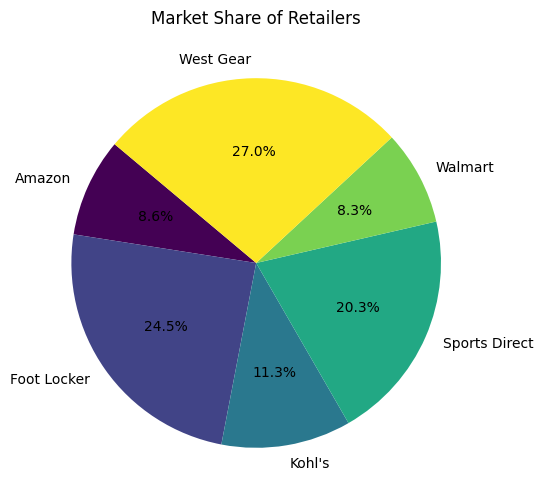

In [1826]:
# Analysis and visualization of retailer market share
retailer_sales = df.groupby('Retailer')['Total Sales'].sum()
total_sales = retailer_sales.sum()
market_share = retailer_sales / total_sales

plt.figure(figsize=(10, 6))
market_share.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='viridis')
plt.title('Market Share of Retailers')
plt.ylabel('')
plt.show()

### **7. Bagaimana total penjualan pada masing-masing retailers berdasarkan region?**

<Figure size 1200x600 with 0 Axes>

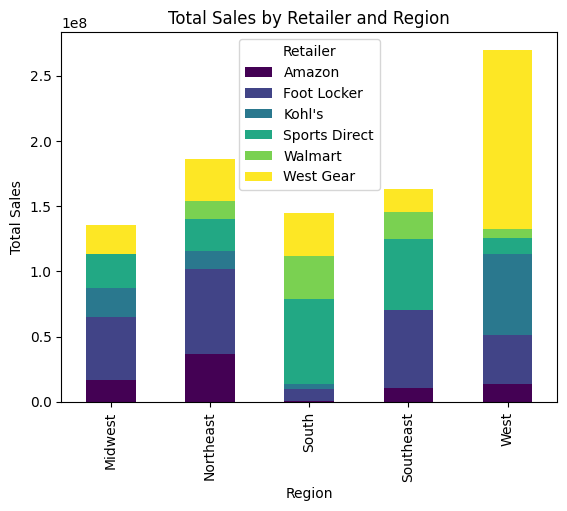

In [1827]:
# Total sales by retailer and region
retailer_sales_by_region = df.groupby(['Retailer', 'Region'])['Total Sales'].sum().unstack(level=0)

plt.figure(figsize=(12, 6))
retailer_sales_by_region.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Total Sales by Retailer and Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.legend(title='Retailer')
plt.show()

### **8. Bagaimana tren total sales dan units sold berdasarkan tahun dan bulan?**

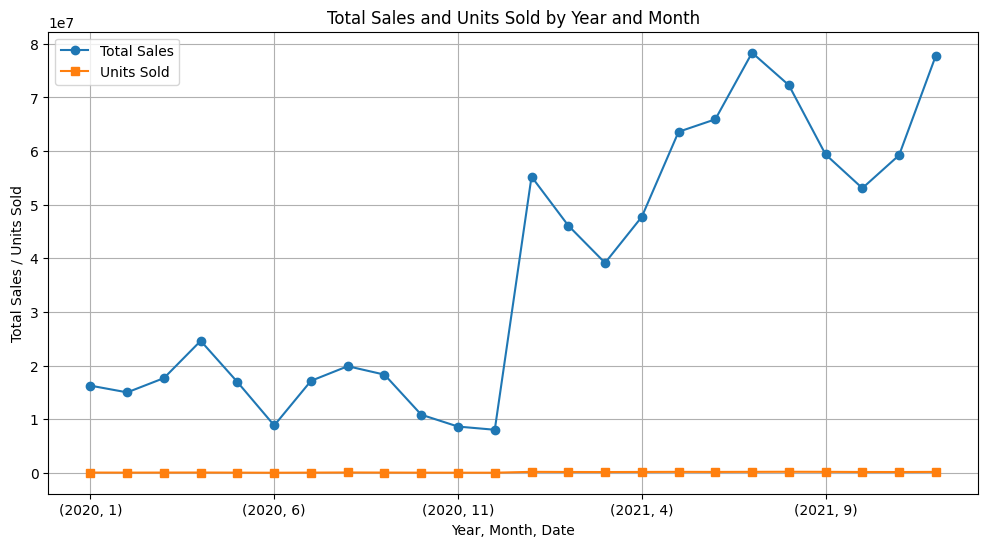

In [1828]:
# Ekstrak tahun dan bulan dari 'Invoice Date'
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['year'] = df['Invoice Date'].dt.year
df['month'] = df['Invoice Date'].dt.month

# Hitung total sales dan units sold per tahun dan bulan
sales_by_year_month = df.groupby(['year', 'month'])['Total Sales'].sum()
units_by_year_month = df.groupby(['year', 'month'])['Units Sold'].sum()

# Visualisasikan
plt.figure(figsize=(12, 6))
sales_by_year_month.plot(label='Total Sales', marker='o')
units_by_year_month.plot(label='Units Sold', marker='s')
plt.title('Total Sales and Units Sold by Year and Month')
plt.xlabel('Year, Month, Date')
plt.ylabel('Total Sales / Units Sold')
plt.legend()
plt.grid(True)
plt.show()

### **9. Bagaimana tren total sales dan units sold berdasarkan hari?**

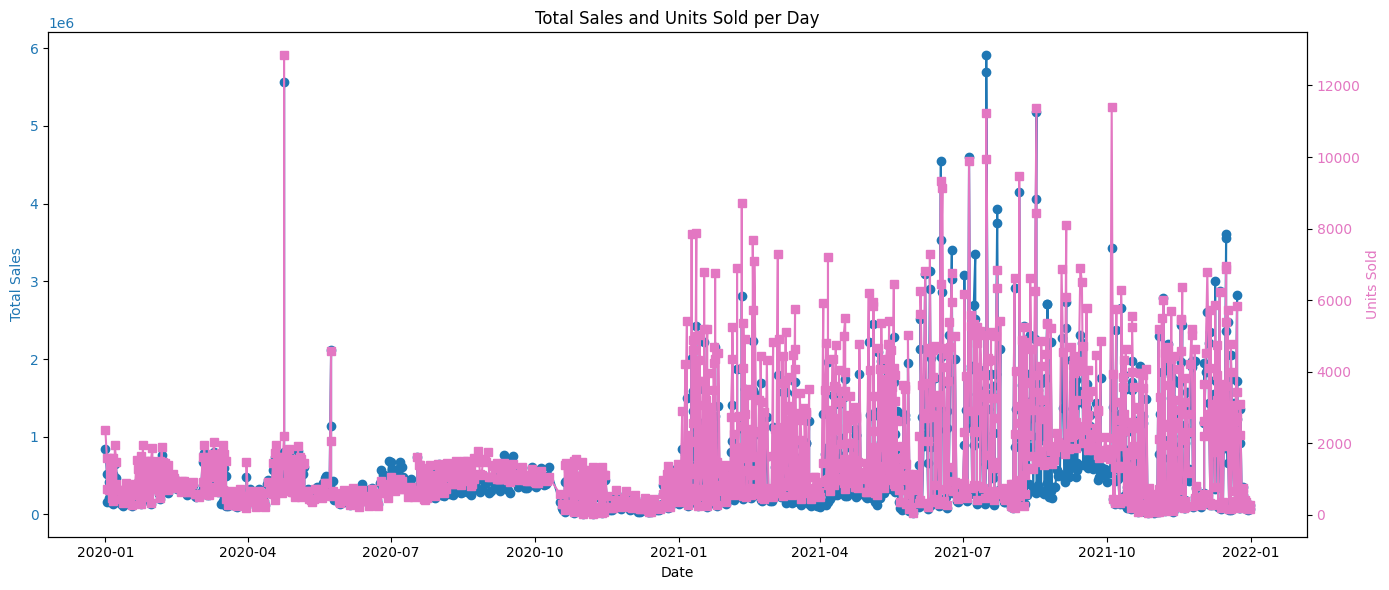

In [1829]:
# Ekstrak tanggal lengkap (tahun, bulan, hari)
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['year'] = df['Invoice Date'].dt.year
df['month'] = df['Invoice Date'].dt.month
df['day'] = df['Invoice Date'].dt.day

# Group by Retailer + Tanggal
sales_by_day = df.groupby(['Retailer', 'year', 'month', 'day'])['Total Sales'].sum()
units_by_day = df.groupby(['Retailer', 'year', 'month', 'day'])['Units Sold'].sum()

# Gabungkan ke dalam dataframe untuk visualisasi
daily_df = pd.DataFrame({
    'Total Sales': sales_by_day,
    'Units Sold': units_by_day
}).reset_index()

# Gabungkan kolom tahun, bulan, hari jadi satu kolom datetime
daily_df['Date'] = pd.to_datetime(daily_df[['year', 'month', 'day']])

# Sortir berdasarkan tanggal
daily_df.sort_values('Date', inplace=True)

import matplotlib.pyplot as plt

# Visualisasi dengan dua sumbu Y
fig, ax1 = plt.subplots(figsize=(14, 6))

# Sumbu pertama (y1) untuk Total Sales
ax1.plot(daily_df['Date'], daily_df['Total Sales'], label='Total Sales (Daily)', marker='o', color='tab:blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Sales', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Membuat sumbu kedua (y2) untuk Units Sold
ax2 = ax1.twinx()
ax2.plot(daily_df['Date'], daily_df['Units Sold'], label='Units Sold (Daily)', marker='s', color='tab:pink')
ax2.set_ylabel('Units Sold', color='tab:pink')
ax2.tick_params(axis='y', labelcolor='tab:pink')

# Menambahkan judul dan grid
plt.title('Total Sales and Units Sold per Day')
fig.tight_layout()

# Menampilkan grafik
plt.show()


In [1830]:
daily_df.head()

,Retailer,year,month,day,Total Sales,Units Sold,Date
103,Foot Locker,2020,1,1,845141.0,2361,2020-01-01
104,Foot Locker,2020,1,2,523740.0,1580,2020-01-02
979,West Gear,2020,1,2,165670.0,730,2020-01-02
105,Foot Locker,2020,1,3,420200.0,1600,2020-01-03
980,West Gear,2020,1,3,212373.0,702,2020-01-03


# **Forecasting Model**

## **ARIMA**

### Data Preprocessing

In [1831]:
# Daftar nama retailer
retailer_names = ["Foot Locker", "Amazon", "Kohl's", "Sports Direct", "Walmart", "West Gear"]

# Fungsi bantu untuk menambahkan kolom tanggal dan set index
def add_period_index(df):
    df['Year-Month_Day'] = df['year'].astype(str) + '-' + \
                           df['month'].astype(str).str.zfill(2) + '_' + \
                           df['day'].astype(str).str.zfill(2)
    df.set_index('Year-Month_Day', inplace=True)
    df.index = pd.PeriodIndex(df.index.str.replace('_', '-'), freq='D')
    return df

# Buat masing-masing DataFrame
footlocker_df = add_period_index(daily_df[daily_df["Retailer"] == "Foot Locker"].copy())
amazon_df = add_period_index(daily_df[daily_df["Retailer"] == "Amazon"].copy())
kohls_df = add_period_index(daily_df[daily_df["Retailer"] == "Kohl's"].copy())
sportsdirect_df = add_period_index(daily_df[daily_df["Retailer"] == "Sports Direct"].copy())
walmart_df = add_period_index(daily_df[daily_df["Retailer"] == "Walmart"].copy())
westgear_df = add_period_index(daily_df[daily_df["Retailer"] == "West Gear"].copy())

# Cek salah satu
footlocker_df.head()

,Retailer,year,month,day,Total Sales,Units Sold,Date
Year-Month_Day,,,,,,,
2020-01-01,Foot Locker,2020,1,1,845141.0,2361,2020-01-01
2020-01-02,Foot Locker,2020,1,2,523740.0,1580,2020-01-02
2020-01-03,Foot Locker,2020,1,3,420200.0,1600,2020-01-03
2020-01-04,Foot Locker,2020,1,4,402743.0,1378,2020-01-04
2020-01-05,Foot Locker,2020,1,5,566028.0,1440,2020-01-05


In [1832]:
def to_weekly(df):
    # Pastikan kolom 'Date' jadi index
    df = df.copy()
    df.set_index('Date', inplace=True)
    
    # Hanya agregasi kolom numerik
    numeric_df = df.select_dtypes(include='number')
    
    # Resample mingguan
    weekly_df = numeric_df.resample('W').sum()
    return weekly_df

In [1833]:
footlocker_weekly = to_weekly(footlocker_df)
amazon_weekly = to_weekly(amazon_df)
kohls_weekly = to_weekly(kohls_df)
sportsdirect_weekly = to_weekly(sportsdirect_df)
walmart_weekly = to_weekly(walmart_df)
westgear_weekly = to_weekly(westgear_df)


### **ARIMA for Foot Locker**

### Prediction

**Units Sold**

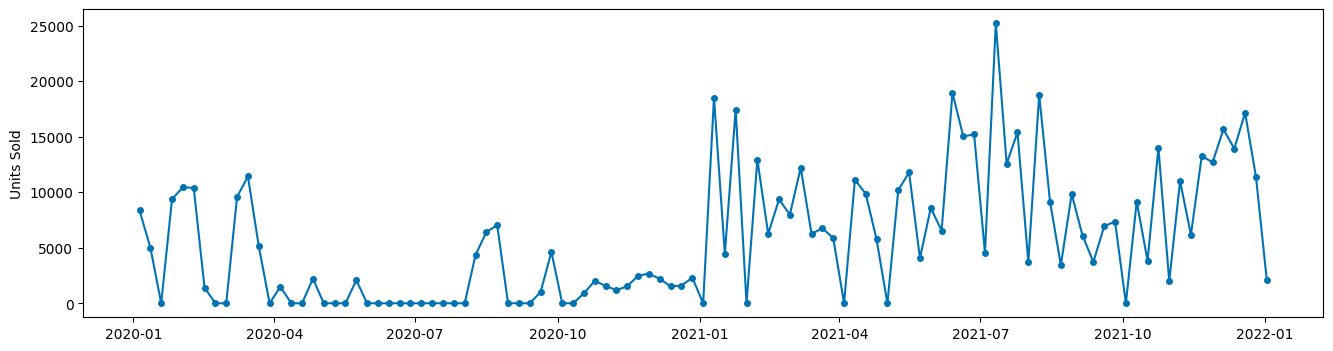

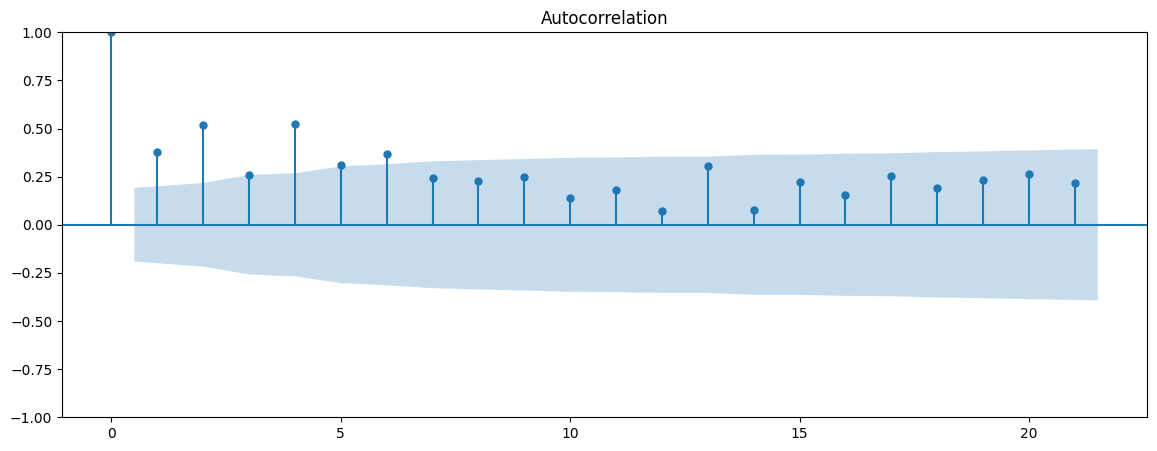

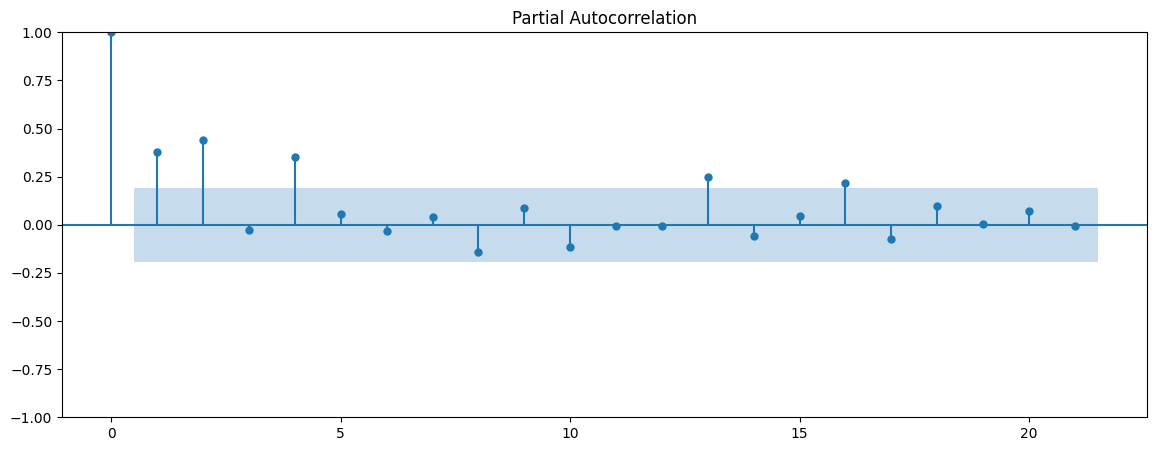

In [1834]:
# Plot Time Series Data
plot_series(footlocker_weekly['Units Sold']);

# plot ACF
plot_acf(footlocker_weekly['Units Sold']).set_size_inches((14,5));

# plot PACF
plot_pacf(footlocker_weekly['Units Sold']).set_size_inches((14,5));

[**Differenced Version of Units Sold**]

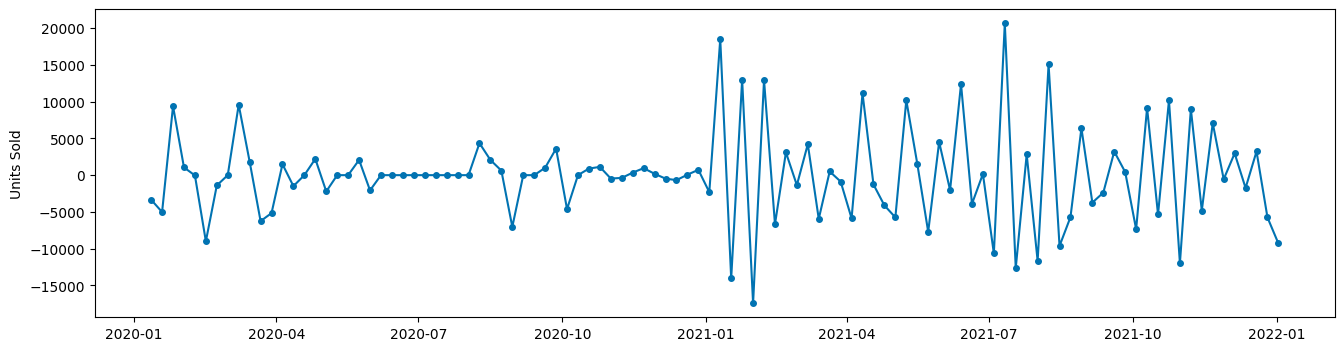

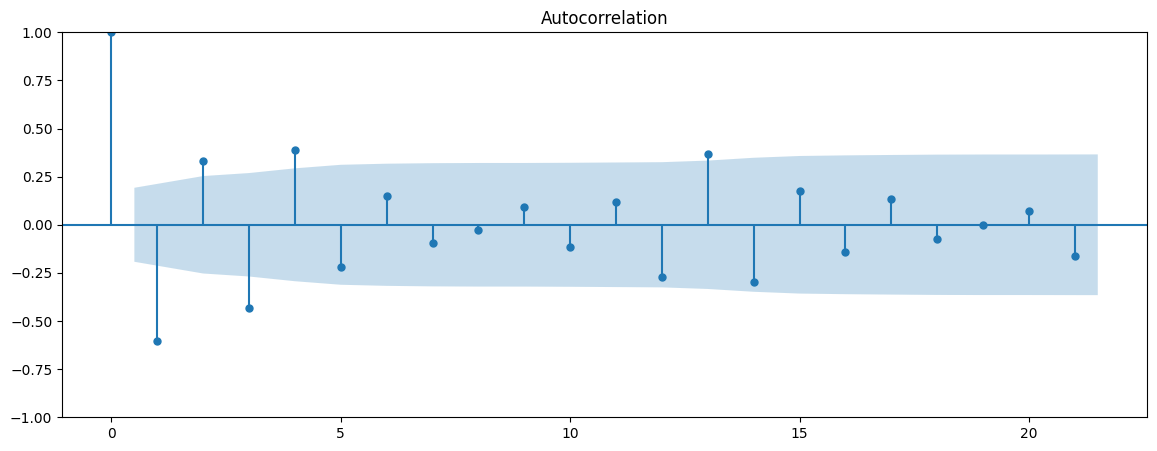

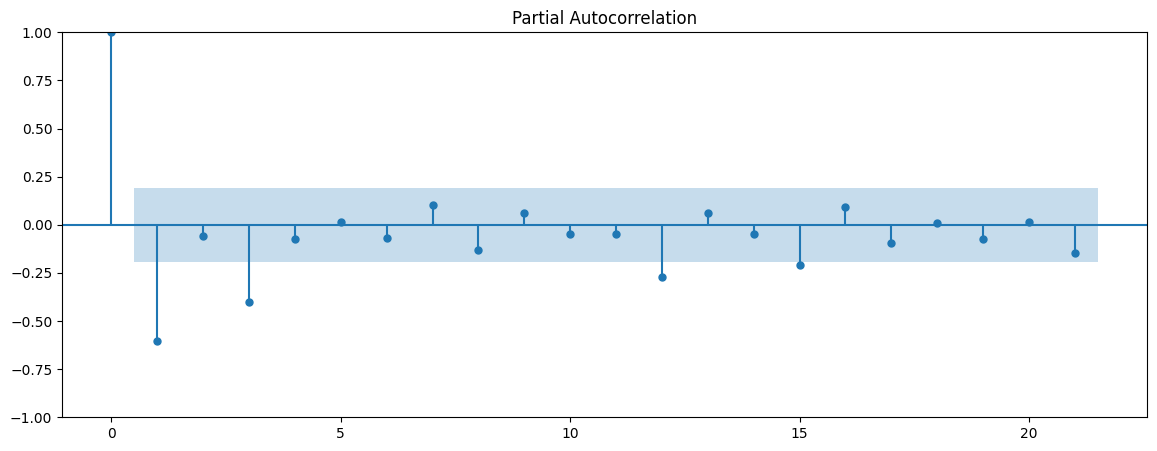

In [1835]:
# plot time series data
plot_series(footlocker_weekly['Units Sold'].diff());

# plot ACF
plot_acf(footlocker_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

# plot PACF
plot_pacf(footlocker_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

[**Log-transformed Version of Units Sold**]

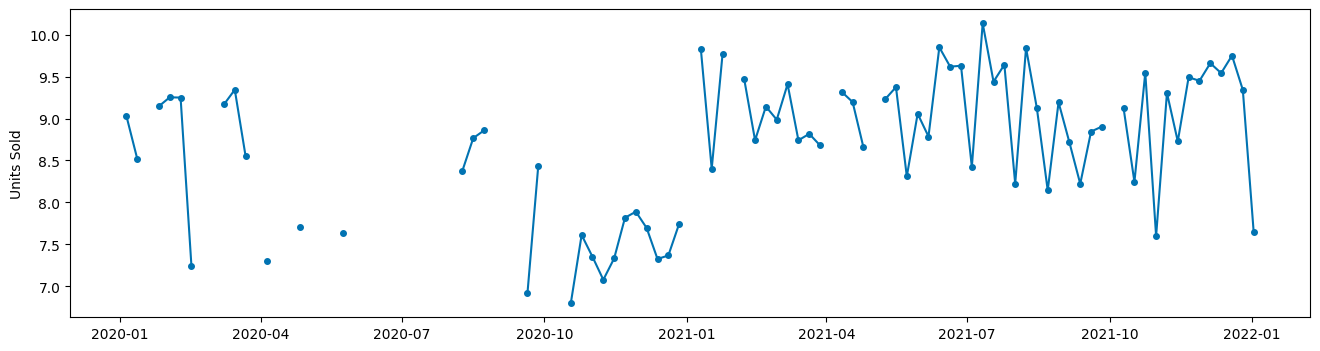

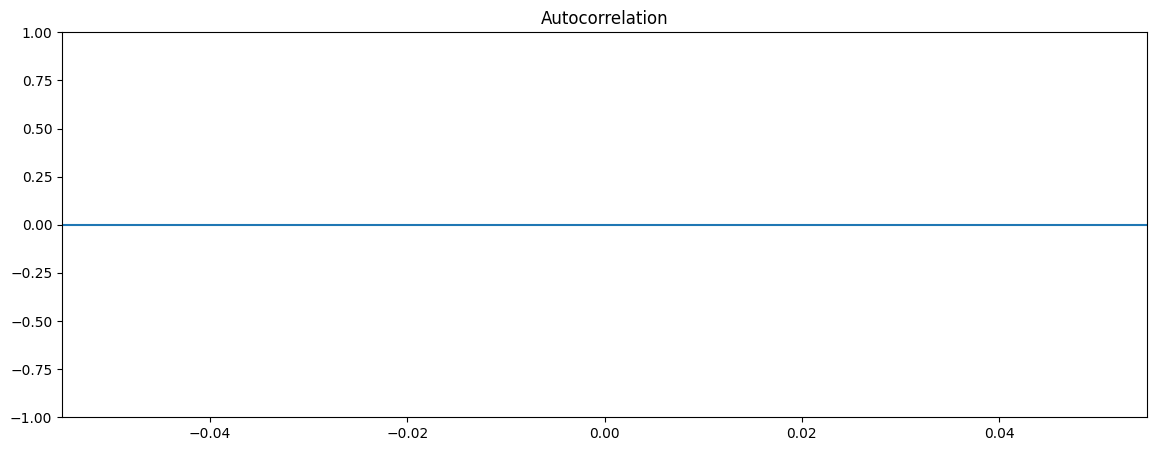

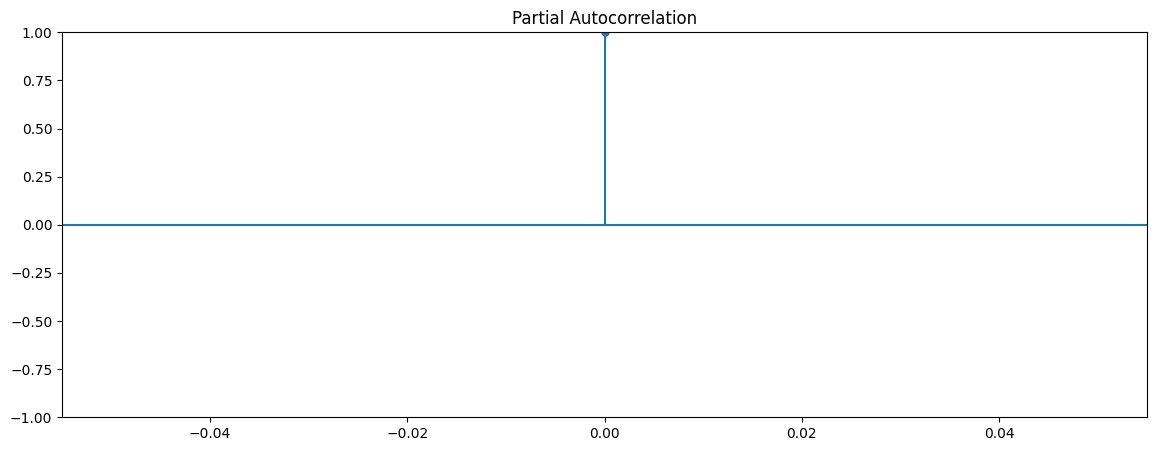

In [1836]:
# plot time series data
plot_series(np.log(footlocker_weekly['Units Sold']));

# plot ACF
plot_acf(np.log(footlocker_weekly['Units Sold'])).set_size_inches((14,5));

# plot PACF
plot_pacf(np.log(footlocker_weekly['Units Sold'])).set_size_inches((14,5));

### Modelling

ForecastingHorizon(['2021-10-10', '2021-10-17', '2021-10-24', '2021-10-31',
               '2021-11-07', '2021-11-14', '2021-11-21', '2021-11-28',
               '2021-12-05', '2021-12-12', '2021-12-19', '2021-12-26',
               '2022-01-02'],
              dtype='datetime64[ns]', freq='W-SUN', is_relative=False)

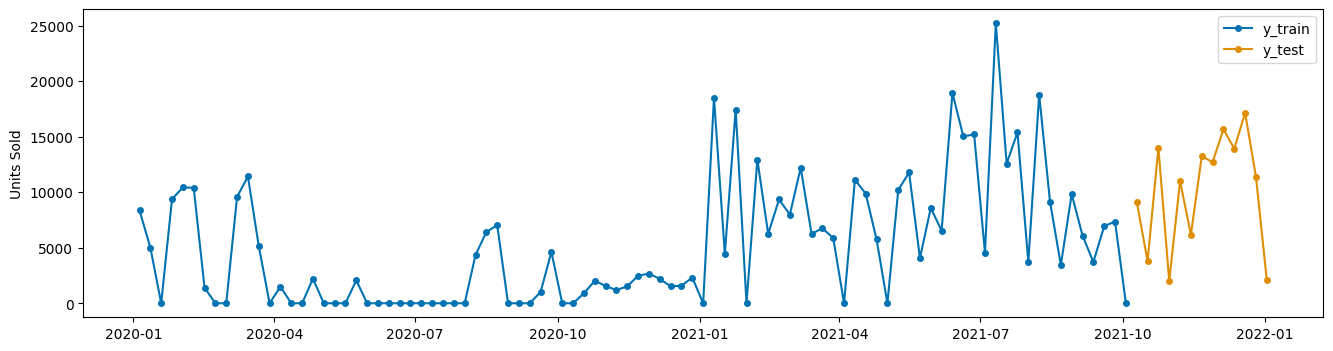

In [1837]:
# Do train-test split
y = footlocker_weekly['Units Sold']
y_train_fl, y_test_fl = temporal_train_test_split(y, test_size=13)

# check the time series after splitting
plot_series(y_train_fl, y_test_fl, labels=["y_train", "y_test"]);

#specific data points
fh_fl = ForecastingHorizon(y_test_fl.index, is_relative=False)
fh_fl

In [1838]:
from sktime.forecasting.arima import AutoARIMA
arima_forecaster = AutoARIMA(sp=13, suppress_warnings=True, random_state=1000)

In [1839]:
# fit forecaster to train data
arima_forecaster.fit(y_train_fl)

AutoARIMA(random_state=1000, sp=13, suppress_warnings=True)

In [1840]:
# do prediction based on forecast horizon we already defined
y_pred_arima_fl = arima_forecaster.predict(fh=fh_fl)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


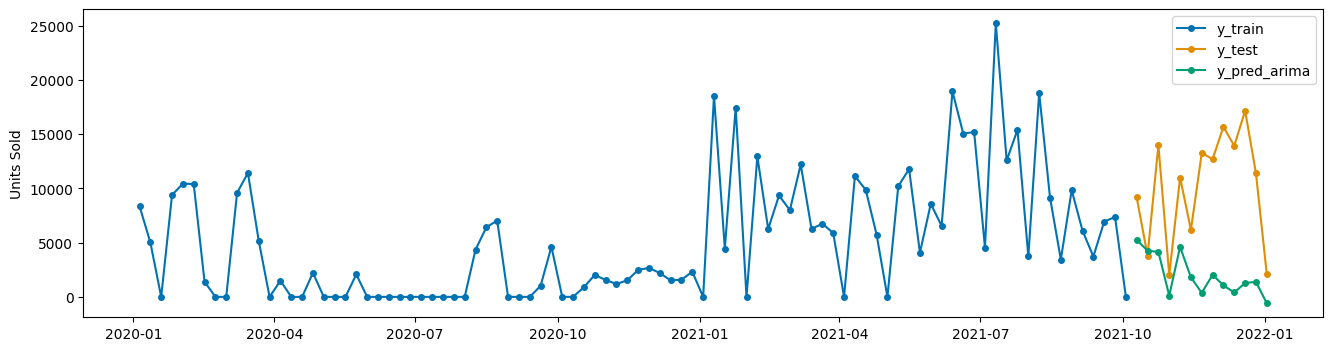

In [1841]:
# plot the forecast result
plot_series(y_train_fl, y_test_fl, y_pred_arima_fl, labels=["y_train", "y_test", "y_pred_arima"]);

**Check Model Specs**

In [1842]:
arima_forecaster.get_fitted_params()

{'ar.L1': -0.4947431656836469,
 'ma.L1': -0.2406298117904835,
 'ma.L2': -0.27723700701183357,
 'ma.L3': -0.1547874987751208,
 'ma.L4': 0.40892477937458616,
 'ar.S.L13': 0.2687586970843259,
 'sigma2': 19293670.123682383,
 'order': (1, 1, 4),
 'seasonal_order': (1, 0, 0, 13),
 'aic': 1796.6771702309354,
 'aicc': 1798.0265678212968,
 'bic': 1814.2531867765533,
 'hqic': 1803.7679982171153}

In [1843]:
arima_forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   92
Model:             SARIMAX(1, 1, 4)x(1, 0, [], 13)   Log Likelihood                -891.339
Date:                             Sat, 26 Apr 2025   AIC                           1796.677
Time:                                     21:49:21   BIC                           1814.253
Sample:                                 01-05-2020   HQIC                          1803.768
                                      - 10-03-2021                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4947      0.225     -2.200      0.028      -0.935      -0.054
ma.L1         -0.2406      0.264     -0.913      0.361      -0.757       0.276
ma.L2         -0.2772      0.177     -1.563      0.118      -0.625       0.070
ma.L3         -0.1548      0.109     -1.422      0.155      -0.368       0.059
ma.L4          0.4089      0.127      3.222      0.001       0.160       0.658
ar.S.L13       0.2688      0.125      2.151      0.031       0.024       0.514
sigma2      1.929e+07   1.32e-08   1.46e+15      0.000    1.93e+07    1.93e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                26.40
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               2.03   Skew:                             0.81
Prob(H) (two-sided):                  0.06   Kurtosis:                         5.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.39e+31. Standard errors may be unstable.
"""

### Model Diagnostic

In [1844]:
# find residuals
residuals_fl = y_test_fl - y_pred_arima_fl

**Plot Residuals**

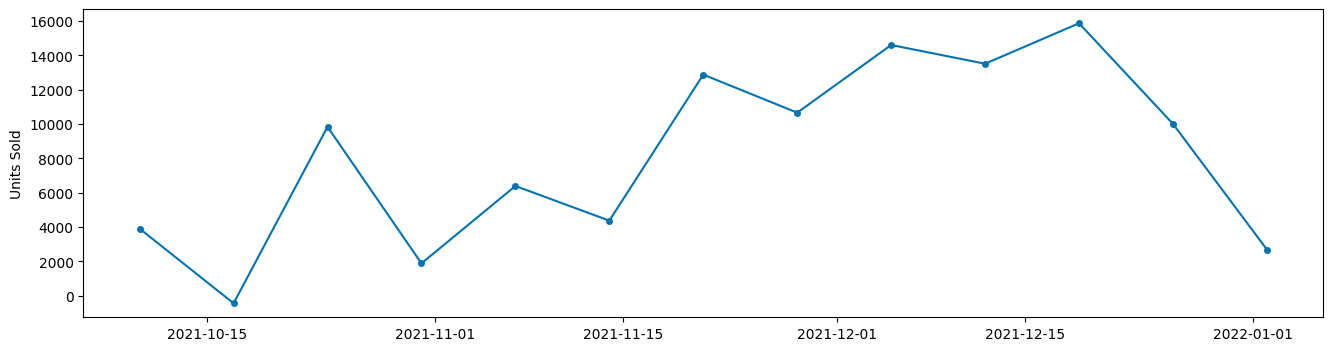

In [1845]:
plot_series(residuals_fl);

**Normality of Residuals**

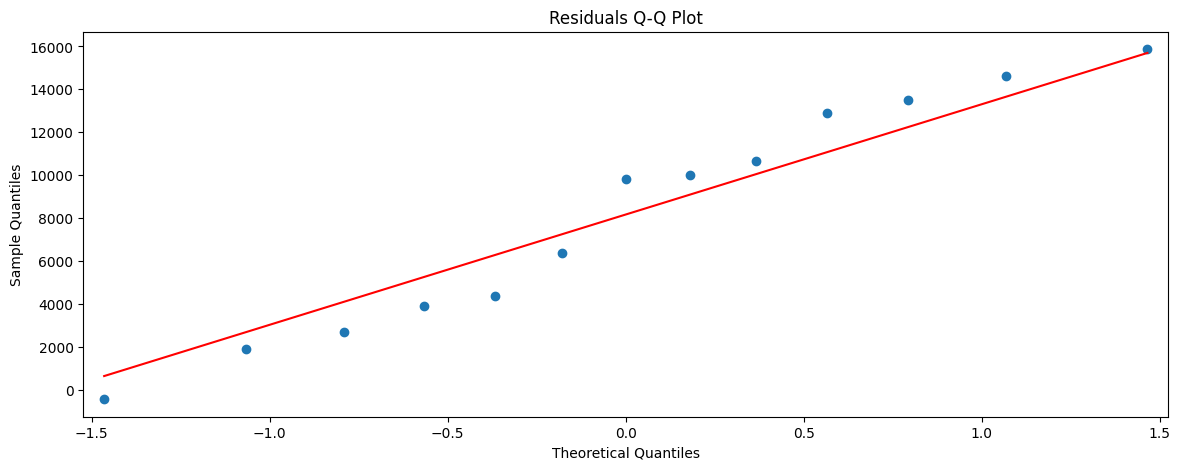

In [1846]:
sm.qqplot(residuals_fl, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

In [1847]:
mean_absolute_percentage_error(y_test_fl, y_pred_arima_fl) * 100

79.06926054095943

### **ARIMA for Amazon**

**Units Sold**

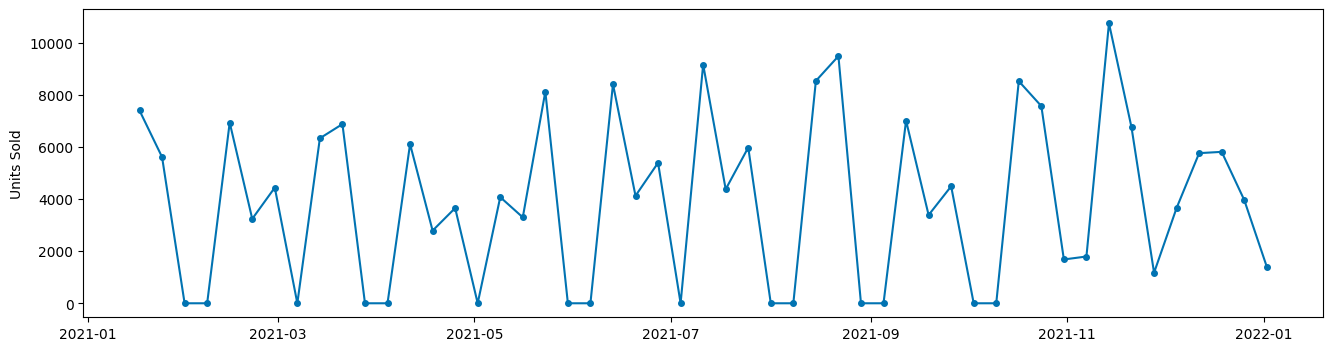

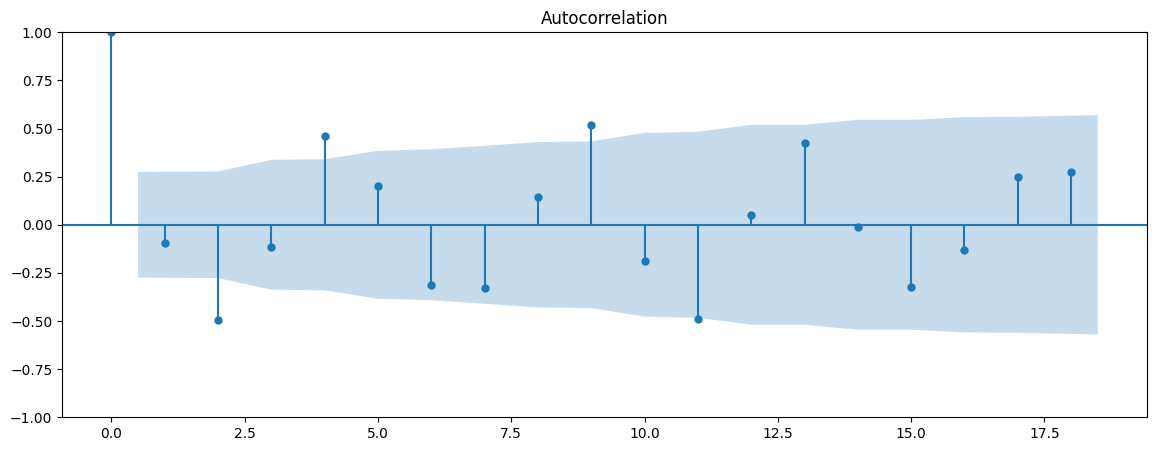

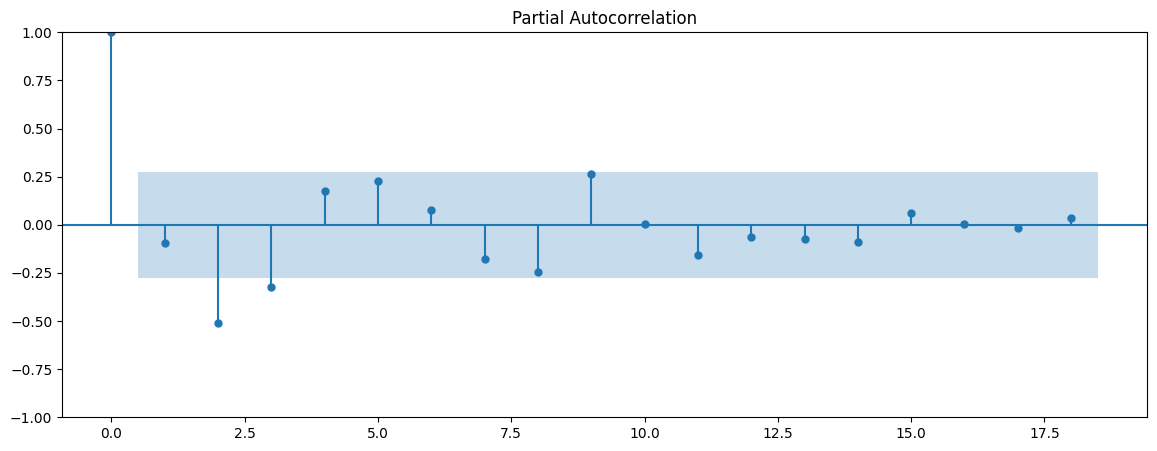

In [1848]:
# Plot Time Series Data
plot_series(amazon_weekly['Units Sold']);

# plot ACF
plot_acf(amazon_weekly['Units Sold']).set_size_inches((14,5));

# plot PACF
plot_pacf(amazon_weekly['Units Sold']).set_size_inches((14,5));

[**Differenced Version of Units Sold**]

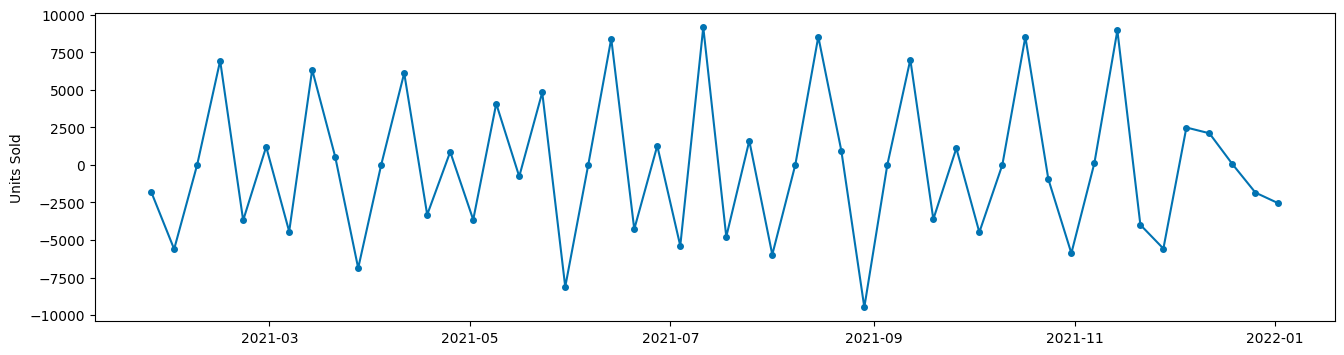

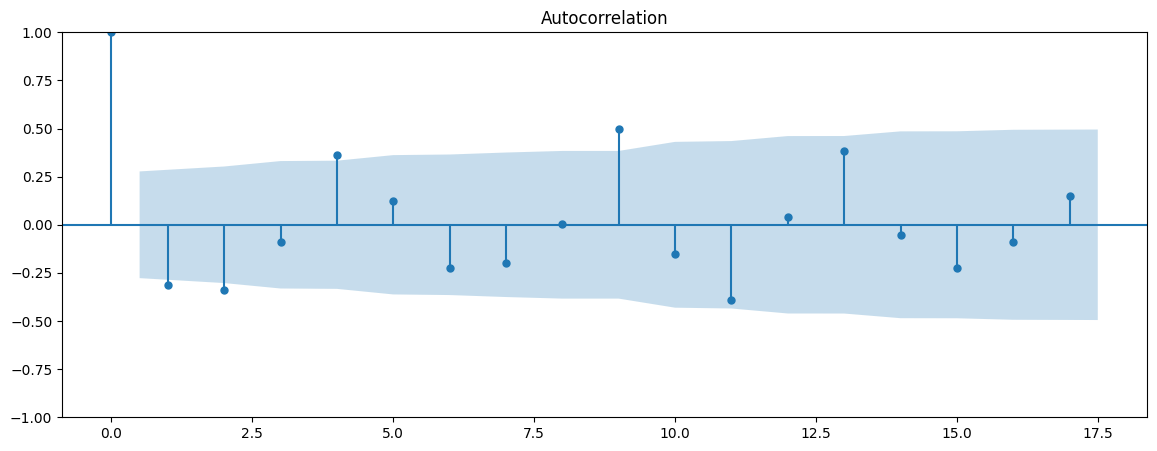

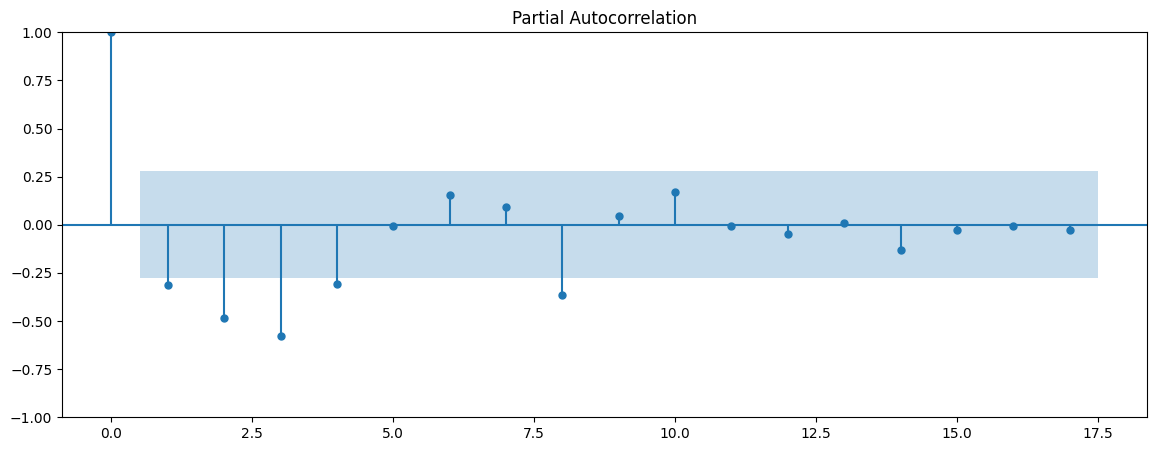

In [1849]:
# plot time series data
plot_series(amazon_weekly['Units Sold'].diff());

# plot ACF
plot_acf(amazon_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

# plot PACF
plot_pacf(amazon_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

[**Log-transformed Version of Units Sold**]

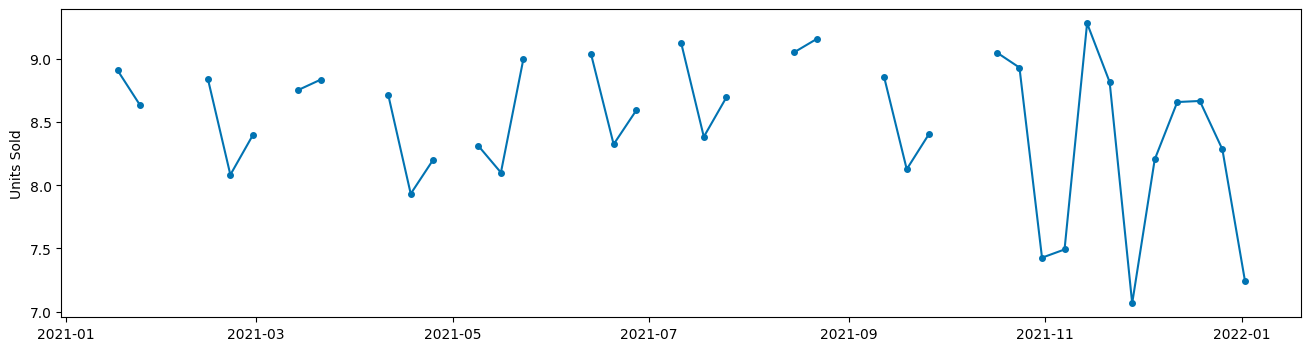

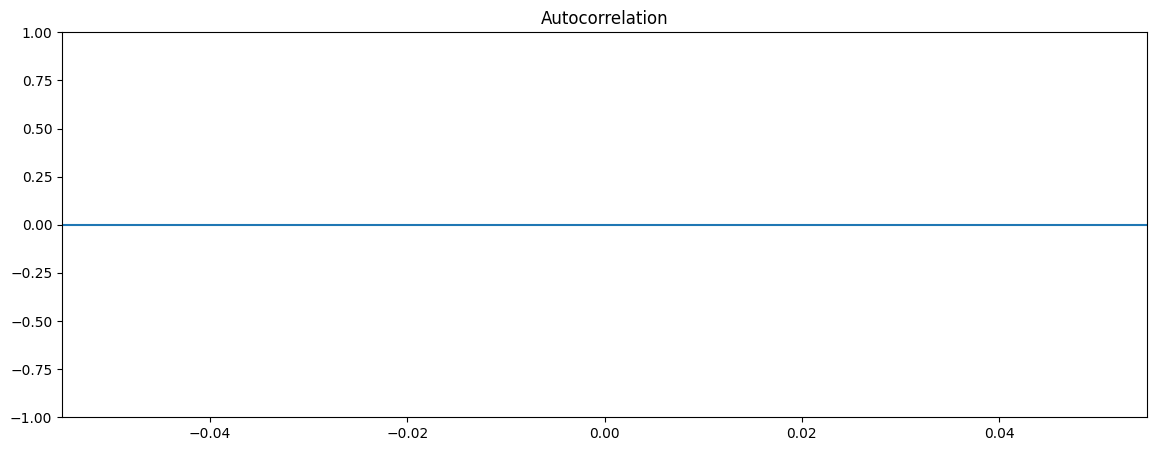

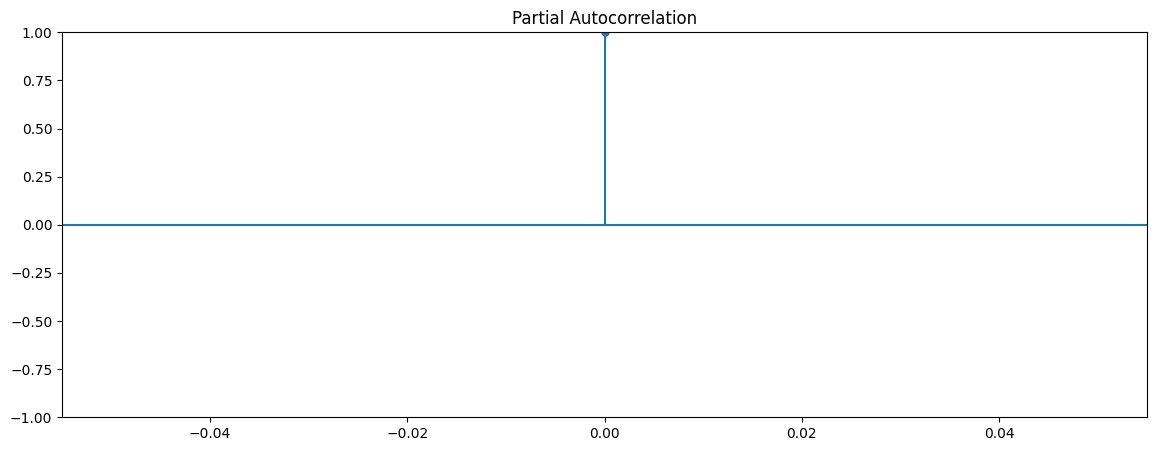

In [1850]:
# plot time series data
plot_series(np.log(amazon_weekly['Units Sold']));

# plot ACF
plot_acf(np.log(amazon_weekly['Units Sold'])).set_size_inches((14,5));

# plot PACF
plot_pacf(np.log(amazon_weekly['Units Sold'])).set_size_inches((14,5));

### Modelling

ForecastingHorizon(['2021-10-10', '2021-10-17', '2021-10-24', '2021-10-31',
               '2021-11-07', '2021-11-14', '2021-11-21', '2021-11-28',
               '2021-12-05', '2021-12-12', '2021-12-19', '2021-12-26',
               '2022-01-02'],
              dtype='datetime64[ns]', freq='W-SUN', is_relative=False)

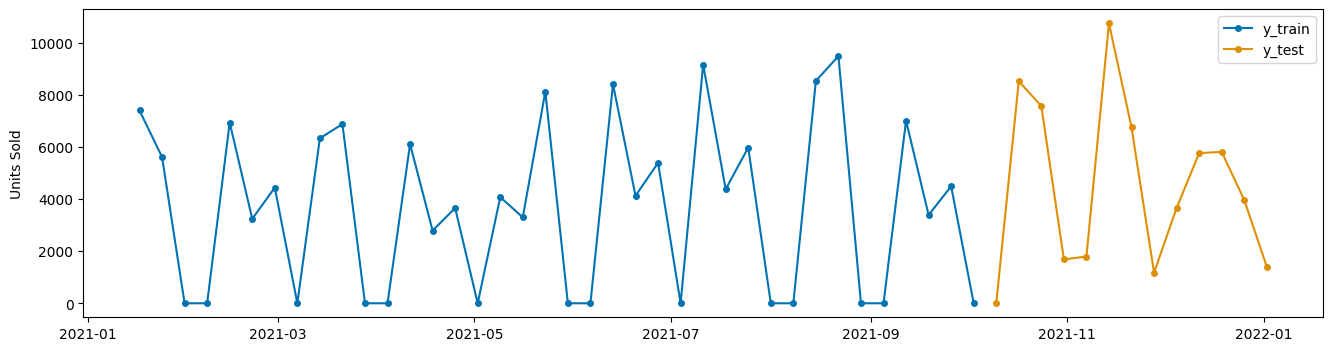

In [1851]:
# Do train-test split
y = amazon_weekly['Units Sold']
y_train_amazon, y_test_amazon = temporal_train_test_split(y, test_size=13)

# check the time series after splitting
plot_series(y_train_amazon, y_test_amazon, labels=["y_train", "y_test"]);

#specific data points
fh_amazon = ForecastingHorizon(y_test_amazon.index, is_relative=False)
fh_amazon

In [1852]:
from sktime.forecasting.arima import AutoARIMA
arima_forecaster = AutoARIMA(sp=13, suppress_warnings=True, random_state=1000)

In [1853]:
# fit forecaster to train data
arima_forecaster.fit(y_train_amazon)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

AutoARIMA(random_state=1000, sp=13, suppress_warnings=True)

In [1854]:
# do prediction based on forecast horizon we already defined
y_pred_arima_amazon = arima_forecaster.predict(fh=fh_amazon)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


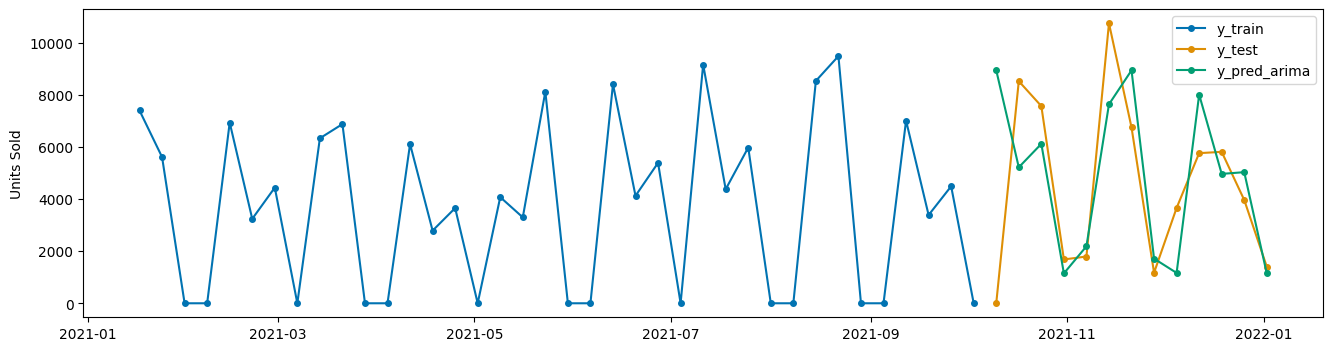

In [1855]:
# plot the forecast result
plot_series(y_train_amazon, y_test_amazon, y_pred_arima_amazon, labels=["y_train", "y_test", "y_pred_arima"]);

**Check Model Specs**

In [1856]:
arima_forecaster.get_fitted_params()

{'intercept': 657.5078008763535,
 'ma.L1': -0.46951285863090136,
 'ma.S.L13': -0.4450012191527274,
 'sigma2': 5168753.677559908,
 'order': (0, 0, 1),
 'seasonal_order': (0, 1, 1, 13),
 'aic': 466.2590074596354,
 'aicc': 468.2590074596354,
 'bic': 471.13451075910825,
 'hqic': 467.61126486673186}

In [1857]:
arima_forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   38
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 13)   Log Likelihood                -229.130
Date:                            Sat, 26 Apr 2025   AIC                            466.259
Time:                                    21:49:26   BIC                            471.135
Sample:                                01-17-2021   HQIC                           467.611
                                     - 10-03-2021                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    657.5078    312.815      2.102      0.036      44.402    1270.613
ma.L1         -0.4695      0.219     -2.144      0.032      -0.899      -0.040
ma.S.L13      -0.4450      0.370     -1.203      0.229      -1.170       0.280
sigma2      5.169e+06   2.54e+06      2.037      0.042    1.96e+05    1.01e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 2.07
Prob(Q):                              0.76   Prob(JB):                         0.35
Heteroskedasticity (H):               0.80   Skew:                             0.47
Prob(H) (two-sided):                  0.75   Kurtosis:                         1.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Model Diagnostic

In [1858]:
# find residuals
residuals_amazon = y_test_amazon - y_pred_arima_amazon

**Plot Residuals**

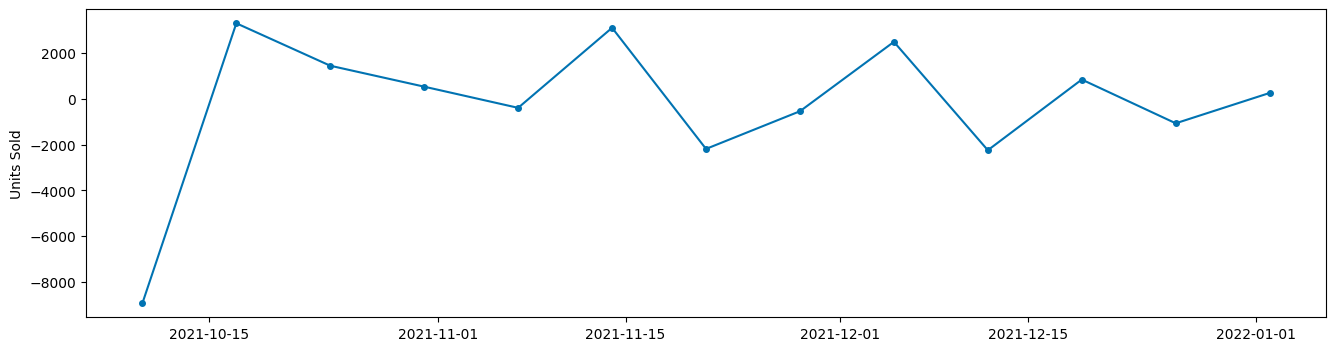

In [1859]:
plot_series(residuals_amazon);

**Normality of Residuals**

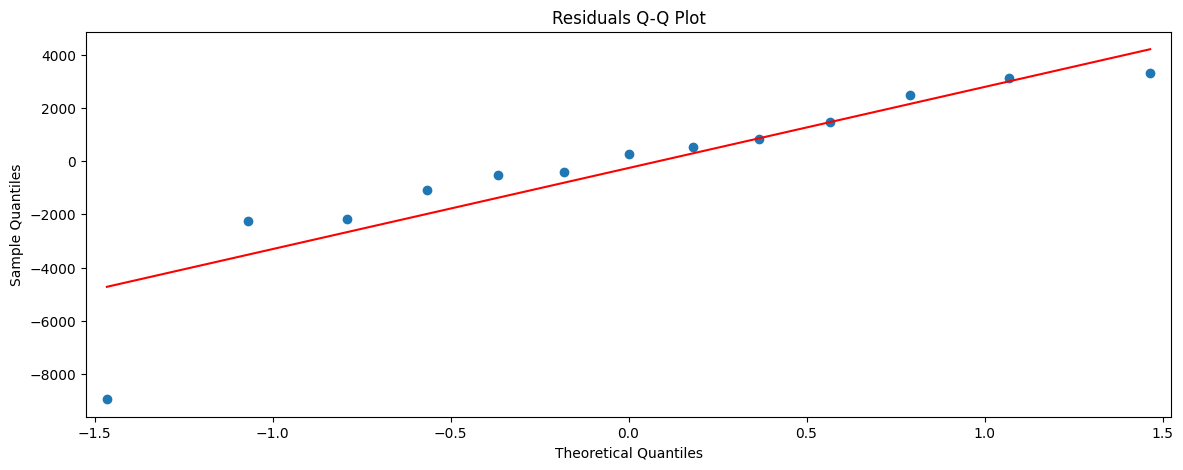

In [1860]:
sm.qqplot(residuals_amazon, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

In [1861]:
mean_absolute_percentage_error(y_test_amazon, y_pred_arima_amazon) * 100

3.096094876676276e+20

### **ARIMA for Kohl's**

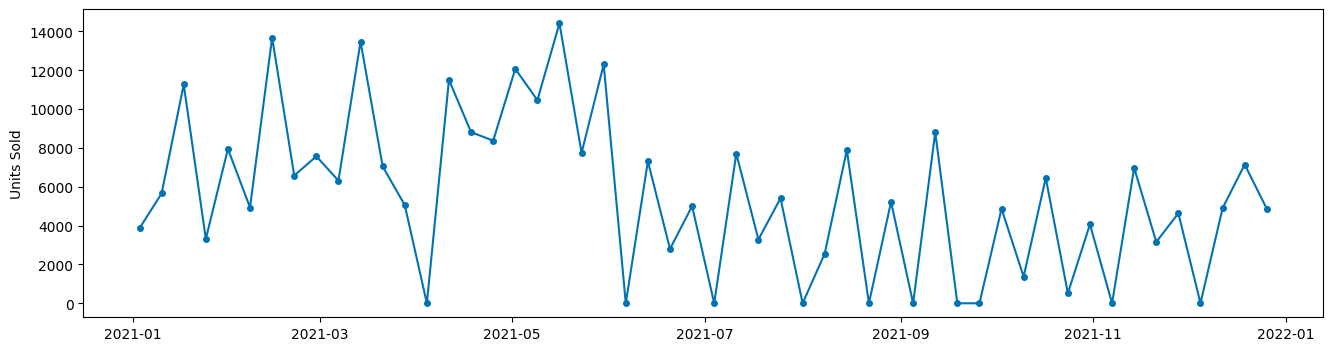

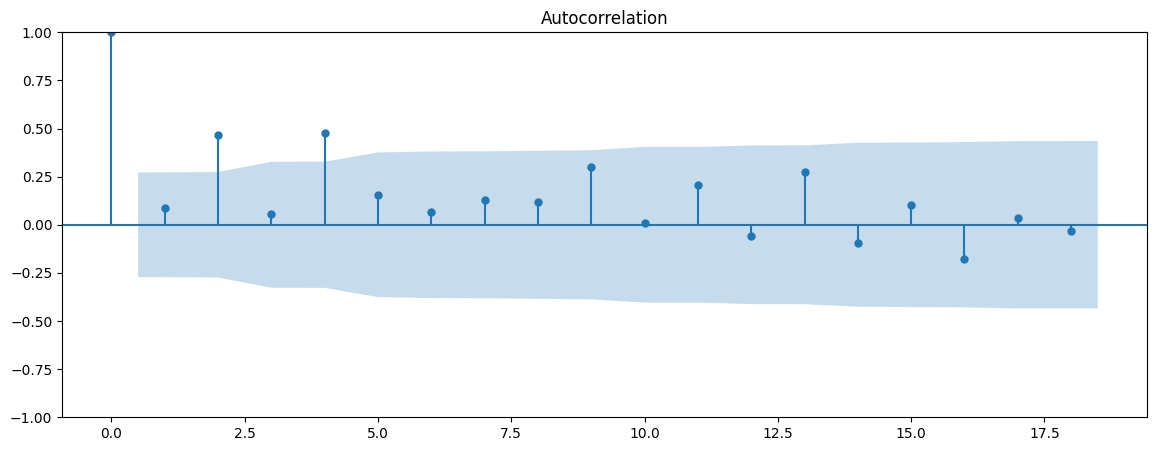

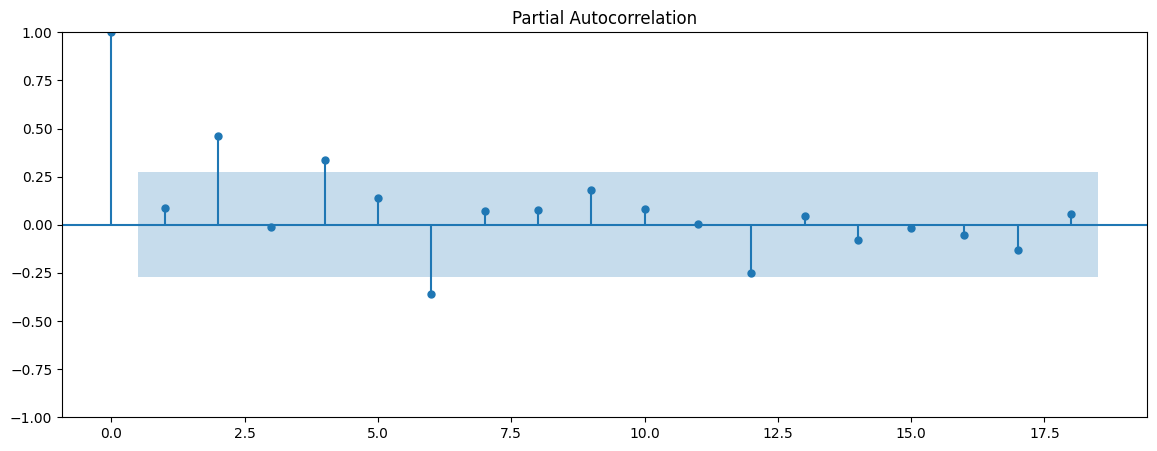

In [1862]:
# Plot Time Series Data
plot_series(kohls_weekly['Units Sold']);

# plot ACF
plot_acf(kohls_weekly['Units Sold']).set_size_inches((14,5));

# plot PACF
plot_pacf(kohls_weekly['Units Sold']).set_size_inches((14,5));

[**Differenced Version of Units Sold**]

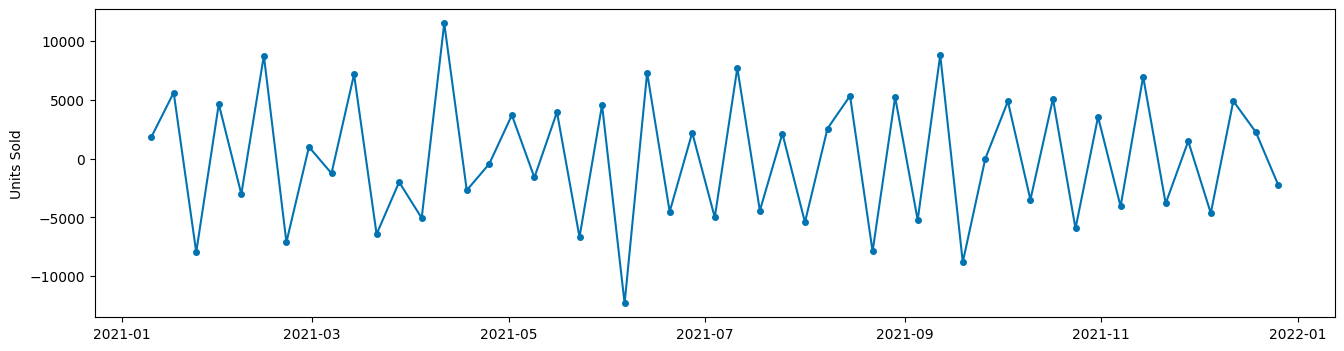

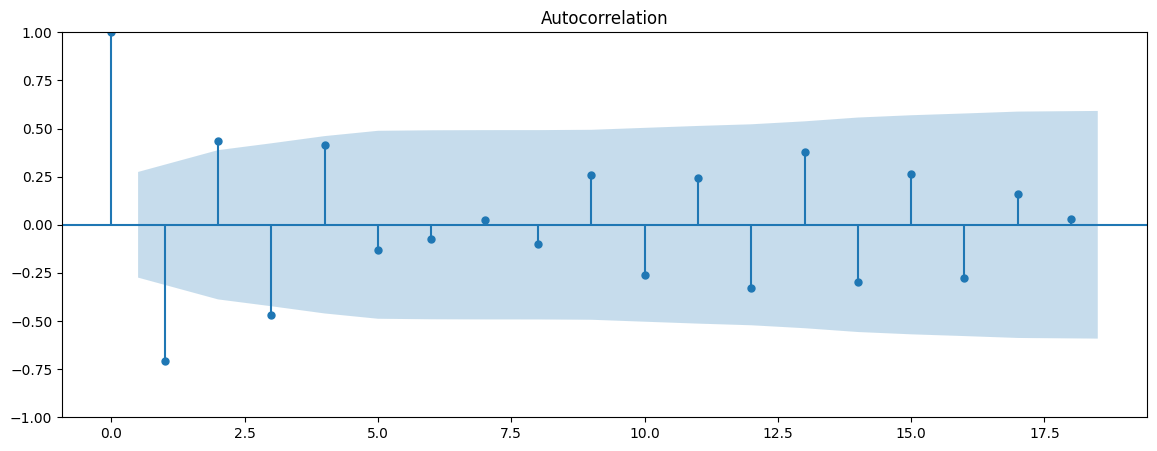

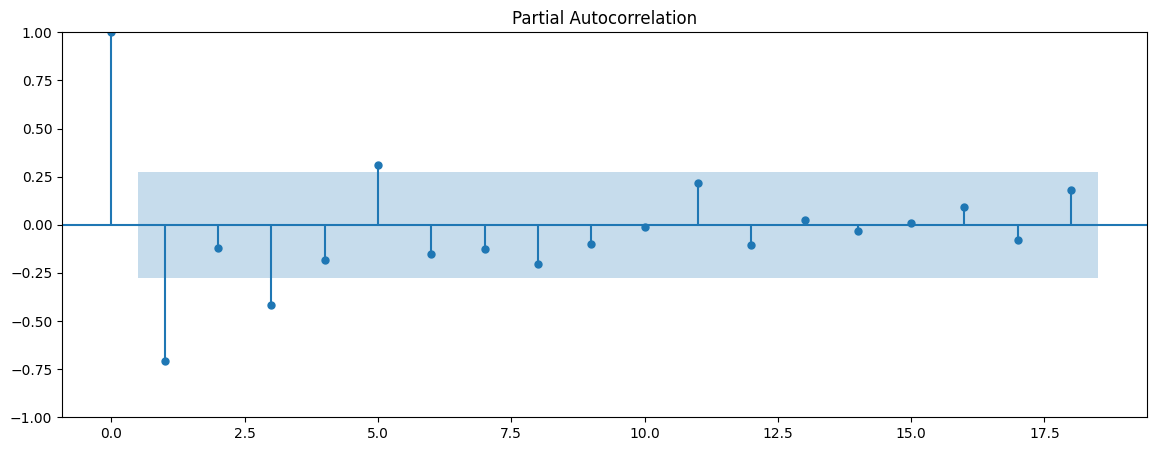

In [1863]:
# plot time series data
plot_series(kohls_weekly['Units Sold'].diff());

# plot ACF
plot_acf(kohls_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

# plot PACF
plot_pacf(kohls_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

[**Log-transformed Version of Units Sold**]

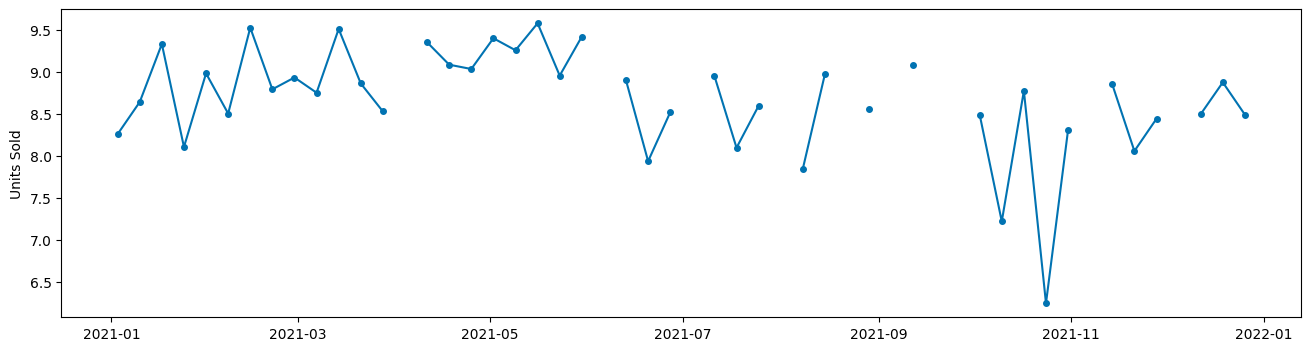

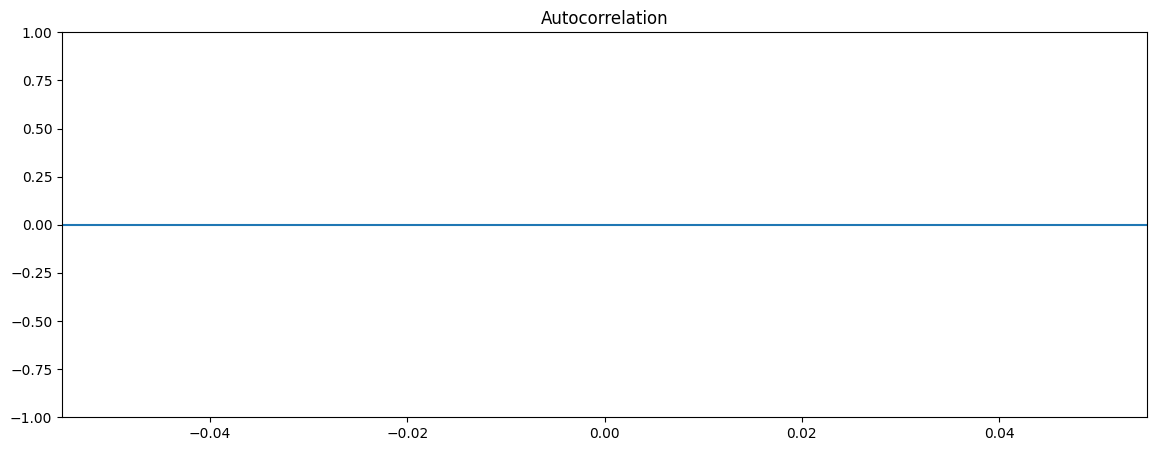

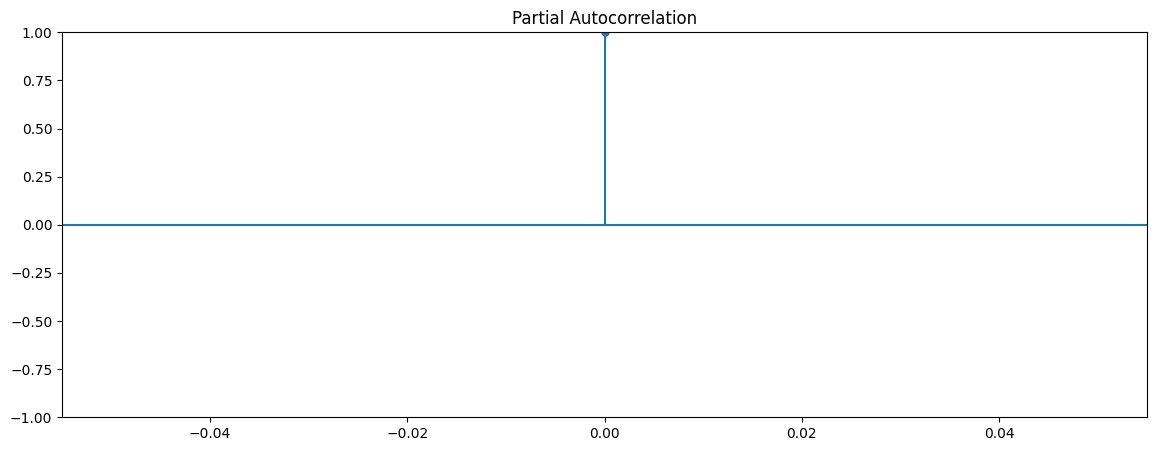

In [1864]:
# plot time series data
plot_series(np.log(kohls_weekly['Units Sold']));

# plot ACF
plot_acf(np.log(kohls_weekly['Units Sold'])).set_size_inches((14,5));

# plot PACF
plot_pacf(np.log(kohls_weekly['Units Sold'])).set_size_inches((14,5));

### Modelling

ForecastingHorizon(['2021-10-03', '2021-10-10', '2021-10-17', '2021-10-24',
               '2021-10-31', '2021-11-07', '2021-11-14', '2021-11-21',
               '2021-11-28', '2021-12-05', '2021-12-12', '2021-12-19',
               '2021-12-26'],
              dtype='datetime64[ns]', freq='W-SUN', is_relative=False)

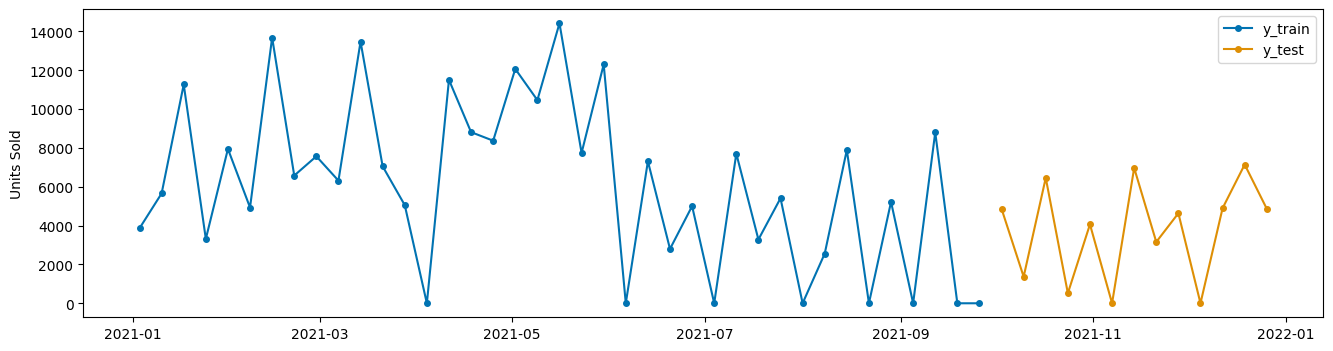

In [1865]:
# Do train-test split
y = kohls_weekly['Units Sold']
y_train_kohls, y_test_kohls = temporal_train_test_split(y, test_size=13)

# check the time series after splitting
plot_series(y_train_kohls, y_test_kohls, labels=["y_train", "y_test"]);

#specific data points
fh_kohls = ForecastingHorizon(y_test_kohls.index, is_relative=False)
fh_kohls

In [1866]:
from sktime.forecasting.arima import AutoARIMA
arima_forecaster = AutoARIMA(sp=13, suppress_warnings=True, random_state=1000)

In [1867]:
# fit forecaster to train data
arima_forecaster.fit(y_train_kohls)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

AutoARIMA(random_state=1000, sp=13, suppress_warnings=True)

In [1868]:
# do prediction based on forecast horizon we already defined
y_pred_arima_kohls = arima_forecaster.predict(fh=fh_kohls)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


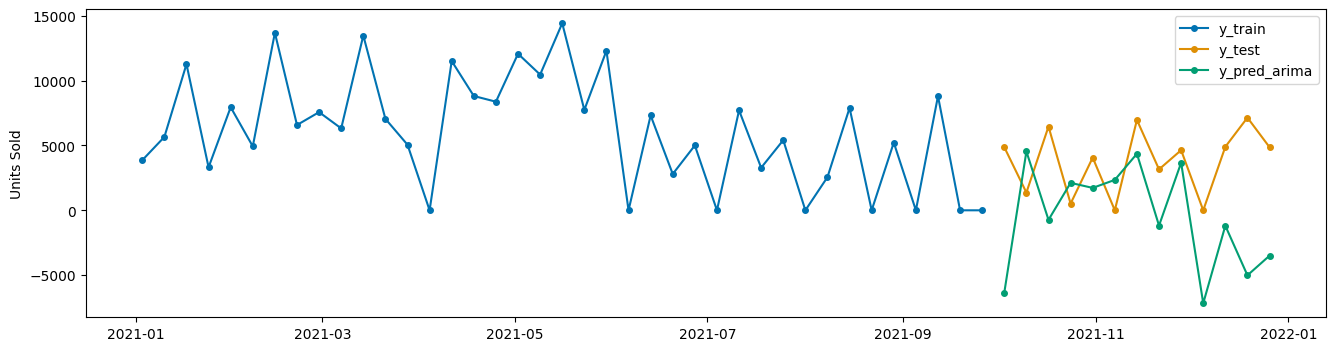

In [1869]:
# plot the forecast result
plot_series(y_train_kohls, y_test_kohls, y_pred_arima_kohls, labels=["y_train", "y_test", "y_pred_arima"]);

**Check Model Specs**

In [1870]:
arima_forecaster.get_fitted_params()

{'ar.L1': -0.8214798737947232,
 'ar.S.L13': -0.08431696414193296,
 'ar.S.L26': 0.8412447495140711,
 'ma.S.L13': 0.5086448733807883,
 'sigma2': 5599671.623213451,
 'order': (1, 1, 0),
 'seasonal_order': (2, 0, 1, 13),
 'aic': 738.9640390109804,
 'aicc': 740.8390390109804,
 'bic': 747.1519698096123,
 'hqic': 741.8772421983784}

In [1871]:
arima_forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                   39
Model:             SARIMAX(1, 1, 0)x(2, 0, [1], 13)   Log Likelihood                -364.482
Date:                              Sat, 26 Apr 2025   AIC                            738.964
Time:                                      21:49:36   BIC                            747.152
Sample:                                  01-03-2021   HQIC                           741.877
                                       - 09-26-2021                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8215      0.114     -7.211      0.000      -1.045      -0.598
ar.S.L13      -0.0843      0.219     -0.385      0.701      -0.514       0.345
ar.S.L26       0.8412      0.061     13.896      0.000       0.723       0.960
ma.S.L13       0.5086      0.744      0.684      0.494      -0.950       1.967
sigma2        5.6e+06   1.99e-07   2.81e+13      0.000     5.6e+06     5.6e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.02
Prob(Q):                              0.85   Prob(JB):                         0.60
Heteroskedasticity (H):               0.66   Skew:                            -0.08
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.96e+28. Standard errors may be unstable.
"""

### Model Diagnostic

In [1872]:
# find residuals
residuals_kohls = y_test_kohls - y_pred_arima_kohls

**Plot Residuals**

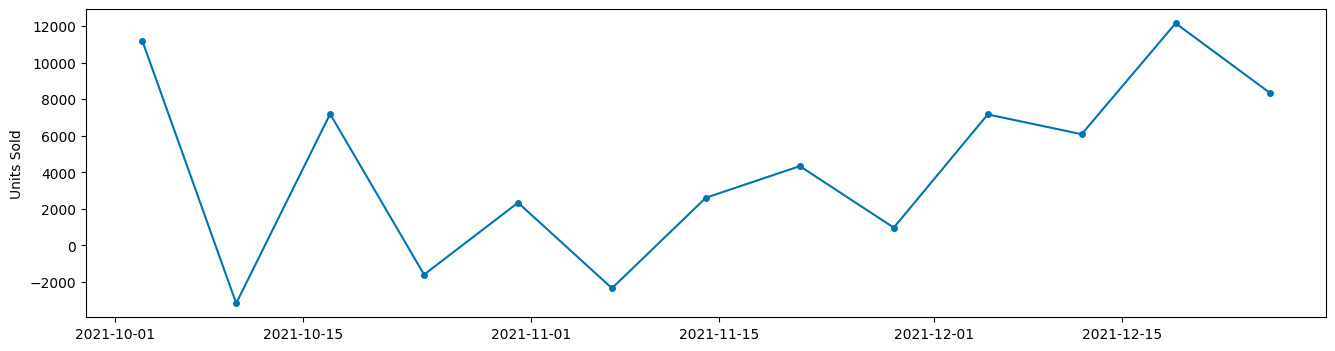

In [1873]:
plot_series(residuals_kohls);

**Normality of Residuals**

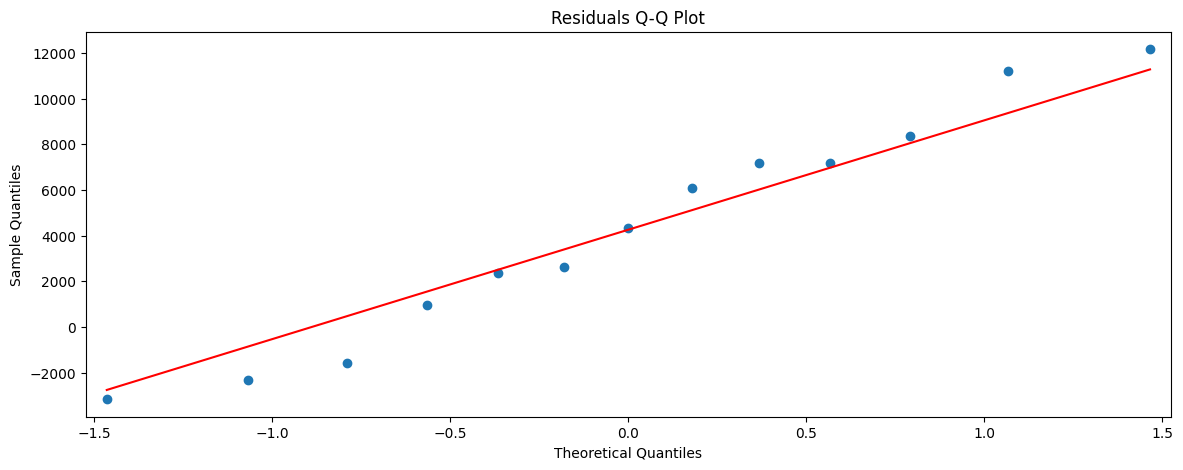

In [1874]:
sm.qqplot(residuals_kohls, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

In [1875]:
mean_absolute_percentage_error(y_test_kohls, y_pred_arima_kohls) * 100

3.296390937992512e+20

### **ARIMA for Sports Direct**

In [1876]:
sportsdirect_weekly_cut = sportsdirect_weekly[sportsdirect_weekly.index.year >= 2021]

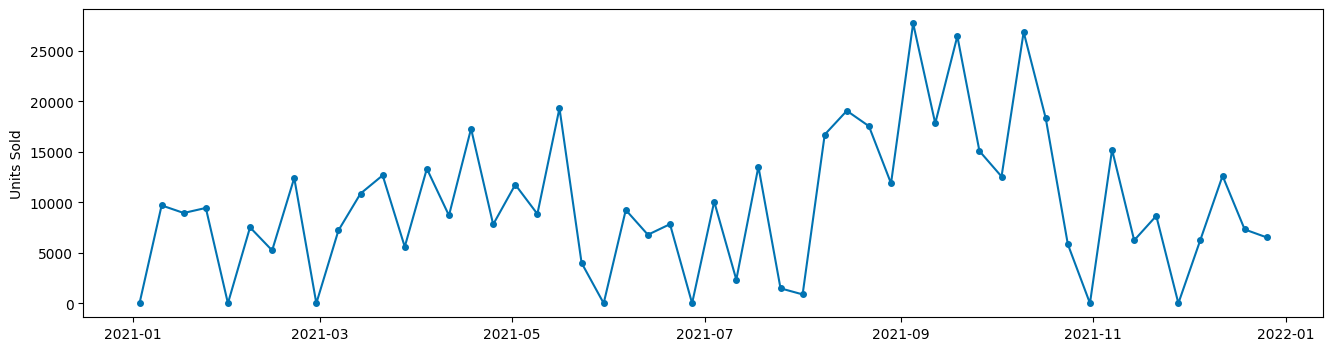

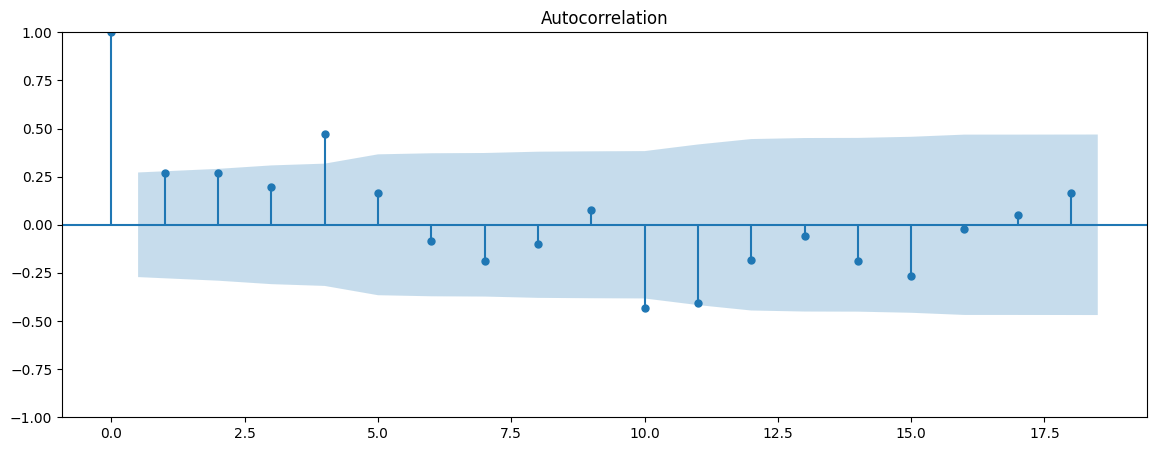

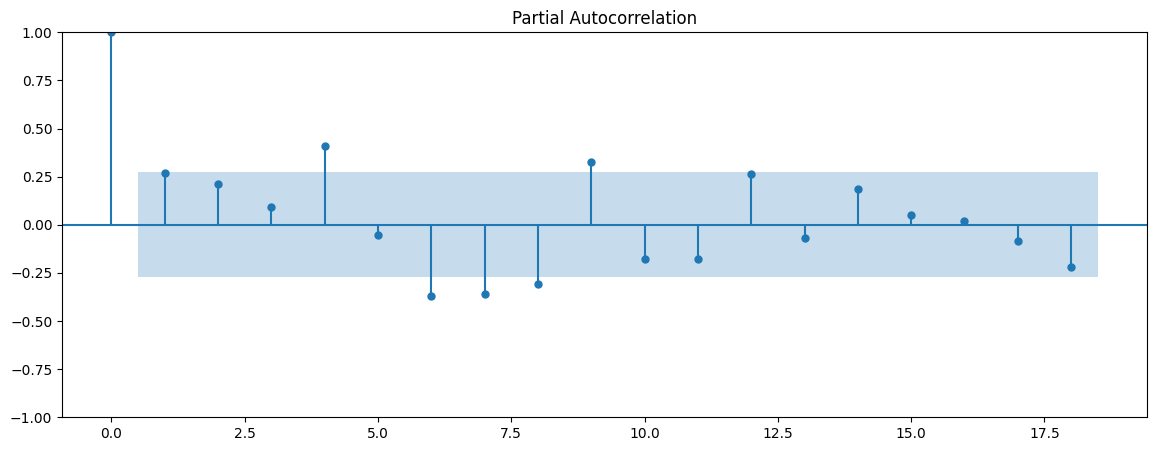

In [1877]:
# Plot Time Series Data
plot_series(sportsdirect_weekly_cut['Units Sold']);

# plot ACF
plot_acf(sportsdirect_weekly_cut['Units Sold']).set_size_inches((14,5));

# plot PACF
plot_pacf(sportsdirect_weekly_cut['Units Sold']).set_size_inches((14,5));

[**Differenced Version of Units Sold**]

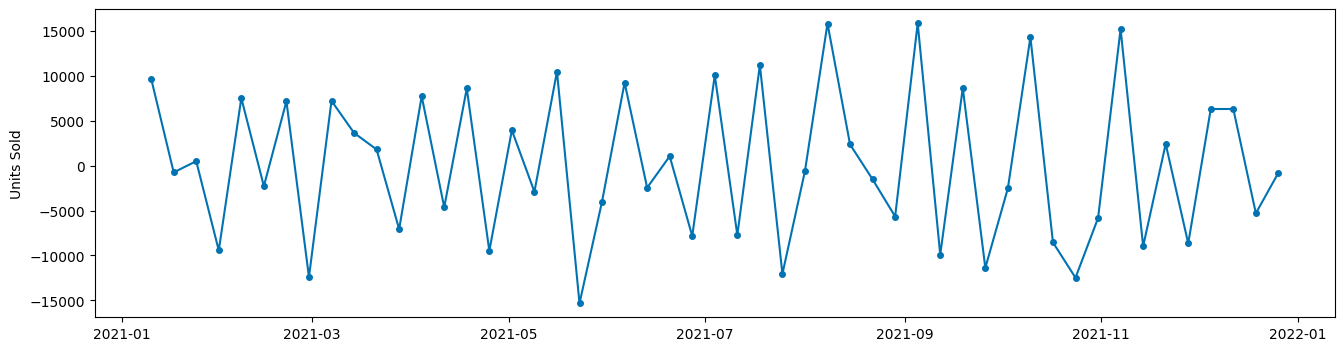

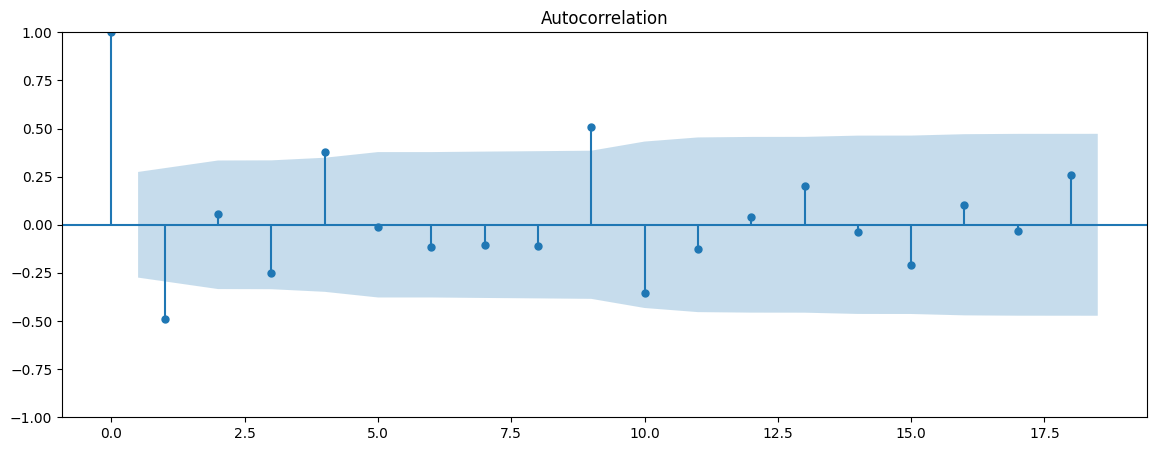

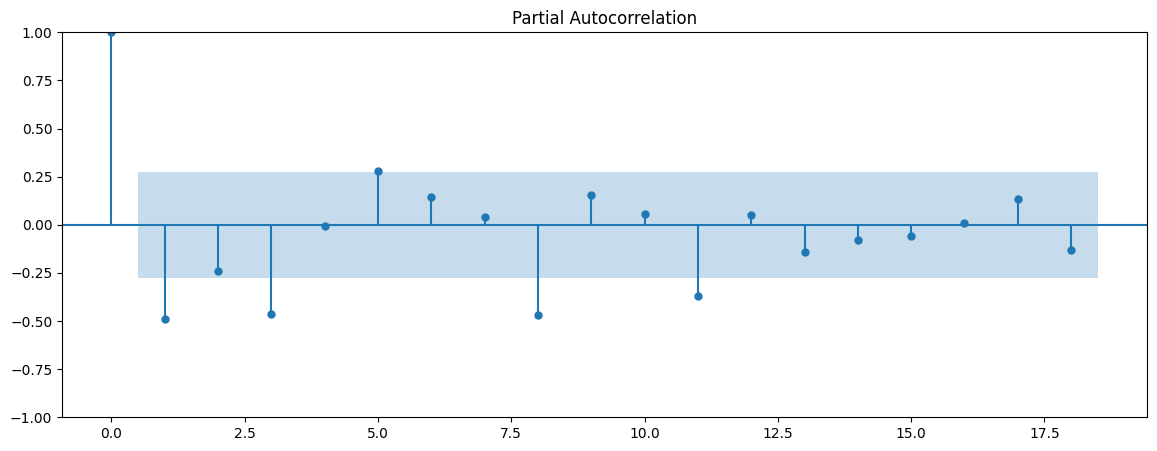

In [1878]:
# plot time series data
plot_series(sportsdirect_weekly_cut['Units Sold'].diff());

# plot ACF
plot_acf(sportsdirect_weekly_cut['Units Sold'].diff().dropna()).set_size_inches((14,5));

# plot PACF
plot_pacf(sportsdirect_weekly_cut['Units Sold'].diff().dropna()).set_size_inches((14,5));

[**Log-transformed Version of Units Sold**]

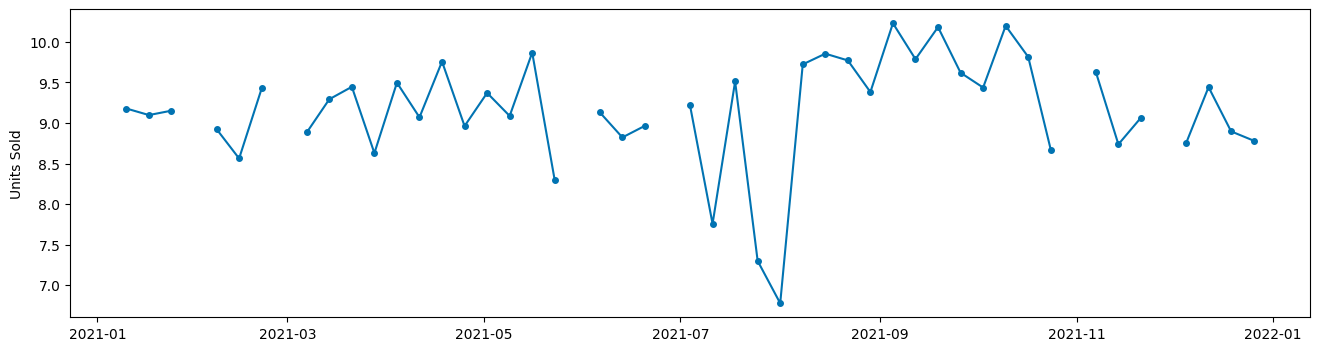

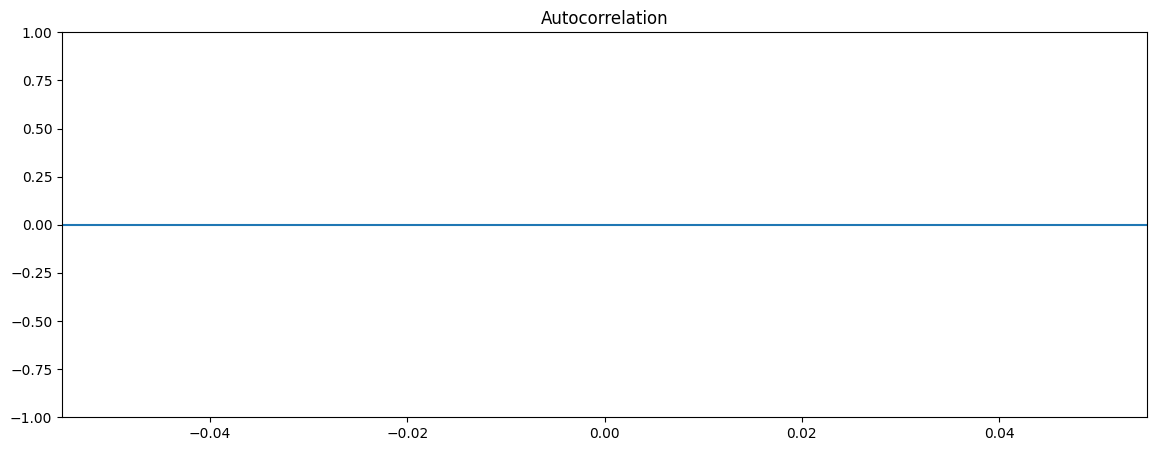

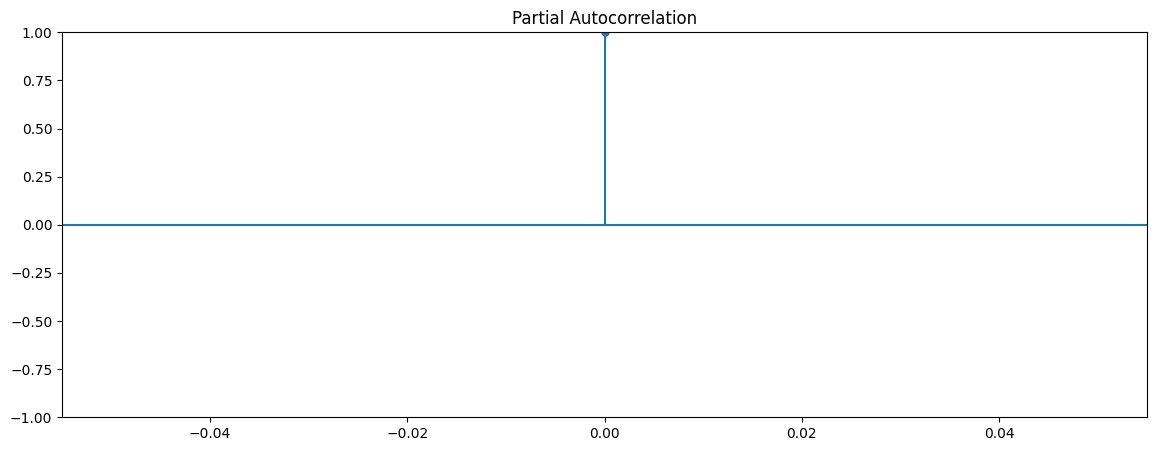

In [1879]:
# plot time series data
plot_series(np.log(sportsdirect_weekly_cut['Units Sold']));

# plot ACF
plot_acf(np.log(sportsdirect_weekly_cut['Units Sold'])).set_size_inches((14,5));

# plot PACF
plot_pacf(np.log(sportsdirect_weekly_cut['Units Sold'])).set_size_inches((14,5));

### Modelling

ForecastingHorizon(['2021-10-03', '2021-10-10', '2021-10-17', '2021-10-24',
               '2021-10-31', '2021-11-07', '2021-11-14', '2021-11-21',
               '2021-11-28', '2021-12-05', '2021-12-12', '2021-12-19',
               '2021-12-26'],
              dtype='datetime64[ns]', freq='W-SUN', is_relative=False)

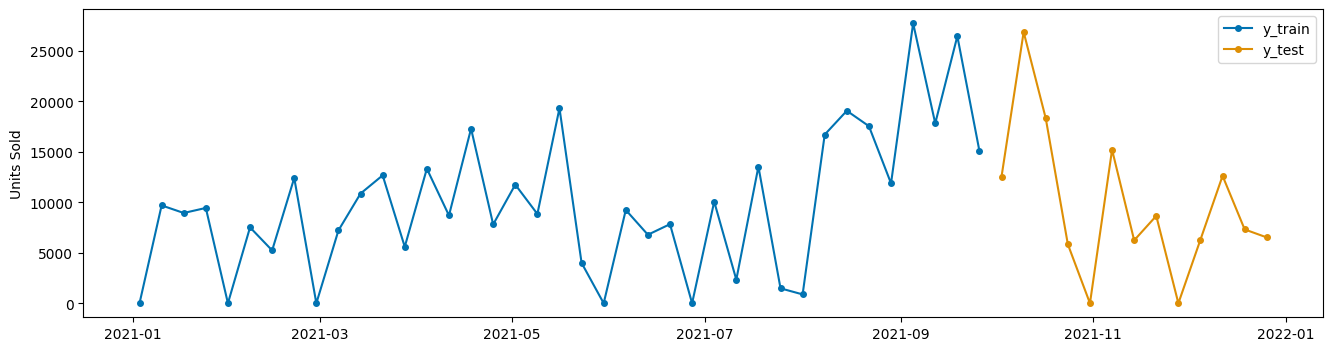

In [1880]:
# Do train-test split
y = sportsdirect_weekly_cut['Units Sold']
y_train_sportsdirect, y_test_sportsdirect = temporal_train_test_split(y, test_size=13)

# check the time series after splitting
plot_series(y_train_sportsdirect, y_test_sportsdirect, labels=["y_train", "y_test"]);

#specific data points
fh_sportsdirect = ForecastingHorizon(y_test_sportsdirect.index, is_relative=False)
fh_sportsdirect

In [1881]:
from sktime.forecasting.arima import AutoARIMA
arima_forecaster = AutoARIMA(sp=13, suppress_warnings=True, random_state=1000)

In [1882]:
# fit forecaster to train data
arima_forecaster.fit(y_train_sportsdirect)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

AutoARIMA(random_state=1000, sp=13, suppress_warnings=True)

In [1883]:
# do prediction based on forecast horizon we already defined
y_pred_arima_sportsdirect = arima_forecaster.predict(fh=fh_sportsdirect)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


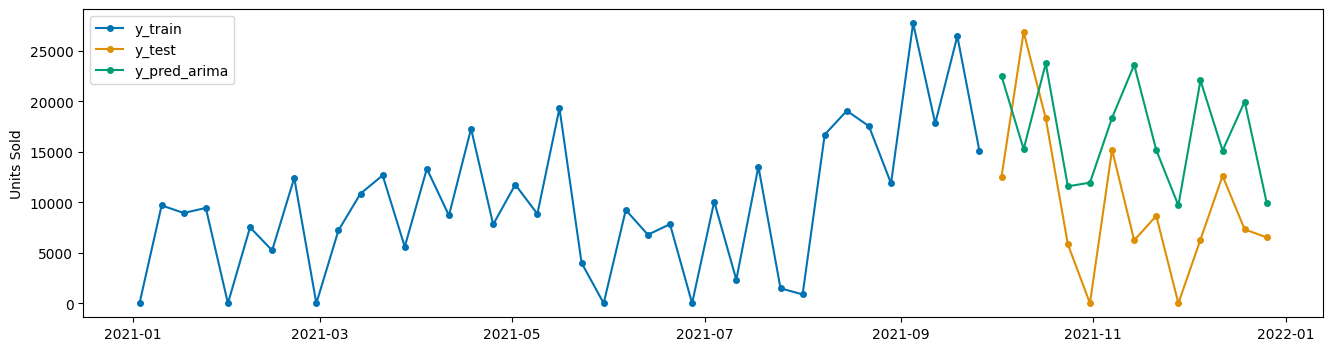

In [1884]:
# plot the forecast result
plot_series(y_train_sportsdirect, y_test_sportsdirect, y_pred_arima_sportsdirect, labels=["y_train", "y_test", "y_pred_arima"]);

**Check Model Specs**

In [1885]:
arima_forecaster.get_fitted_params()

{'ar.L1': 0.8490314457604434,
 'ma.L1': -0.634354475540722,
 'ma.L2': 0.462246525954406,
 'ar.S.L13': -0.45278223080122265,
 'sigma2': 35205385.02197786,
 'order': (1, 0, 2),
 'seasonal_order': (1, 1, 0, 13),
 'aic': 534.3312511254674,
 'aicc': 537.3312511254674,
 'bic': 540.6217338155748,
 'hqic': 536.1426825335619}

In [1886]:
arima_forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   39
Model:             SARIMAX(1, 0, 2)x(1, 1, [], 13)   Log Likelihood                -262.166
Date:                             Sat, 26 Apr 2025   AIC                            534.331
Time:                                     21:49:44   BIC                            540.622
Sample:                                 01-03-2021   HQIC                           536.143
                                      - 09-26-2021                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8490      0.194      4.374      0.000       0.469       1.229
ma.L1         -0.6344      0.219     -2.900      0.004      -1.063      -0.206
ma.L2          0.4622      0.264      1.753      0.080      -0.055       0.979
ar.S.L13      -0.4528      0.237     -1.909      0.056      -0.918       0.012
sigma2      3.521e+07   2.64e-09   1.34e+16      0.000    3.52e+07    3.52e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.78   Prob(JB):                         0.92
Heteroskedasticity (H):               0.98   Skew:                            -0.02
Prob(H) (two-sided):                  0.97   Kurtosis:                         2.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.54e+33. Standard errors may be unstable.
"""

### Model Diagnostic

In [1887]:
# find residuals
residuals_sportsdirect = y_test_sportsdirect - y_pred_arima_sportsdirect

**Plot Residuals**

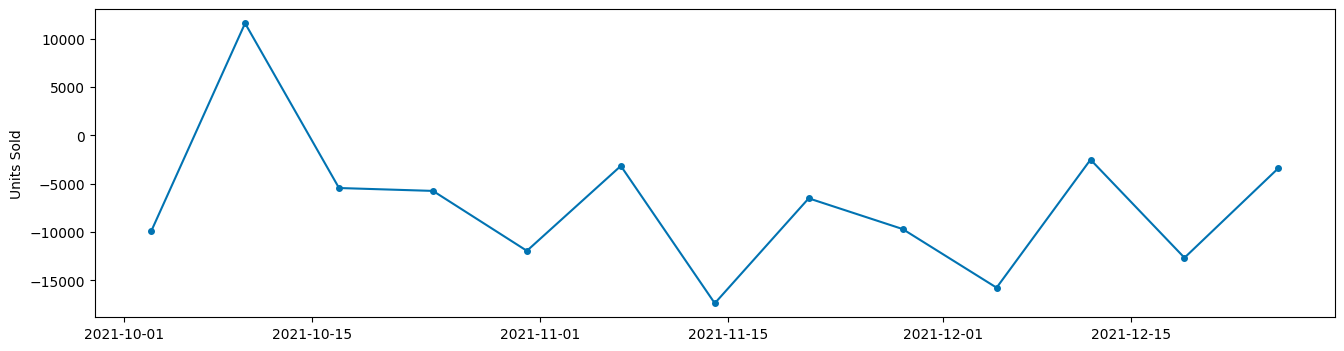

In [1888]:
plot_series(residuals_sportsdirect);

**Normality of Residuals**

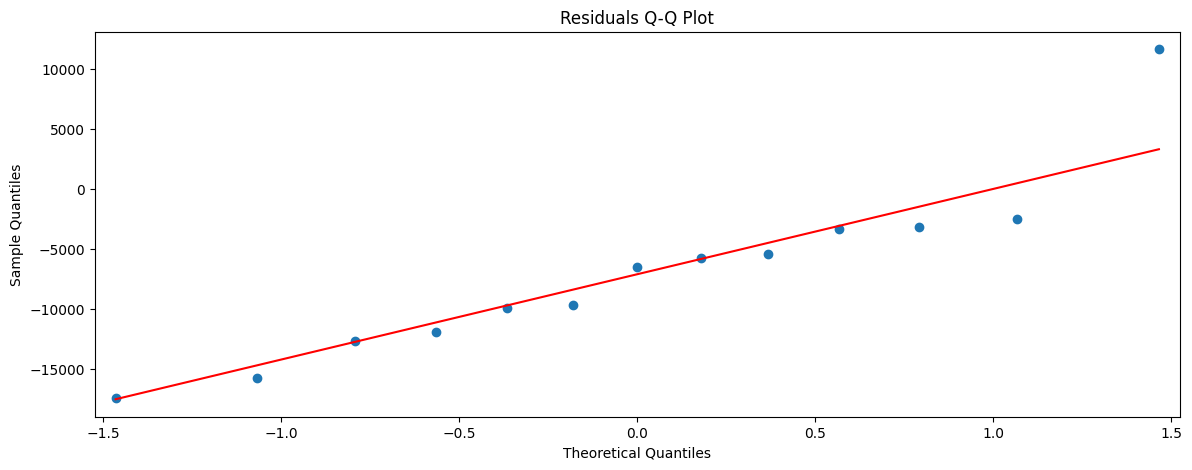

In [1889]:
sm.qqplot(residuals_sportsdirect, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

In [1890]:
mean_absolute_percentage_error(y_test_sportsdirect, y_pred_arima_sportsdirect) * 100

7.494770152394631e+20

### **ARIMA for Walmart**

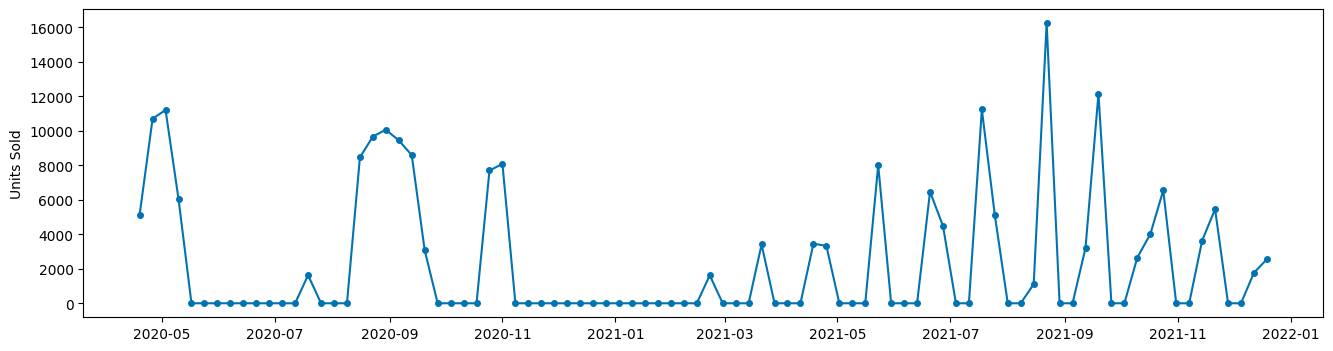

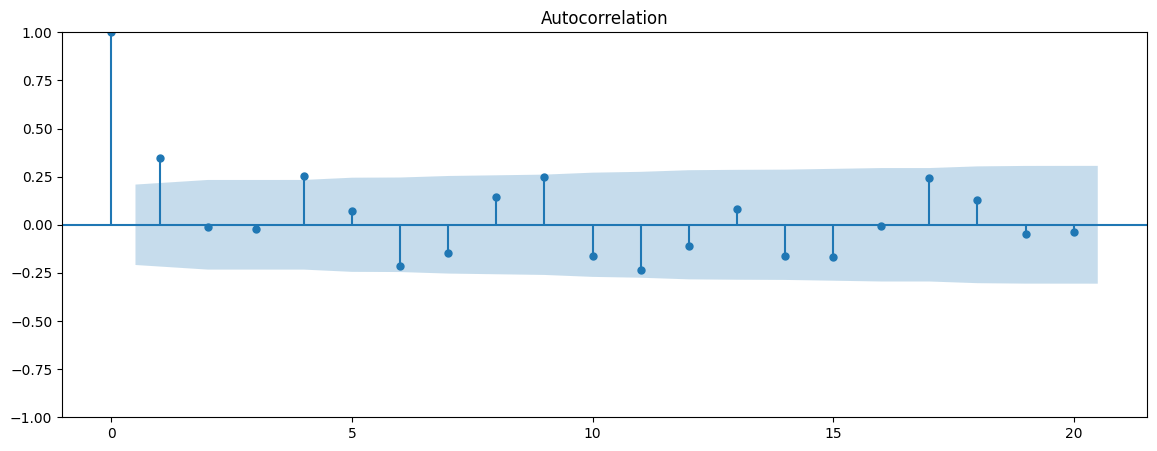

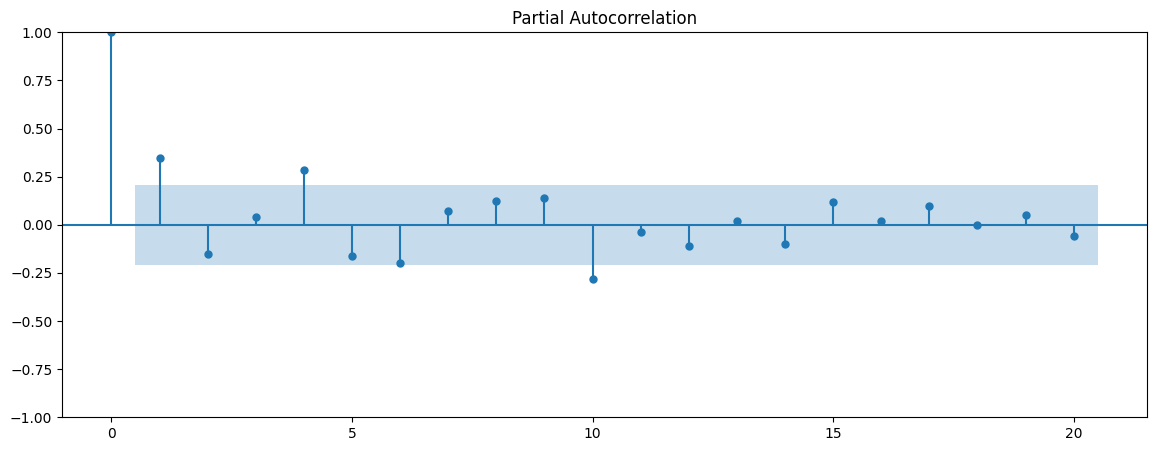

In [1891]:
# Plot Time Series Data
plot_series(walmart_weekly['Units Sold']);

# plot ACF
plot_acf(walmart_weekly['Units Sold']).set_size_inches((14,5));

# plot PACF
plot_pacf(walmart_weekly['Units Sold']).set_size_inches((14,5));

[**Differenced Version of Units Sold**]

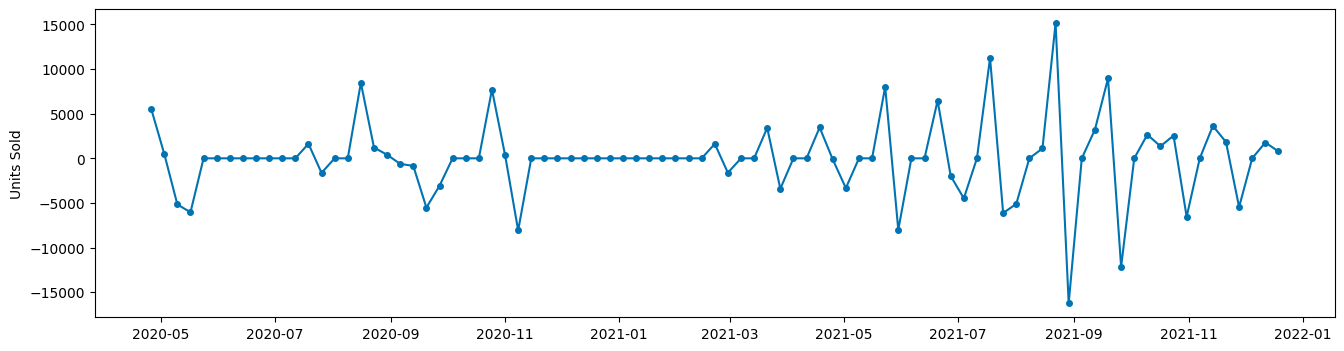

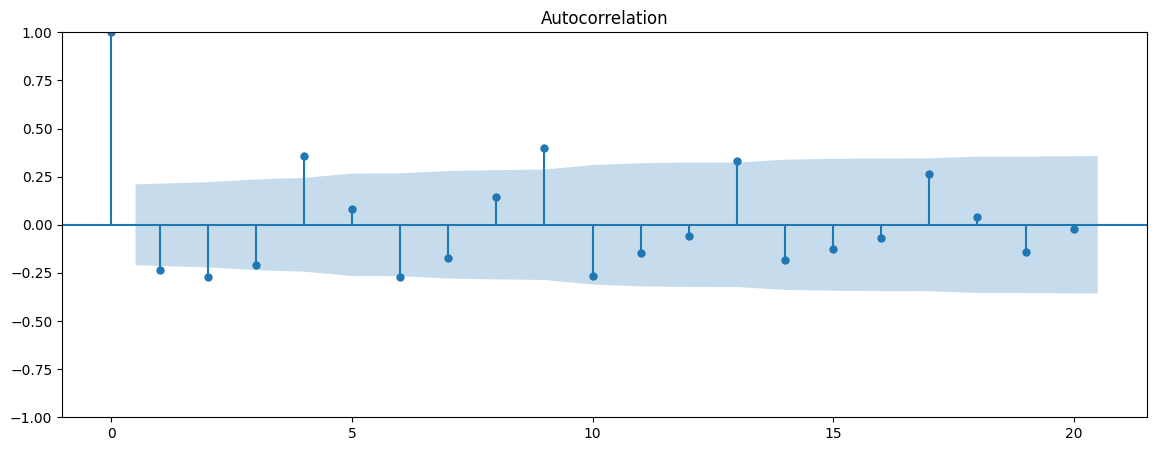

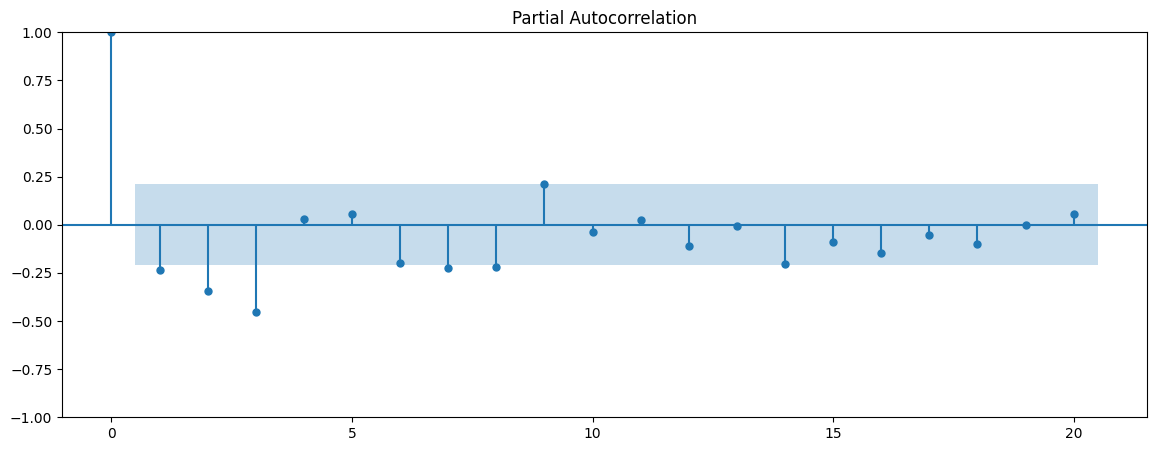

In [1892]:
# plot time series data
plot_series(walmart_weekly['Units Sold'].diff());

# plot ACF
plot_acf(walmart_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

# plot PACF
plot_pacf(walmart_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

[**Log-transformed Version of Units Sold**]

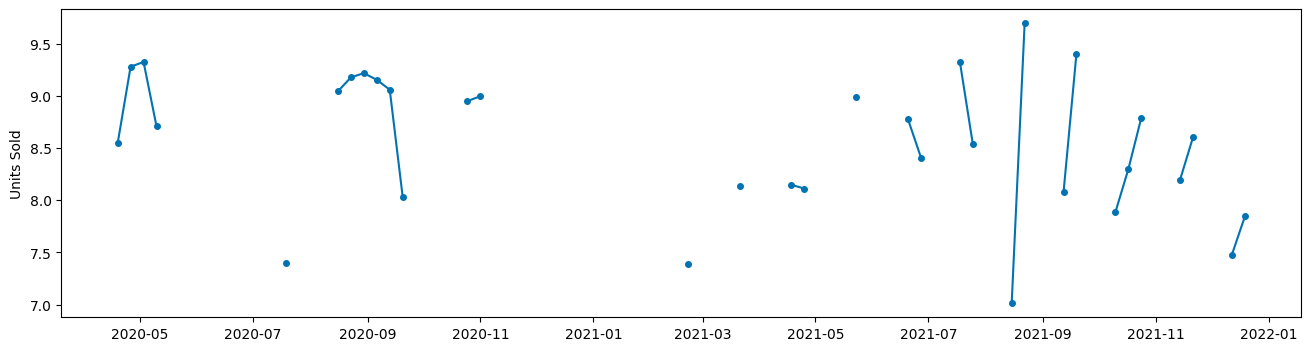

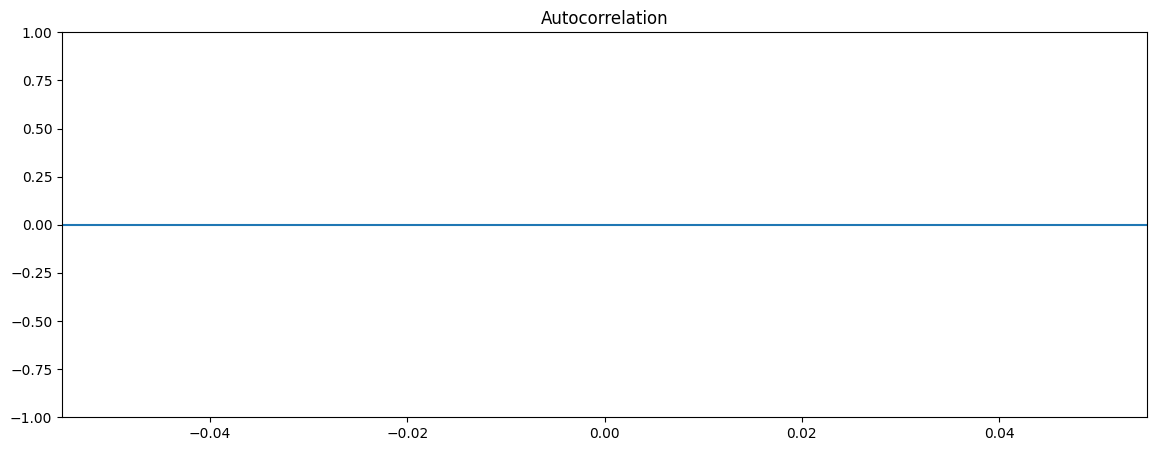

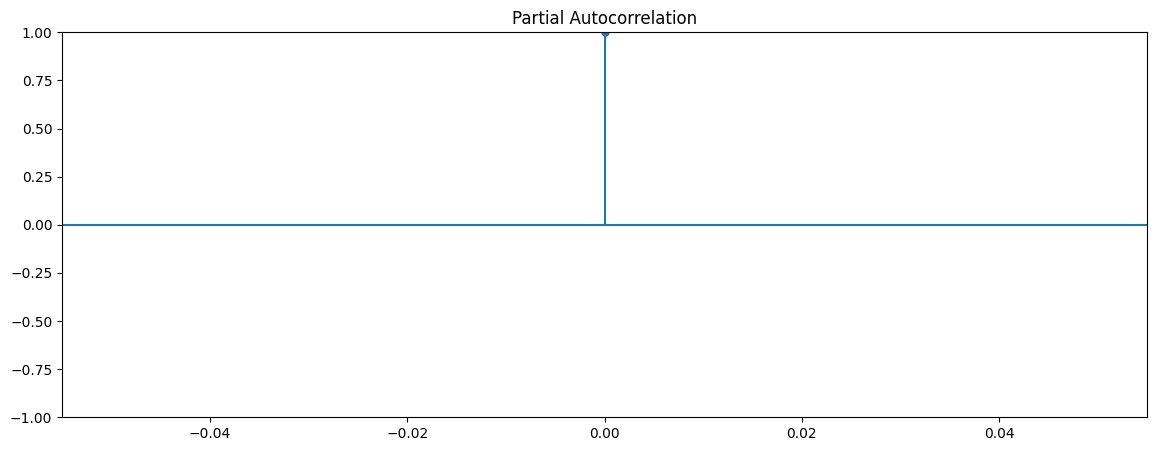

In [1893]:
# plot time series data
plot_series(np.log(walmart_weekly['Units Sold']));

# plot ACF
plot_acf(np.log(walmart_weekly['Units Sold'])).set_size_inches((14,5));

# plot PACF
plot_pacf(np.log(walmart_weekly['Units Sold'])).set_size_inches((14,5));

### Modelling

ForecastingHorizon(['2021-09-26', '2021-10-03', '2021-10-10', '2021-10-17',
               '2021-10-24', '2021-10-31', '2021-11-07', '2021-11-14',
               '2021-11-21', '2021-11-28', '2021-12-05', '2021-12-12',
               '2021-12-19'],
              dtype='datetime64[ns]', freq='W-SUN', is_relative=False)

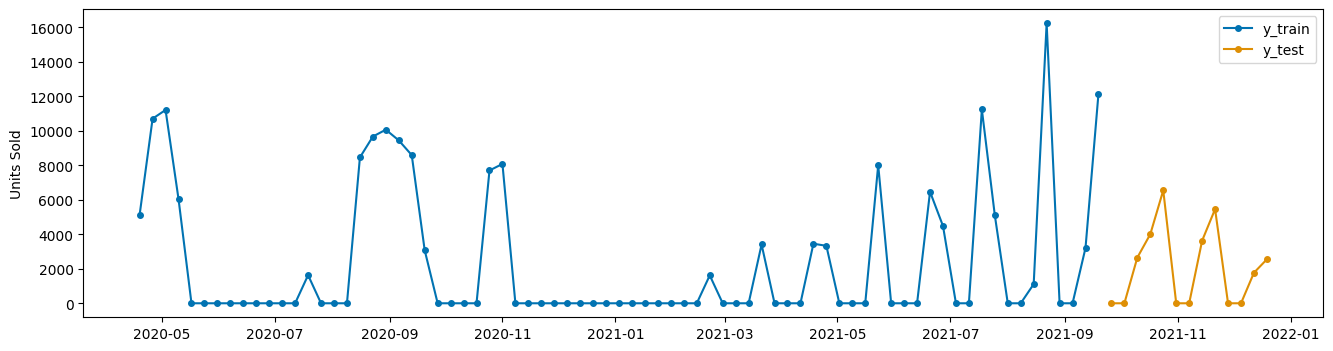

In [1894]:
# Do train-test split
y = walmart_weekly['Units Sold']
y_train_walmart, y_test_walmart = temporal_train_test_split(y, test_size=13)

# check the time series after splitting
plot_series(y_train_walmart, y_test_walmart, labels=["y_train", "y_test"]);

#specific data points
fh_walmart = ForecastingHorizon(y_test_walmart.index, is_relative=False)
fh_walmart

In [1895]:
from sktime.forecasting.arima import AutoARIMA
arima_forecaster = AutoARIMA(sp=13, suppress_warnings=True, random_state=1000)

In [1896]:
# fit forecaster to train data
arima_forecaster.fit(y_train_walmart)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

AutoARIMA(random_state=1000, sp=13, suppress_warnings=True)

In [1897]:
# do prediction based on forecast horizon we already defined
y_pred_arima_walmart = arima_forecaster.predict(fh=fh_walmart)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


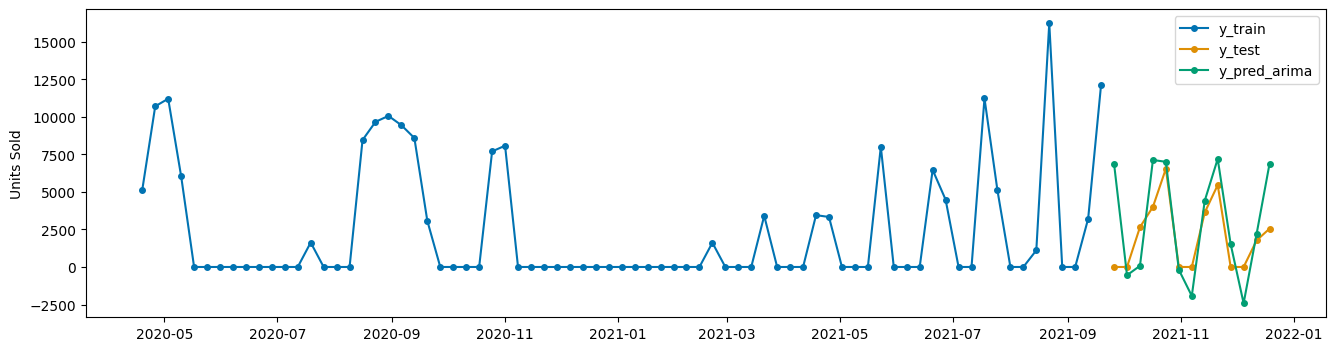

In [1898]:
# plot the forecast result
plot_series(y_train_walmart, y_test_walmart, y_pred_arima_walmart, labels=["y_train", "y_test", "y_pred_arima"]);

**Check Model Specs**

In [1899]:
arima_forecaster.get_fitted_params()

{'intercept': 1555.711925911782,
 'ar.L1': 0.5141220240402227,
 'ar.L2': -0.730096191323653,
 'ar.L3': 0.23905884965504734,
 'ar.L4': 0.28685618810400626,
 'ma.L1': -0.03903631066029306,
 'ma.L2': 0.7508053853118624,
 'sigma2': 10406382.594435746,
 'order': (4, 0, 2),
 'seasonal_order': (0, 0, 0, 13),
 'aic': 1441.0178246992934,
 'aicc': 1443.1996428811117,
 'bic': 1459.557729607584,
 'hqic': 1448.4206051464207}

In [1900]:
arima_forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   75
Model:               SARIMAX(4, 0, 2)   Log Likelihood                -712.509
Date:                Sat, 26 Apr 2025   AIC                           1441.018
Time:                        21:49:51   BIC                           1459.558
Sample:                    04-19-2020   HQIC                          1448.421
                         - 09-19-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1555.7119   1156.538      1.345      0.179    -711.061    3822.485
ar.L1          0.5141      0.170      3.018      0.003       0.180       0.848
ar.L2         -0.7301      0.223     -3.278      0.001      -1.167      -0.294
ar.L3          0.2391      0.171      1.398      0.162      -0.096       0.574
ar.L4          0.2869      0.143      2.011      0.044       0.007       0.566
ma.L1         -0.0390      0.153     -0.256      0.798      -0.338       0.260
ma.L2          0.7508      0.207      3.622      0.000       0.344       1.157
sigma2      1.041e+07      0.464   2.24e+07      0.000    1.04e+07    1.04e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                17.62
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.23   Skew:                             0.99
Prob(H) (two-sided):                  0.61   Kurtosis:                         4.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.82e+22. Standard errors may be unstable.
"""

### Model Diagnostic

In [1901]:
# find residuals
residuals_walmart = y_test_walmart - y_pred_arima_walmart

**Plot Residuals**

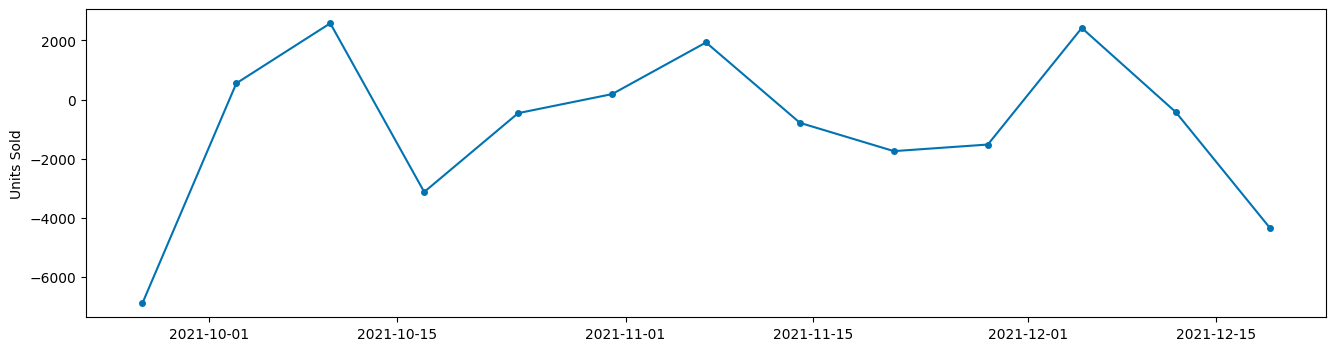

In [1902]:
plot_series(residuals_walmart);

**Normality of Residuals**

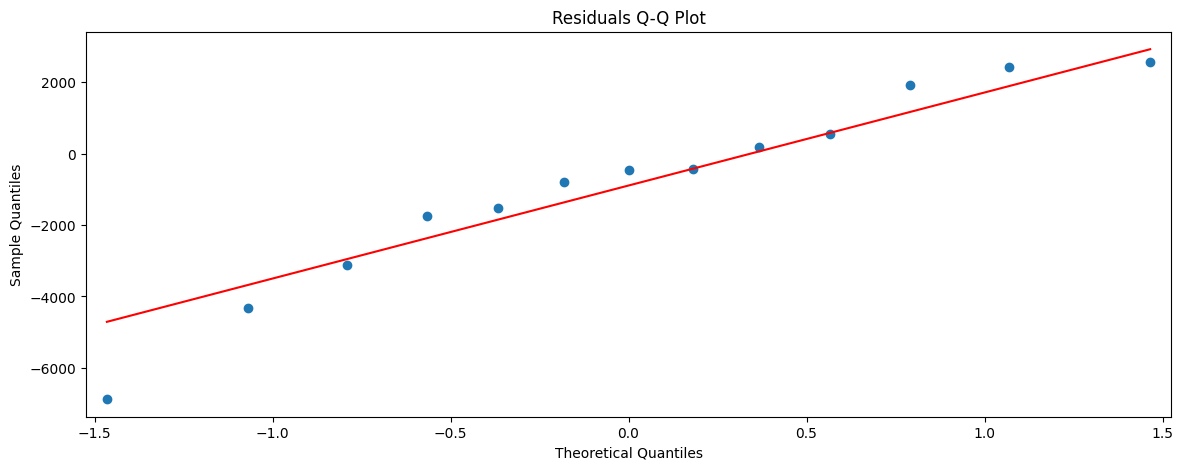

In [1903]:
sm.qqplot(residuals_walmart, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

In [1904]:
mean_absolute_percentage_error(y_test_walmart, y_pred_arima_walmart) * 100

4.668861045820332e+20

### **ARIMA for West Gear**

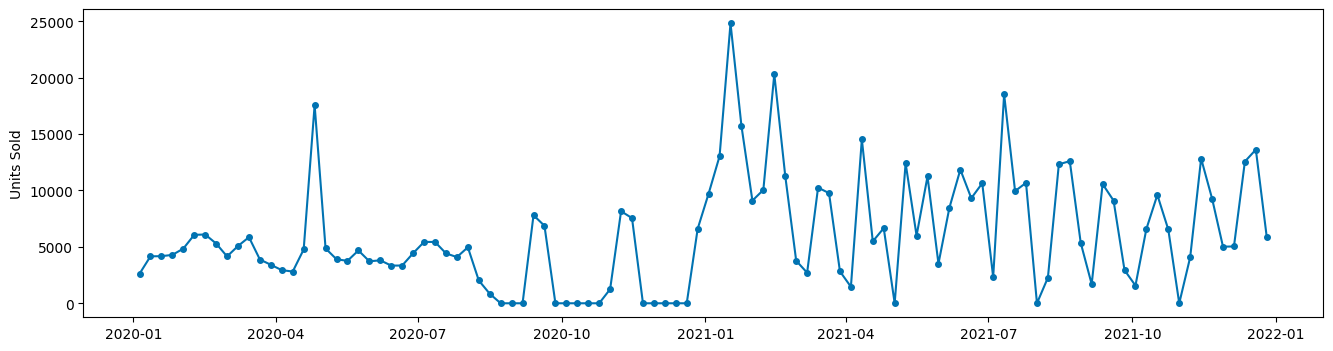

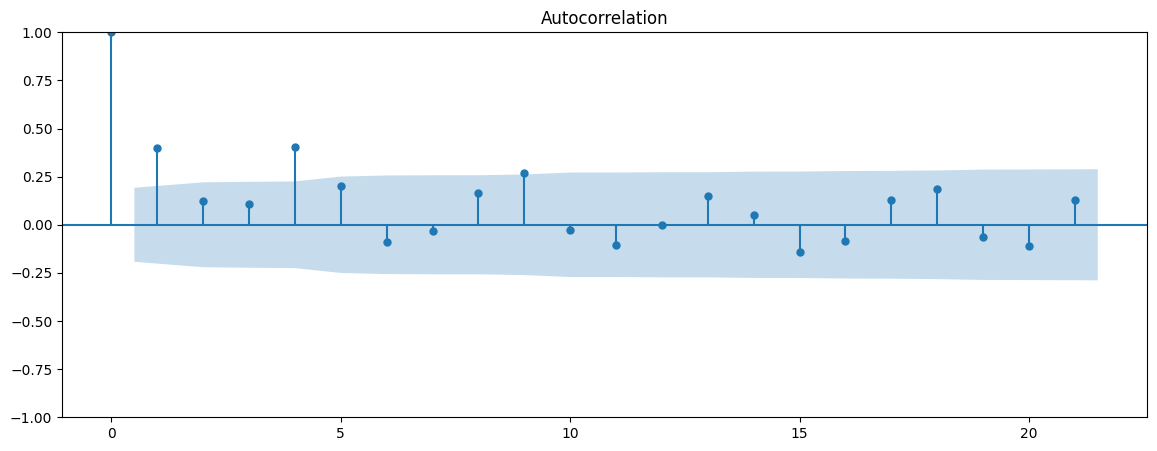

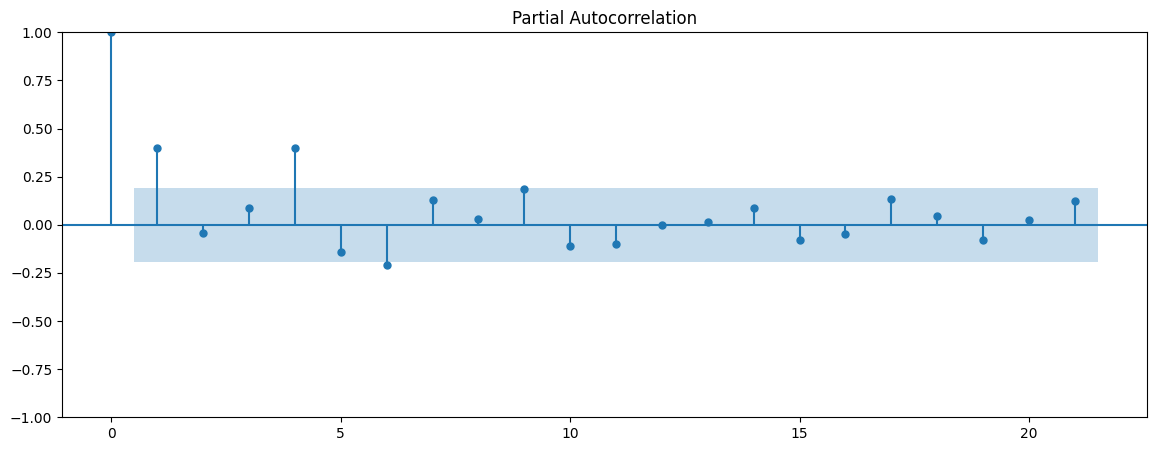

In [1905]:
# Plot Time Series Data
plot_series(westgear_weekly['Units Sold']);

# plot ACF
plot_acf(westgear_weekly['Units Sold']).set_size_inches((14,5));

# plot PACF
plot_pacf(westgear_weekly['Units Sold']).set_size_inches((14,5));

[**Differenced Version of Units Sold**]

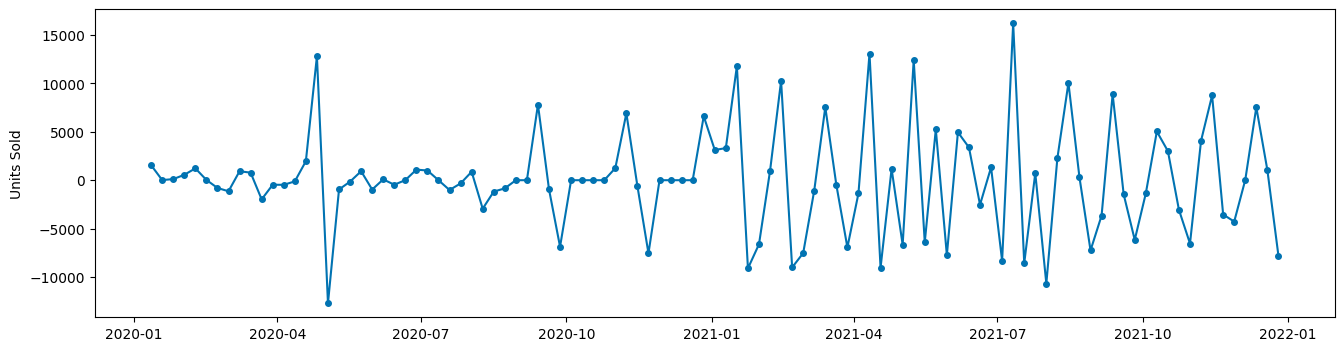

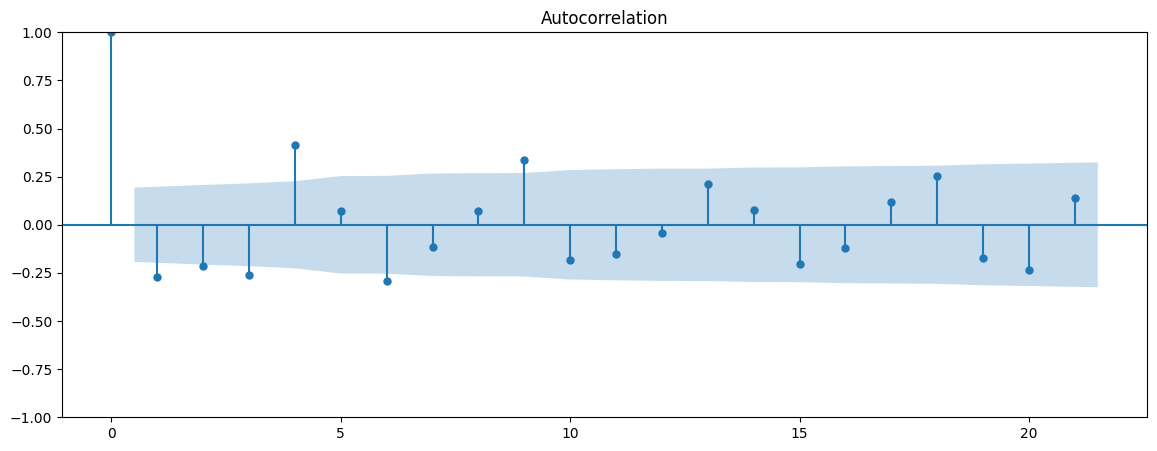

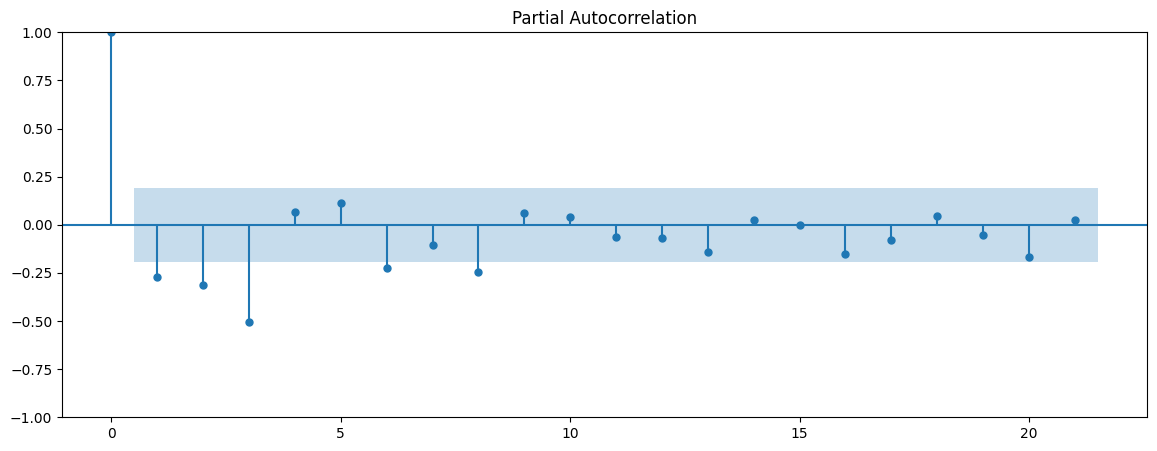

In [1906]:
# plot time series data
plot_series(westgear_weekly['Units Sold'].diff());

# plot ACF
plot_acf(westgear_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

# plot PACF
plot_pacf(westgear_weekly['Units Sold'].diff().dropna()).set_size_inches((14,5));

[**Log-transformed Version of Units Sold**]

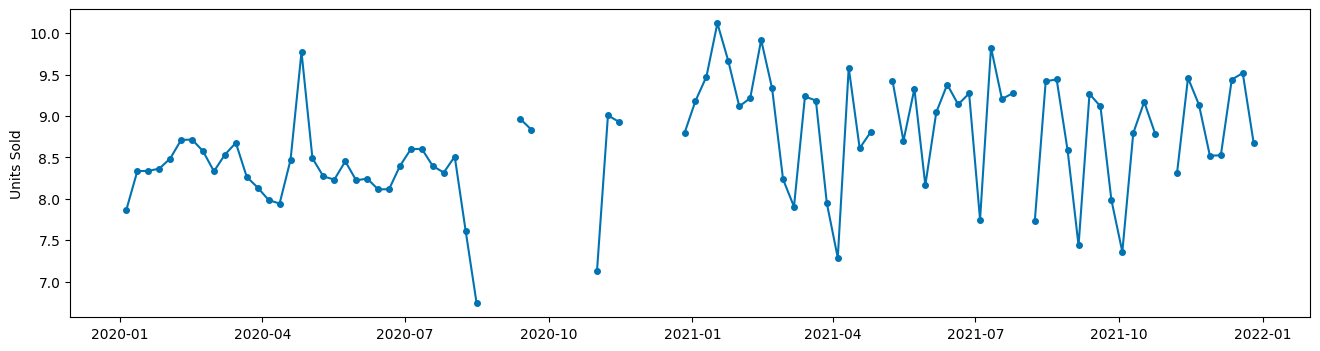

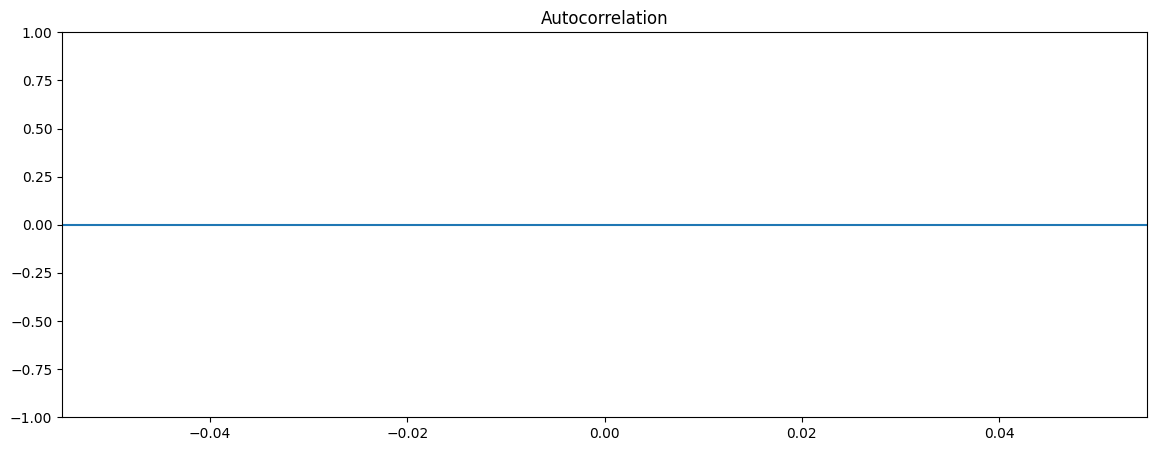

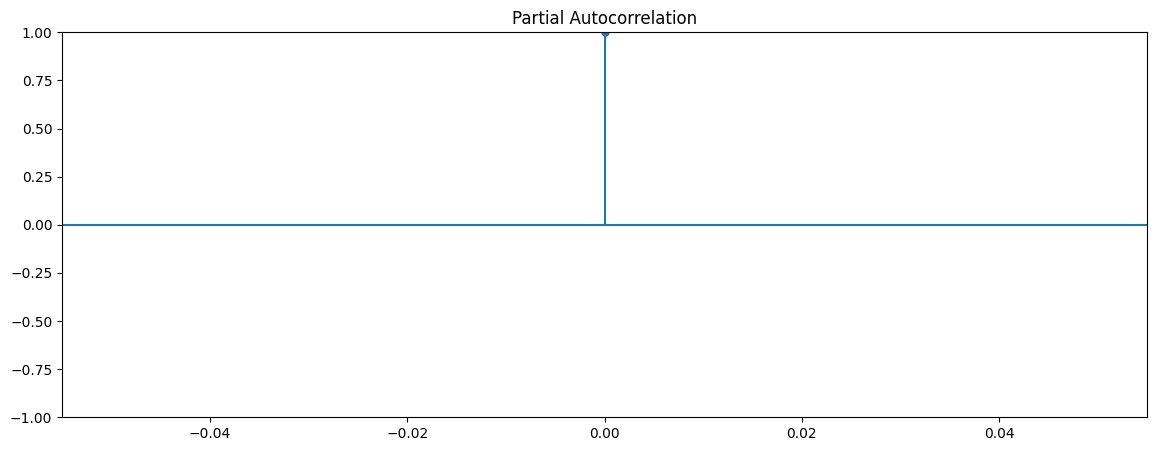

In [1907]:
# plot time series data
plot_series(np.log(westgear_weekly['Units Sold']));

# plot ACF
plot_acf(np.log(westgear_weekly['Units Sold'])).set_size_inches((14,5));

# plot PACF
plot_pacf(np.log(westgear_weekly['Units Sold'])).set_size_inches((14,5));

### Modelling

ForecastingHorizon(['2021-10-03', '2021-10-10', '2021-10-17', '2021-10-24',
               '2021-10-31', '2021-11-07', '2021-11-14', '2021-11-21',
               '2021-11-28', '2021-12-05', '2021-12-12', '2021-12-19',
               '2021-12-26'],
              dtype='datetime64[ns]', freq='W-SUN', is_relative=False)

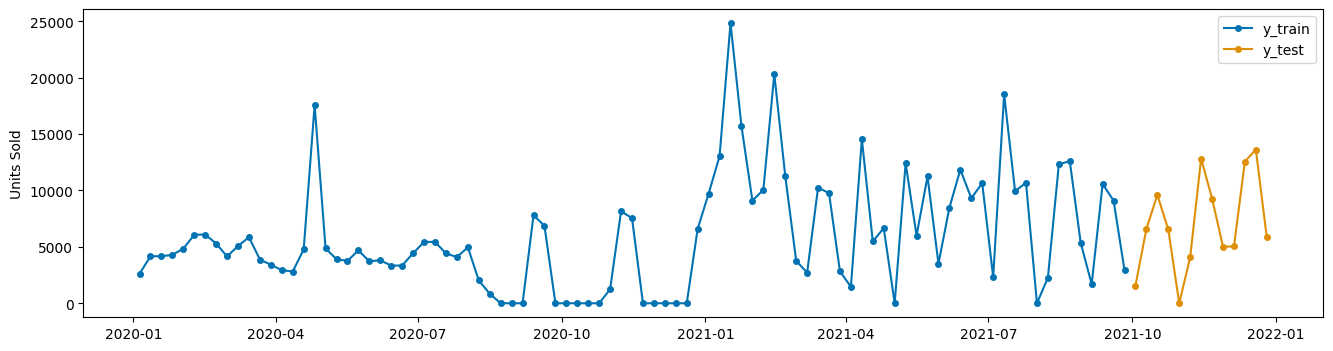

In [1908]:
# Do train-test split
y = westgear_weekly['Units Sold']
y_train_westgear, y_test_westgear = temporal_train_test_split(y, test_size=13)

# check the time series after splitting
plot_series(y_train_westgear, y_test_westgear, labels=["y_train", "y_test"]);

#specific data points
fh_westgear = ForecastingHorizon(y_test_westgear.index, is_relative=False)
fh_westgear

In [1909]:
from sktime.forecasting.arima import AutoARIMA
arima_forecaster = AutoARIMA(sp=13, suppress_warnings=True, random_state=1000)

In [1910]:
# fit forecaster to train data
arima_forecaster.fit(y_train_westgear)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

AutoARIMA(random_state=1000, sp=13, suppress_warnings=True)

In [1911]:
# do prediction based on forecast horizon we already defined
y_pred_arima_westgear = arima_forecaster.predict(fh=fh_westgear)

c:\Anacondaa\envs\time_series_env\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


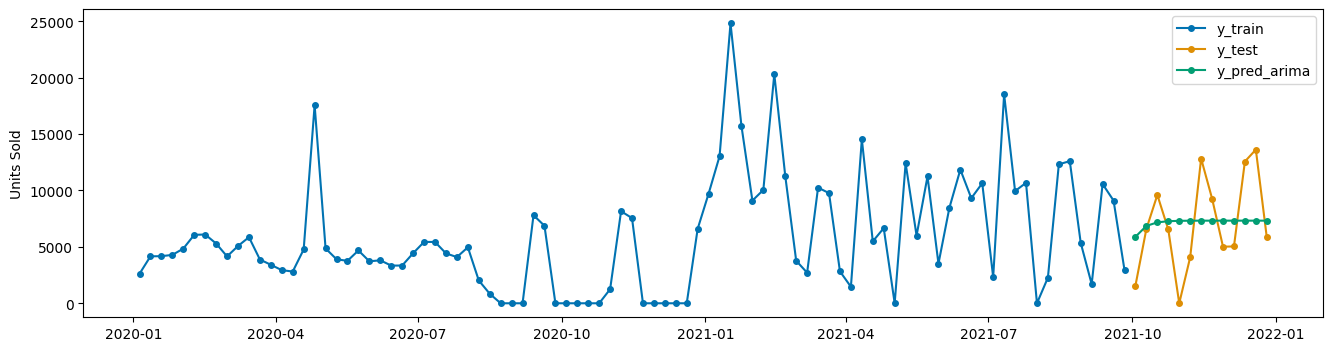

In [1912]:
# plot the forecast result
plot_series(y_train_westgear, y_test_westgear, y_pred_arima_westgear, labels=["y_train", "y_test", "y_pred_arima"]);

In [1913]:
arima_forecaster.get_fitted_params()

{'ar.L1': 0.3260843906512331,
 'ma.L1': -0.9258570380839246,
 'sigma2': 21268493.103384893,
 'order': (1, 1, 1),
 'seasonal_order': (0, 0, 0, 13),
 'aic': 1781.3910289084706,
 'aicc': 1781.6700986759124,
 'bic': 1788.8904579194614,
 'hqic': 1784.4152395108683}

In [1914]:
arima_forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   91
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -887.696
Date:                Sat, 26 Apr 2025   AIC                           1781.391
Time:                        21:49:58   BIC                           1788.890
Sample:                    01-05-2020   HQIC                          1784.415
                         - 09-26-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3261      0.087      3.743      0.000       0.155       0.497
ma.L1         -0.9259      0.042    -21.855      0.000      -1.009      -0.843
sigma2      2.127e+07   7.51e-10   2.83e+16      0.000    2.13e+07    2.13e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                35.75
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               3.80   Skew:                             1.13
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.56e+31. Standard errors may be unstable.
"""

### Model Diagnostic

In [1915]:
# find residuals
residuals_westgear = y_test_westgear - y_pred_arima_westgear

**Plot Residuals**

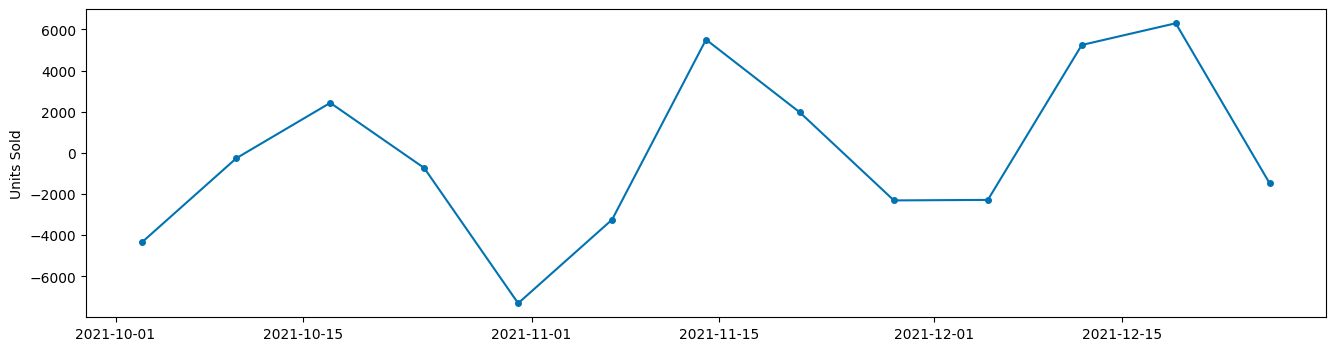

In [1916]:
plot_series(residuals_westgear);

**Normality of Residuals**

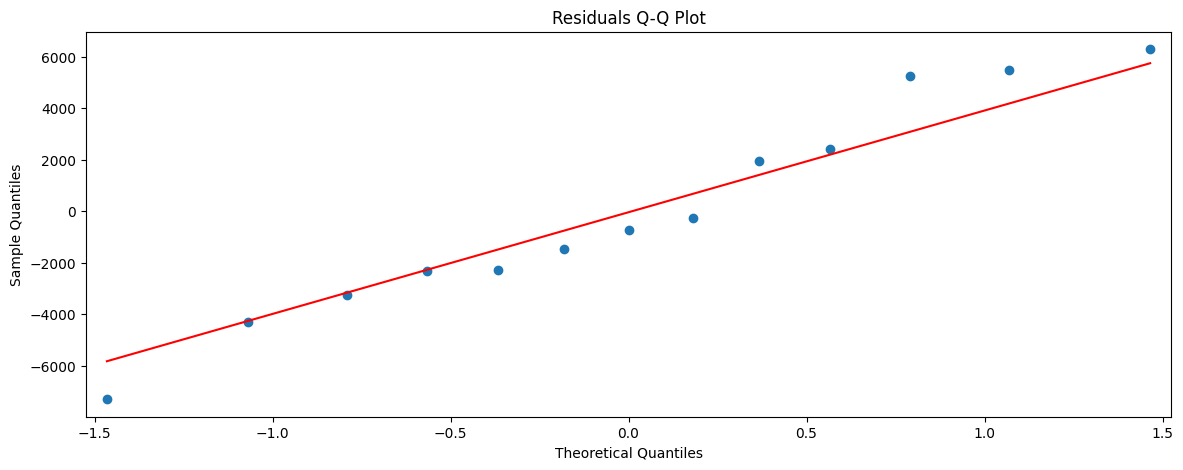

In [1917]:
sm.qqplot(residuals_westgear, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

In [1918]:
mean_absolute_percentage_error(y_test_westgear, y_pred_arima_westgear) * 100

2.5319945561500988e+20

## **PROPHET**

### **Foot Locker**

### Modeling

**Re-Preprocess Data**

In [1919]:
# Set 'Date' sebagai index
footlocker_df = footlocker_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
footlocker_df.index = pd.DatetimeIndex(footlocker_df.index, freq='infer')

footlocker = footlocker_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original footlocker
footlocker = footlocker.resample('W').sum()

**Train-Test Split**

In [1920]:
# Do train-test split
y_train_fl, y_test_fl = temporal_train_test_split(footlocker, test_size=13)

#specific data points
fh_fl = ForecastingHorizon(y_test_fl.index, is_relative=False)

**Modeling**

In [1921]:
# define Prophet model
prophet_forecaster = Prophet(
    seasonality_mode='additive',
    yearly_seasonality = False,
    weekly_seasonality = True,
    daily_seasonality = False,
)

In [1922]:
# fit forecaster to data
prophet_forecaster.fit(y_train_fl)

21:49:58 - cmdstanpy - INFO - Chain [1] start processing
21:49:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet(daily_seasonality=False, weekly_seasonality=True,
        yearly_seasonality=False)

In [1923]:
# do prediction based on forecast horizon we already defined
y_pred_prophet_fl = prophet_forecaster.predict(fh=fh_fl)

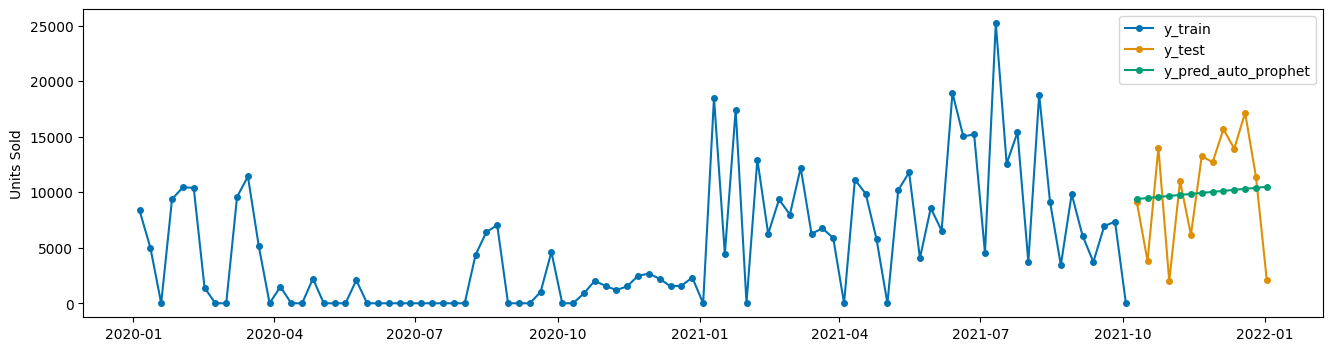

In [1924]:
# plot the forecast result
plot_series(y_train_fl, y_test_fl, y_pred_prophet_fl, labels=["y_train", "y_test", "y_pred_auto_prophet"]);

**Set New Index Type**

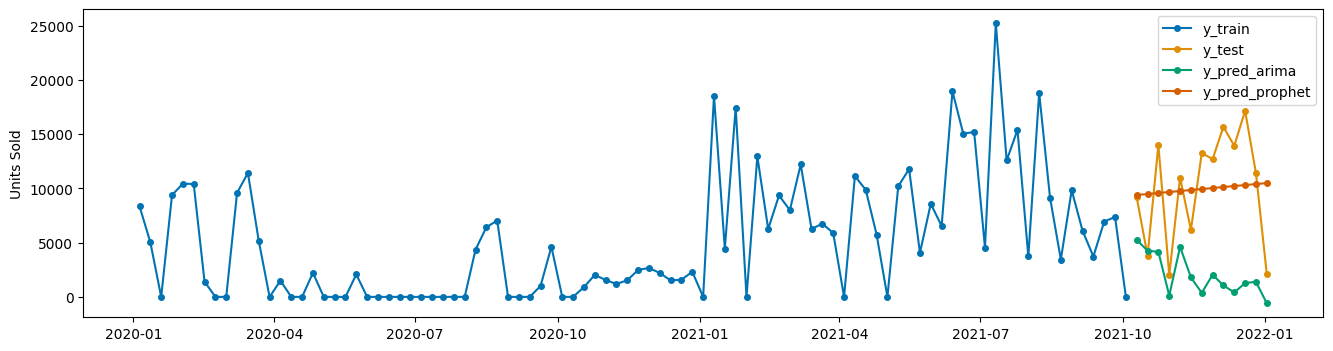

In [1925]:
# plot the forecast result
plot_series(
    y_train_fl, y_test_fl, y_pred_arima_fl, y_pred_prophet_fl,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet"]
);

### Model Diagnostics

**Plot Residuals**

In [1926]:
residuals = y_test_fl - y_pred_prophet_fl

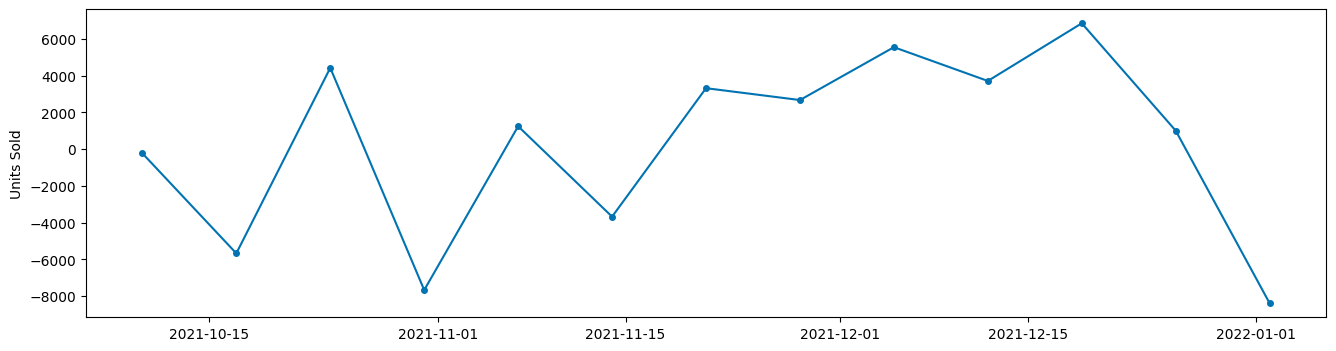

In [1927]:
plot_series(residuals);

**Normality of Residuals**

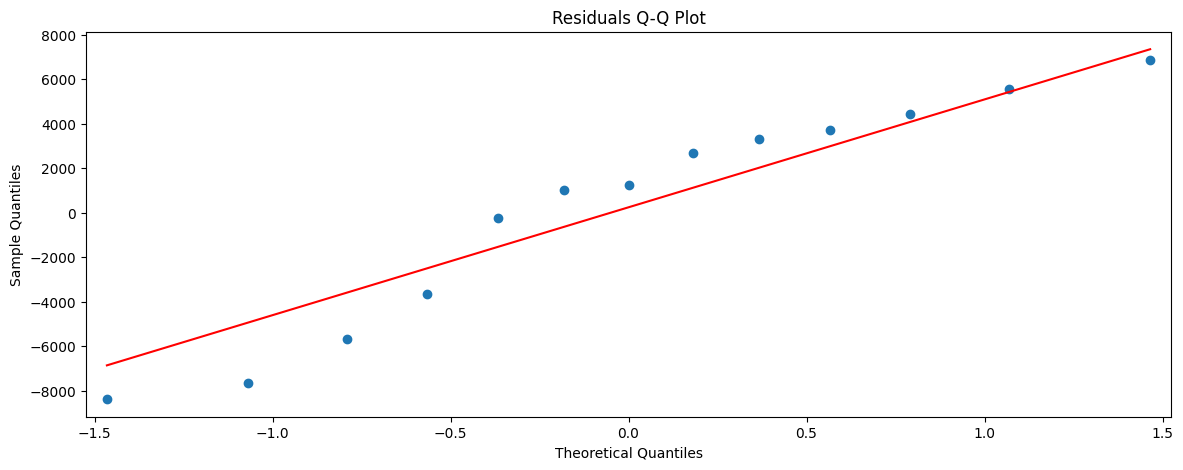

In [1928]:
sm.qqplot(residuals, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

**Random Walk Pattern of Residuals**

In [1929]:
residuals.describe()
residuals.head(10)


2021-10-10    -229.407693
2021-10-17   -5670.996730
2021-10-24    4417.414232
2021-10-31   -7667.174805
2021-11-07    1243.236157
2021-11-14   -3675.352880
2021-11-21    3314.058082
2021-11-28    2668.469045
2021-12-05    5543.880007
2021-12-12    3707.290970
Freq: W-SUN, Name: Units Sold, dtype: float64

In [1930]:
type(residuals)


pandas.core.series.Series

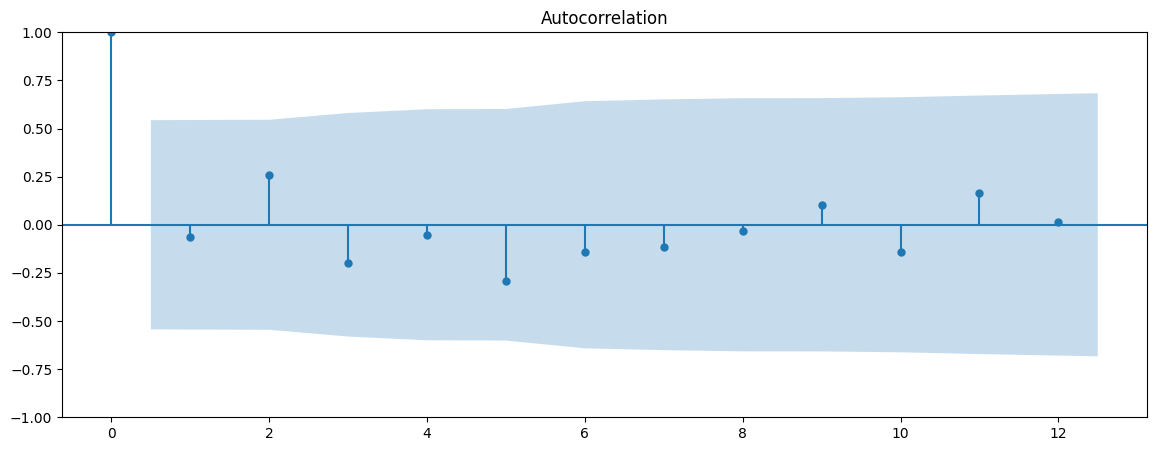

In [1931]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,  # harus Series, bukan DataFrame
    lags=12
).set_size_inches(14, 5)


### Model Evaluation

In [1932]:
mean_absolute_percentage_error(y_test_fl, y_pred_prophet_fl) * 100

91.90501369038928

### **Amazon**

### Modeling

**Re-Preprocess Data**

In [1933]:
# Set 'Date' sebagai index
amazon_df = amazon_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
amazon_df.index = pd.DatetimeIndex(amazon_df.index, freq='infer')

amazon = amazon_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original amazon
amazon = amazon.resample('W').sum()

**Train-Test Split**

In [1934]:
# Do train-test split
y_train_amazon, y_test_amazon = temporal_train_test_split(amazon, test_size=13)

#specific data points
fh_amazon = ForecastingHorizon(y_test_amazon.index, is_relative=False)

**Modeling**

In [1935]:
# define Prophet model
prophet_forecaster = Prophet(
    seasonality_mode='additive',
    yearly_seasonality = False,
    weekly_seasonality = True,
    daily_seasonality = False,
)

In [1936]:
# fit forecaster to data
prophet_forecaster.fit(y_train_amazon)

21:50:00 - cmdstanpy - INFO - Chain [1] start processing
21:50:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet(daily_seasonality=False, weekly_seasonality=True,
        yearly_seasonality=False)

In [1937]:
# do prediction based on forecast horizon we already defined
y_pred_prophet_amazon = prophet_forecaster.predict(fh=fh_amazon)

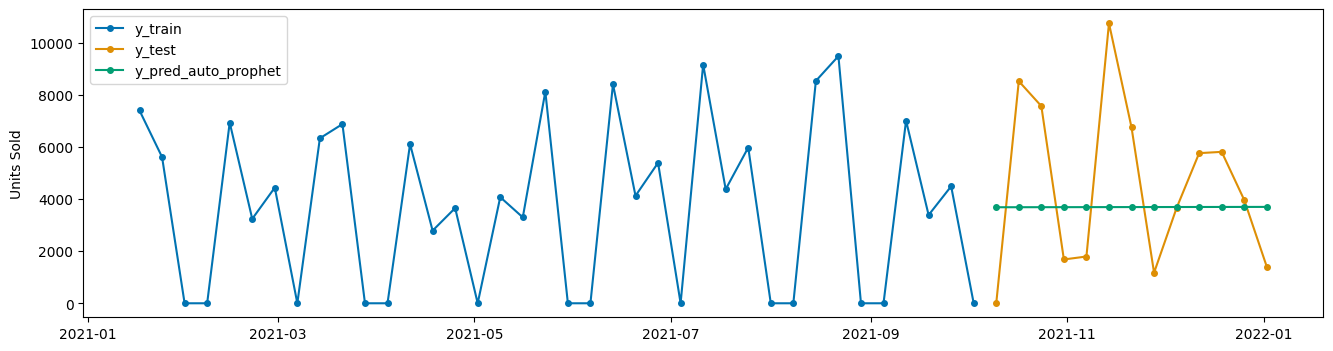

In [1938]:
# plot the forecast result
plot_series(y_train_amazon, y_test_amazon, y_pred_prophet_amazon, labels=["y_train", "y_test", "y_pred_auto_prophet"]);

**Set New Index Type**

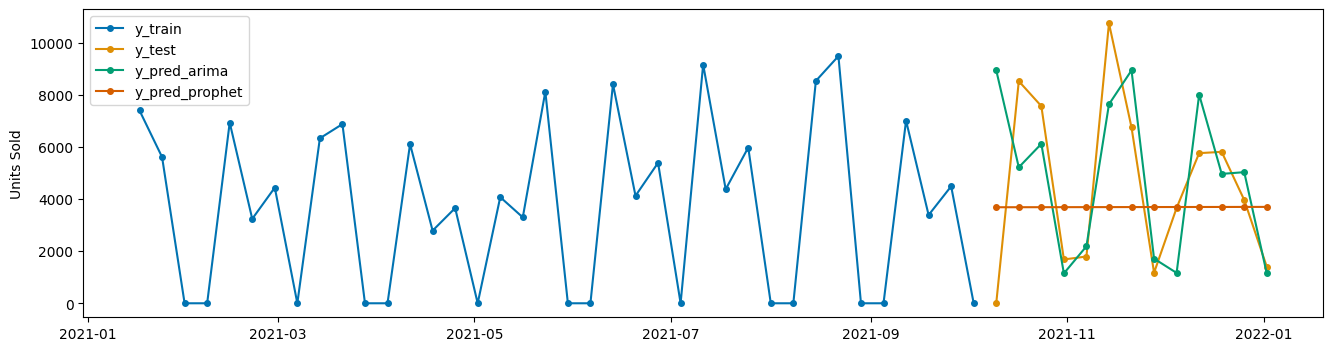

In [1939]:
# plot the forecast result
plot_series(
    y_train_amazon, y_test_amazon, y_pred_arima_amazon, y_pred_prophet_amazon,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet"]
);

### Model Diagnostics

**Plot Residuals**

In [1940]:
residuals = y_test_amazon - y_pred_prophet_amazon

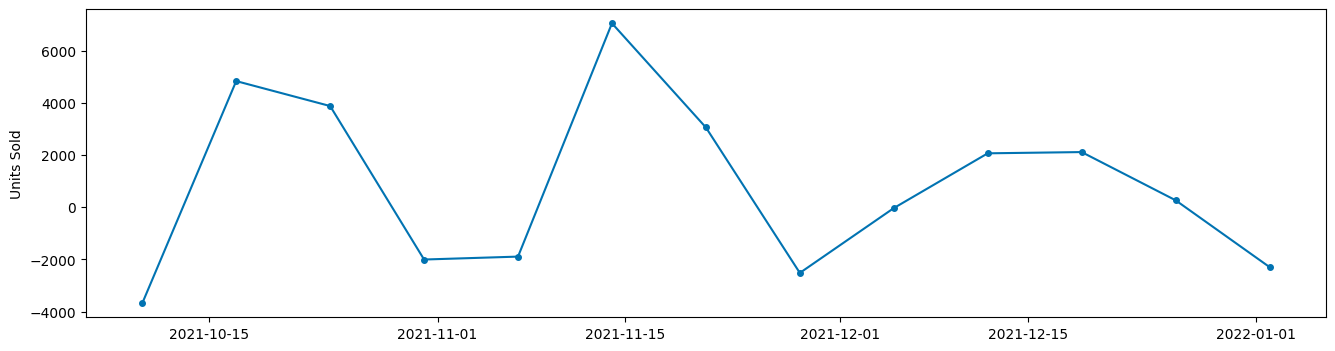

In [1941]:
plot_series(residuals);

**Normality of Residuals**

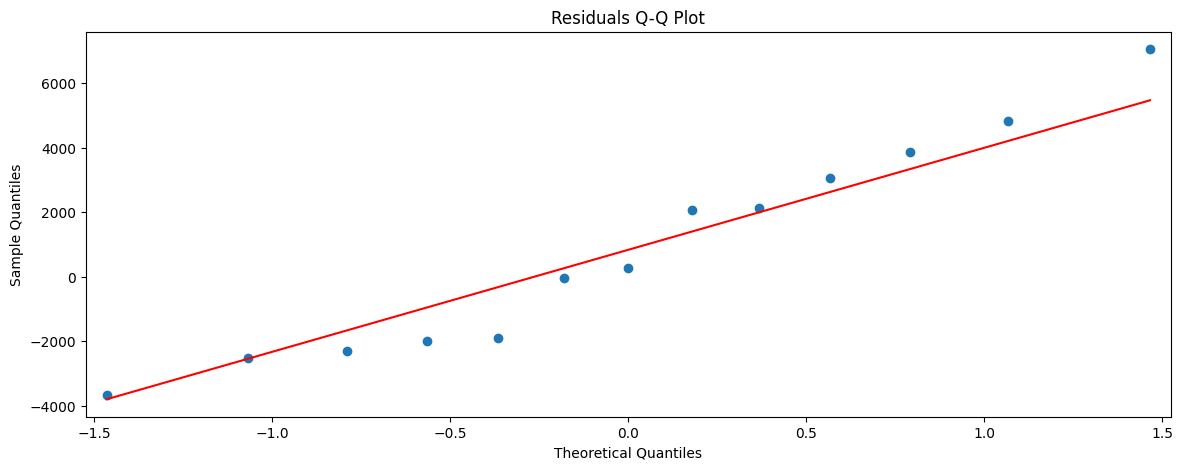

In [1942]:
sm.qqplot(residuals, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

**Random Walk Pattern of Residuals**

In [1943]:
residuals.describe()
residuals.head(10)

2021-10-10   -3684.111349
2021-10-17    4835.780830
2021-10-24    3878.673010
2021-10-31   -2006.434811
2021-11-07   -1894.542631
2021-11-14    7052.349548
2021-11-21    3057.241728
2021-11-28   -2519.866093
2021-12-05     -34.973914
2021-12-12    2065.918266
Freq: W-SUN, Name: Units Sold, dtype: float64

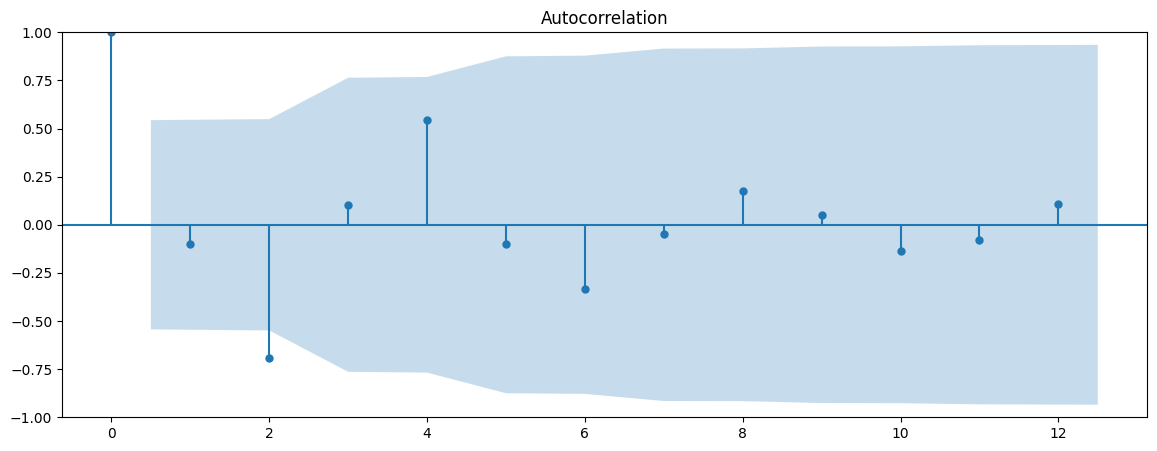

In [1944]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,  # harus Series, bukan DataFrame
    lags=12
).set_size_inches(14, 5)

### Model Evaluation

In [1945]:
mean_absolute_percentage_error(y_test_amazon, y_pred_prophet_amazon) * 100

1.2762894229380856e+20

### **Kohl's**

### Modeling

**Re-Preprocess Data**

In [1946]:
# Set 'Date' sebagai index
kohls_df = kohls_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
kohls_df.index = pd.DatetimeIndex(kohls_df.index, freq='infer')

kohls = kohls_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original kohls
kohls = kohls.resample('W').sum()

**Train-Test Split**

In [1947]:
# Do train-test split
y_train_kohls, y_test_kohls = temporal_train_test_split(kohls, test_size=13)

#specific data points
fh_kohls = ForecastingHorizon(y_test_kohls.index, is_relative=False)

**Modeling**

In [1948]:
# define Prophet model
prophet_forecaster = Prophet(
    seasonality_mode='additive',
    yearly_seasonality = False,
    weekly_seasonality = True,
    daily_seasonality = False,
)

In [1949]:
# fit forecaster to data
prophet_forecaster.fit(y_train_kohls)

21:50:02 - cmdstanpy - INFO - Chain [1] start processing
21:50:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet(daily_seasonality=False, weekly_seasonality=True,
        yearly_seasonality=False)

In [1950]:
# do prediction based on forecast horizon we already defined
y_pred_prophet_kohls = prophet_forecaster.predict(fh=fh_kohls)

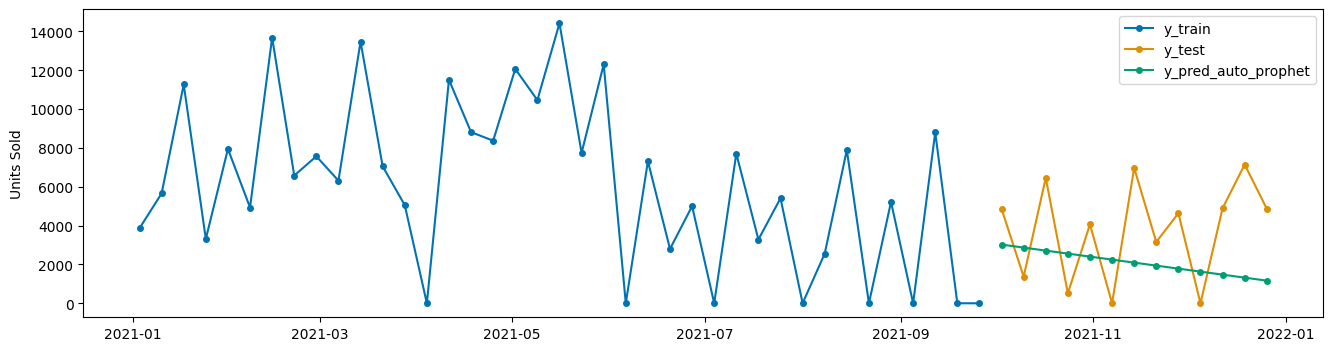

In [1951]:
# plot the forecast result
plot_series(y_train_kohls, y_test_kohls, y_pred_prophet_kohls, labels=["y_train", "y_test", "y_pred_auto_prophet"]);

**Set New Index Type**

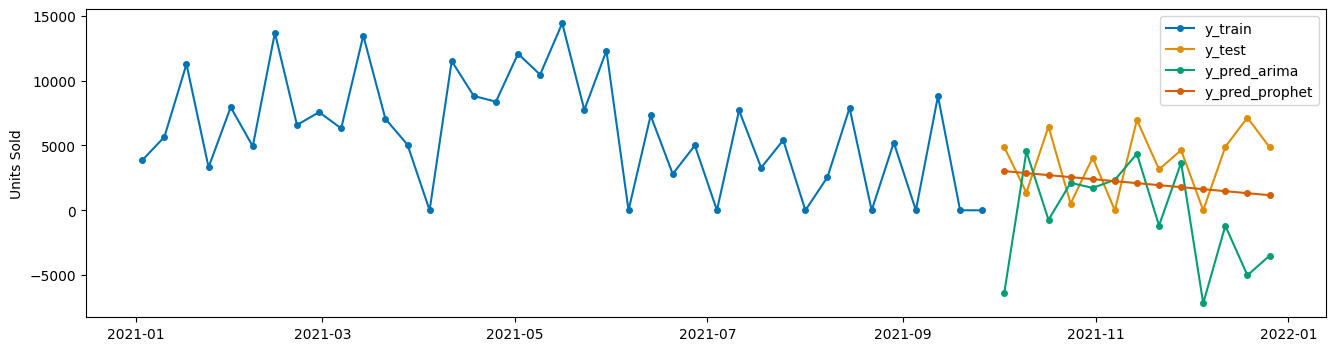

In [1952]:
# plot the forecast result
plot_series(
    y_train_kohls, y_test_kohls, y_pred_arima_kohls, y_pred_prophet_kohls,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet"]
);

### Model Diagnostics

**Plot Residuals**

In [1953]:
residuals = y_test_kohls - y_pred_prophet_kohls

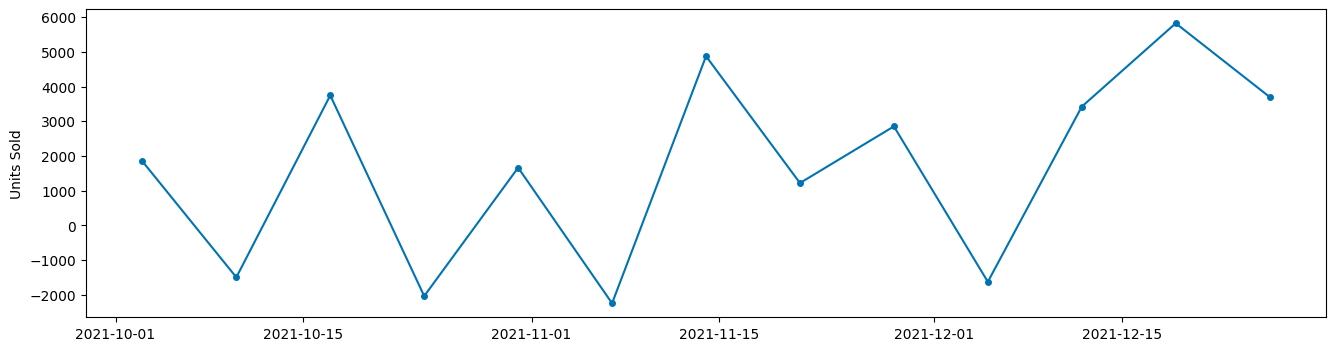

In [1954]:
plot_series(residuals);

**Normality of Residuals**

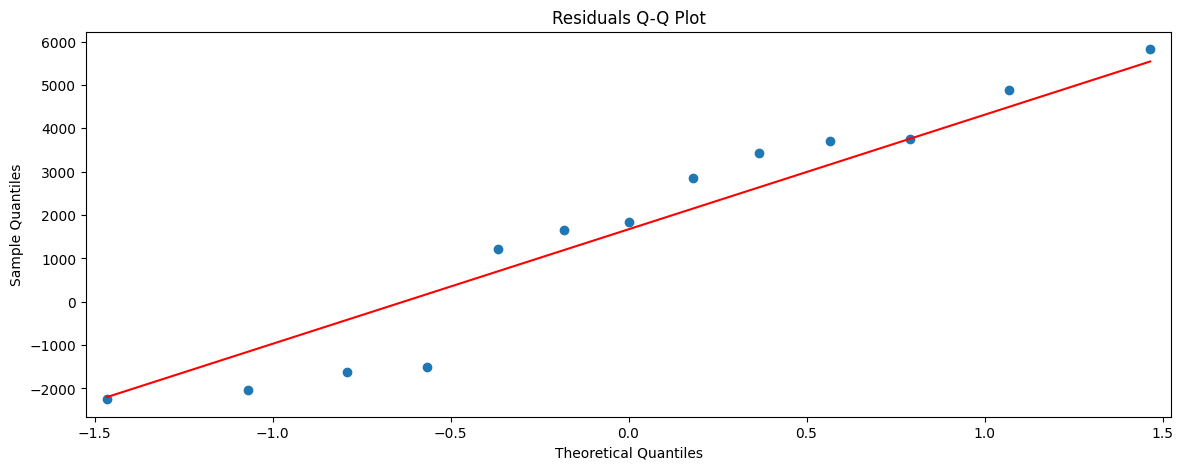

In [1955]:
sm.qqplot(residuals, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

**Random Walk Pattern of Residuals**

In [1956]:
residuals.describe()
residuals.head(10)

2021-10-03    1844.651575
2021-10-10   -1499.626932
2021-10-17    3746.094561
2021-10-24   -2041.183945
2021-10-31    1661.537548
2021-11-07   -2248.740959
2021-11-14    4875.980534
2021-11-21    1218.702028
2021-11-28    2852.423521
2021-12-05   -1629.854986
Freq: W-SUN, Name: Units Sold, dtype: float64

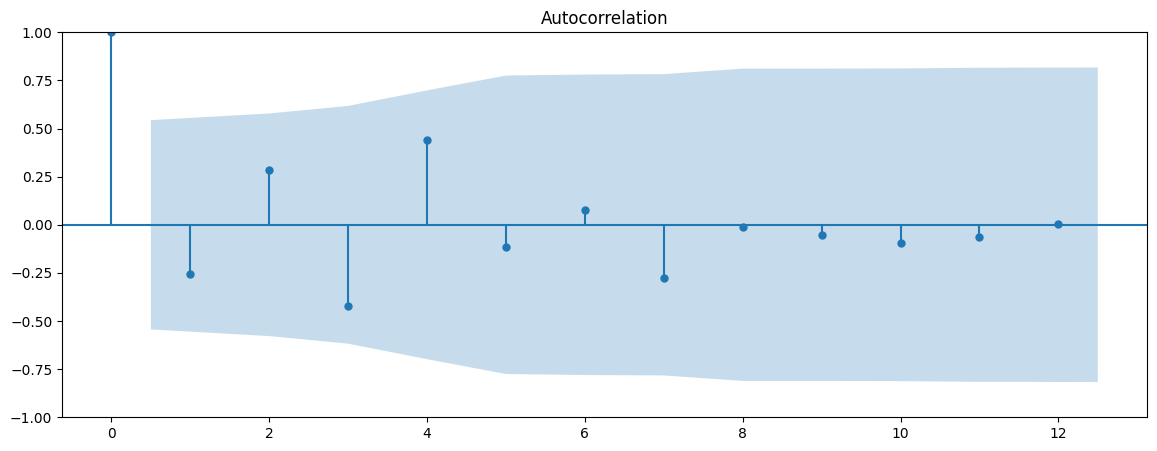

In [1957]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,  # harus Series, bukan DataFrame
    lags=12
).set_size_inches(14, 5)


### Model Evaluation

In [1958]:
mean_absolute_percentage_error(y_test_kohls, y_pred_prophet_kohls) * 100

1.3436648655405944e+20

### **Sports Direct**

### Modeling

**Re-Preprocess Data**

In [1959]:
# Set 'Date' sebagai index
sportsdirect_df = sportsdirect_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
sportsdirect_df.index = pd.DatetimeIndex(sportsdirect_df.index, freq='infer')

sportsdirect = sportsdirect_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original sportsdirect
sportsdirect = sportsdirect.resample('W').sum()

**Train-Test Split**

In [1960]:
# Do train-test split
y_train_sportsdirect, y_test_sportsdirect = temporal_train_test_split(sportsdirect, test_size=13)

#specific data points
fh_sportsdirect = ForecastingHorizon(y_test_sportsdirect.index, is_relative=False)

**Modeling**

In [1961]:
# define Prophet model
prophet_forecaster = Prophet(
    seasonality_mode='additive',
    yearly_seasonality = False,
    weekly_seasonality = True,
    daily_seasonality = False,
)

In [1962]:
# fit forecaster to data
prophet_forecaster.fit(y_train_sportsdirect)

21:50:03 - cmdstanpy - INFO - Chain [1] start processing
21:50:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet(daily_seasonality=False, weekly_seasonality=True,
        yearly_seasonality=False)

In [1963]:
# do prediction based on forecast horizon we already defined
y_pred_prophet_sportsdirect = prophet_forecaster.predict(fh=fh_sportsdirect)

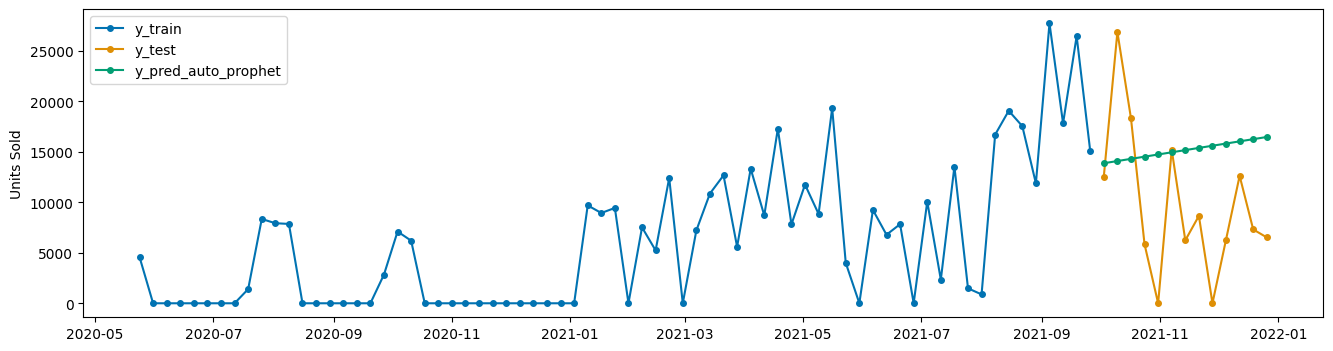

In [1964]:
# plot the forecast result
plot_series(y_train_sportsdirect, y_test_sportsdirect, y_pred_prophet_sportsdirect, labels=["y_train", "y_test", "y_pred_auto_prophet"]);

**Set New Index Type**

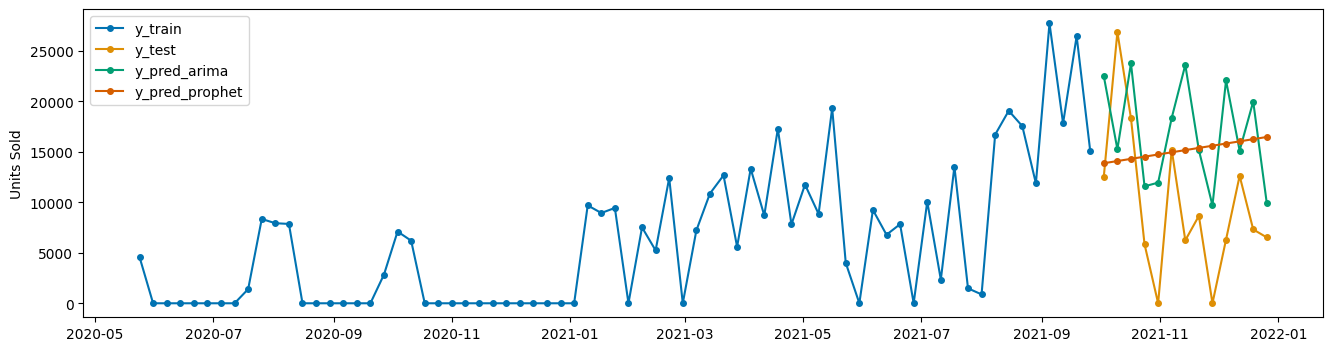

In [1965]:
# plot the forecast result
plot_series(
    y_train_sportsdirect, y_test_sportsdirect, y_pred_arima_sportsdirect, y_pred_prophet_sportsdirect,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet"]
);

In [1966]:
sportsdirect.value_counts

<bound method IndexOpsMixin.value_counts of Date
2020-05-24     4584
2020-05-31        0
2020-06-07        0
2020-06-14        0
2020-06-21        0
              ...  
2021-11-28        0
2021-12-05     6308
2021-12-12    12616
2021-12-19     7311
2021-12-26     6521
Freq: W-SUN, Name: Units Sold, Length: 84, dtype: int32>

### Model Diagnostics

**Plot Residuals**

In [1967]:
residuals = y_test_kohls - y_pred_prophet_kohls

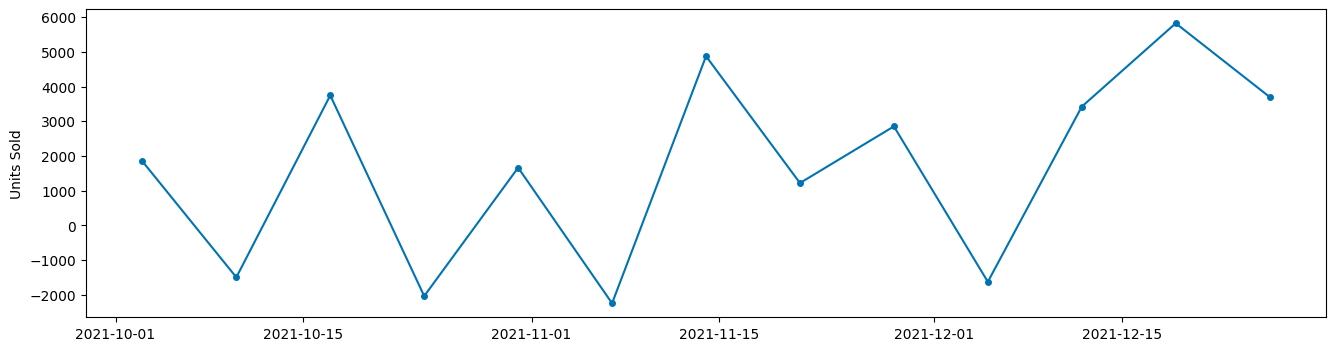

In [1968]:
plot_series(residuals);

**Normality of Residuals**

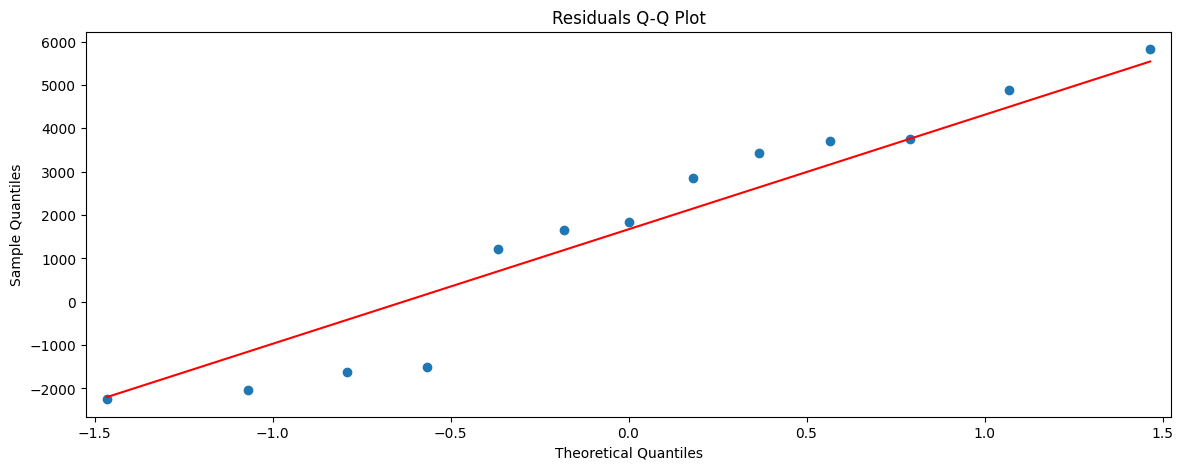

In [1969]:
sm.qqplot(residuals, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

**Random Walk Pattern of Residuals**

In [1970]:
residuals.describe()
residuals.head(10)

2021-10-03    1844.651575
2021-10-10   -1499.626932
2021-10-17    3746.094561
2021-10-24   -2041.183945
2021-10-31    1661.537548
2021-11-07   -2248.740959
2021-11-14    4875.980534
2021-11-21    1218.702028
2021-11-28    2852.423521
2021-12-05   -1629.854986
Freq: W-SUN, Name: Units Sold, dtype: float64

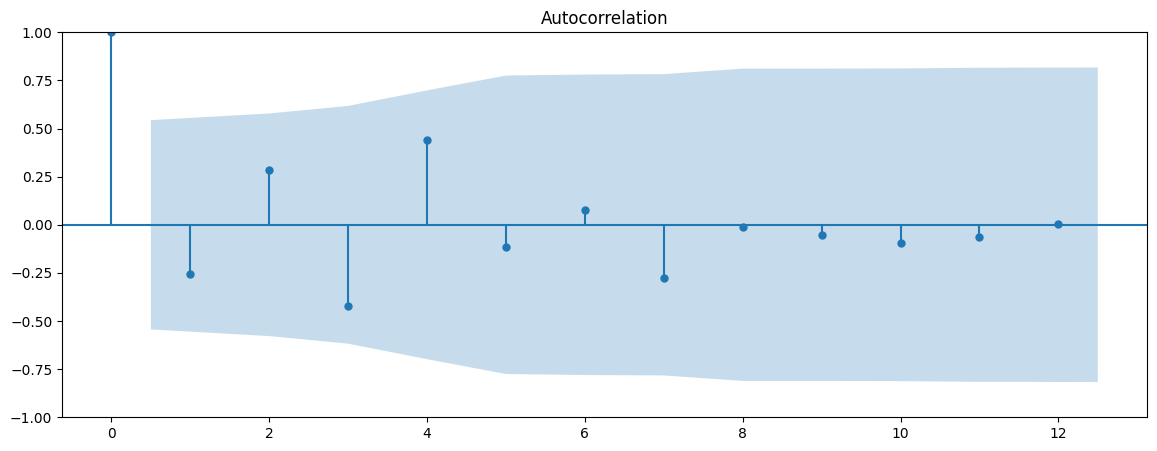

In [1971]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,  # harus Series, bukan DataFrame
    lags=12
).set_size_inches(14, 5)


### Model Evaluation

In [1972]:
mean_absolute_percentage_error(y_test_kohls, y_pred_prophet_kohls) * 100

1.3436648655405944e+20

### **Walmart**

### Modeling

**Re-Preprocess Data**

In [1973]:
# Set 'Date' sebagai index
walmart_df = walmart_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
walmart_df.index = pd.DatetimeIndex(walmart_df.index, freq='infer')

walmart = walmart_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original walmart
walmart = walmart.resample('W').sum()

**Train-Test Split**

In [1974]:
# Do train-test split
y_train_walmart, y_test_walmart = temporal_train_test_split(walmart, test_size=13)

#specific data points
fh_walmart = ForecastingHorizon(y_test_walmart.index, is_relative=False)

**Modeling**

In [1975]:
# define Prophet model
prophet_forecaster = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality = False,
    weekly_seasonality = True,
    daily_seasonality = False,
)

In [1976]:
# fit forecaster to data
prophet_forecaster.fit(y_train_walmart)

21:50:05 - cmdstanpy - INFO - Chain [1] start processing
21:50:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet(daily_seasonality=False, seasonality_mode='multiplicative',
        weekly_seasonality=True, yearly_seasonality=False)

In [1977]:
# do prediction based on forecast horizon we already defined
y_pred_prophet_walmart = prophet_forecaster.predict(fh=fh_walmart)

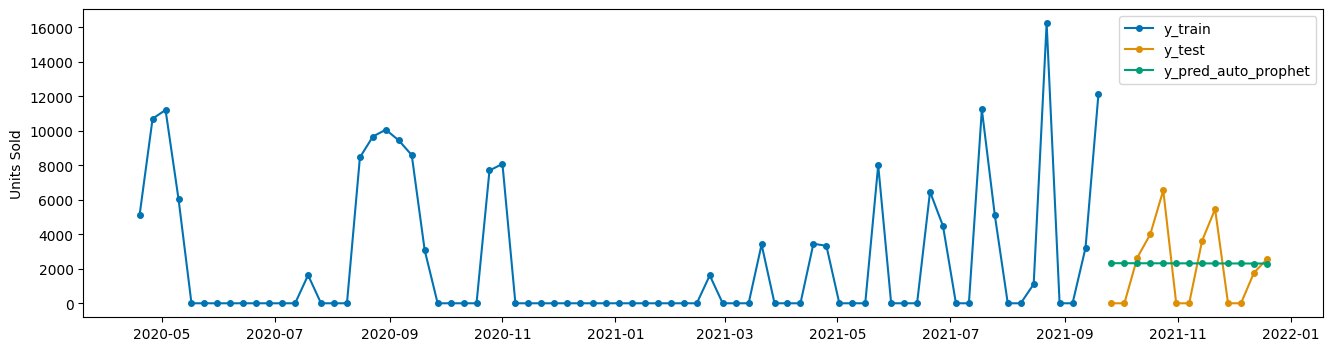

In [1978]:
# plot the forecast result
plot_series(y_train_walmart, y_test_walmart, y_pred_prophet_walmart, labels=["y_train", "y_test", "y_pred_auto_prophet"]);

**Set New Index Type**

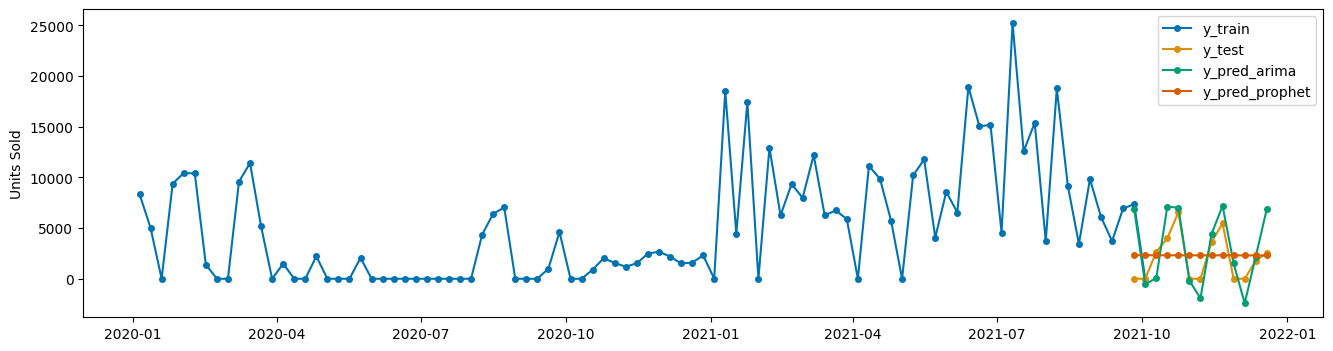

In [1979]:
# plot the forecast result
plot_series(
    y_train_fl, y_test_walmart, y_pred_arima_walmart, y_pred_prophet_walmart,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet"]
);

### Model Diagnostics

**Plot Residuals**

In [1980]:
residuals = y_test_walmart - y_pred_prophet_walmart

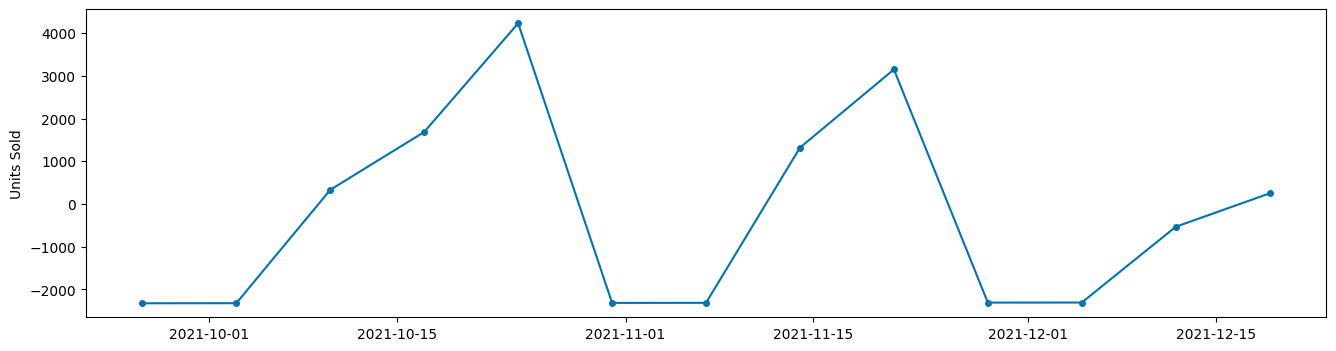

In [1981]:
plot_series(residuals);

**Normality of Residuals**

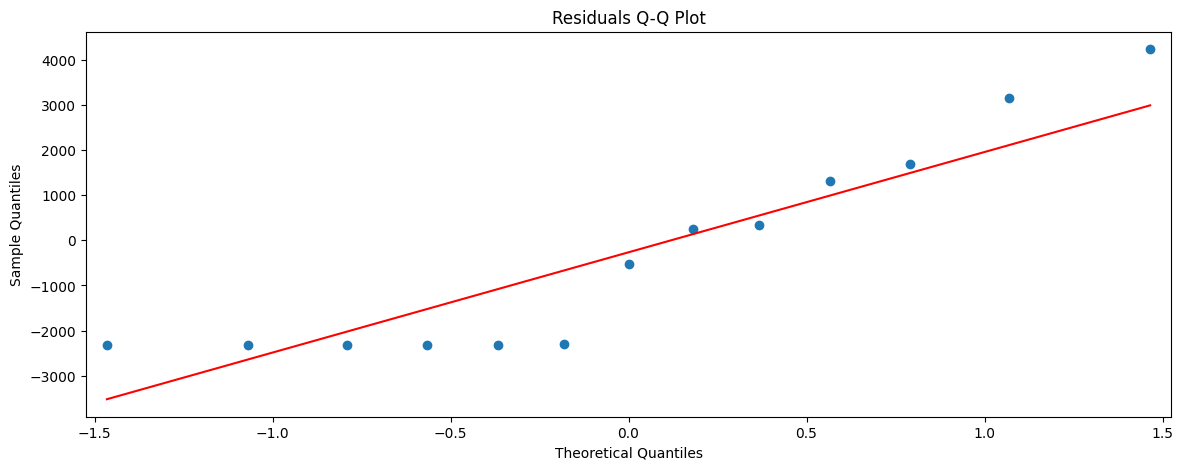

In [1982]:
sm.qqplot(residuals, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

**Random Walk Pattern of Residuals**

In [1983]:
residuals.describe()
residuals.head(10)


2021-09-26   -2324.432018
2021-10-03   -2322.678815
2021-10-10     331.074387
2021-10-17    1685.827589
2021-10-24    4229.580791
2021-10-31   -2315.666006
2021-11-07   -2313.912804
2021-11-14    1318.840398
2021-11-21    3148.593600
2021-11-28   -2308.653197
Freq: W-SUN, Name: Units Sold, dtype: float64

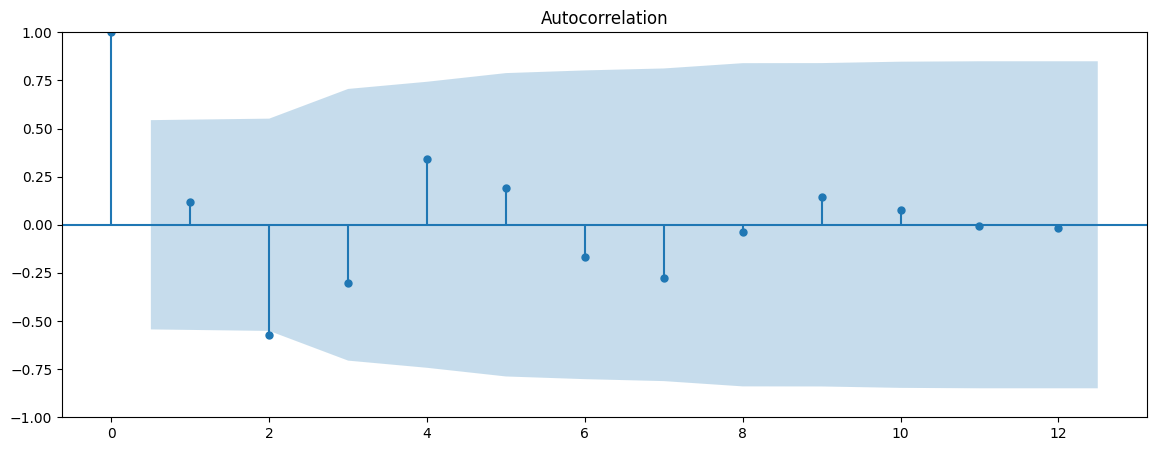

In [1984]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,  # harus Series, bukan DataFrame
    lags=12
).set_size_inches(14, 5)


### Model Evaluation

In [1985]:
mean_absolute_percentage_error(y_test_walmart, y_pred_prophet_walmart) * 100

4.8126999736924714e+20

### **West Gear**

In [1986]:
# Set 'Date' sebagai index
westgear_df = westgear_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
westgear_df.index = pd.DatetimeIndex(westgear_df.index, freq='infer')

westgear = westgear_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original westgear
westgear = westgear.resample('W').sum()

### Modeling

**Train-Test Split**

In [1987]:
# Do train-test split
y_train_westgear, y_test_westgear = temporal_train_test_split(westgear, test_size=13)

#specific data points
fh_westgear = ForecastingHorizon(y_test_westgear.index, is_relative=False)

**Modeling**

In [1988]:
# define Prophet model
prophet_forecaster = Prophet(
    seasonality_mode='additive',
    yearly_seasonality = False,
    weekly_seasonality = True,
    daily_seasonality = False,
)

In [1989]:
# fit forecaster to data
prophet_forecaster.fit(y_train_westgear)

21:50:06 - cmdstanpy - INFO - Chain [1] start processing
21:50:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet(daily_seasonality=False, weekly_seasonality=True,
        yearly_seasonality=False)

In [1990]:
# do prediction based on forecast horizon we already defined
y_pred_prophet_westgear = prophet_forecaster.predict(fh=fh_westgear)

**Set New Index Type**

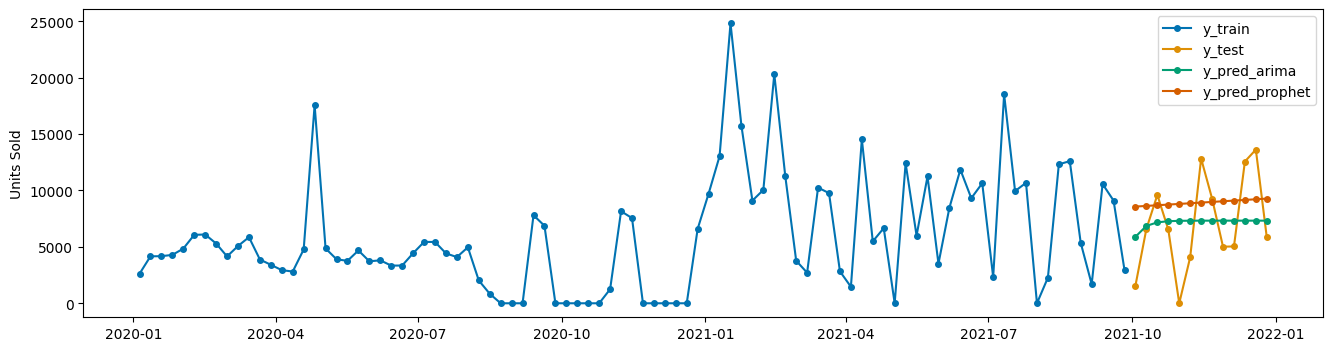

In [1991]:
# plot the forecast result
plot_series(
    y_train_westgear, y_test_westgear, y_pred_arima_westgear, y_pred_prophet_westgear,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet"]
);

### Model Diagnostics

**Plot Residuals**

In [1992]:
residuals = y_test_westgear - y_pred_prophet_westgear

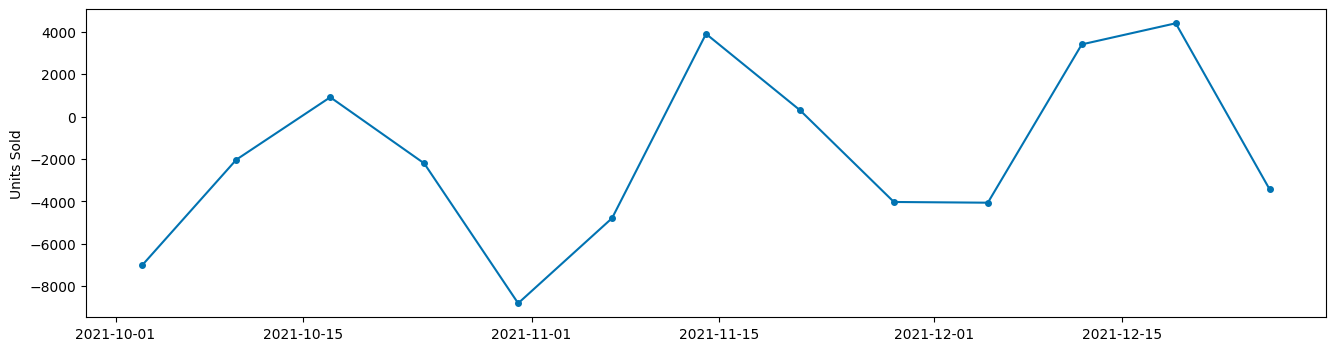

In [1993]:
plot_series(residuals);

**Normality of Residuals**

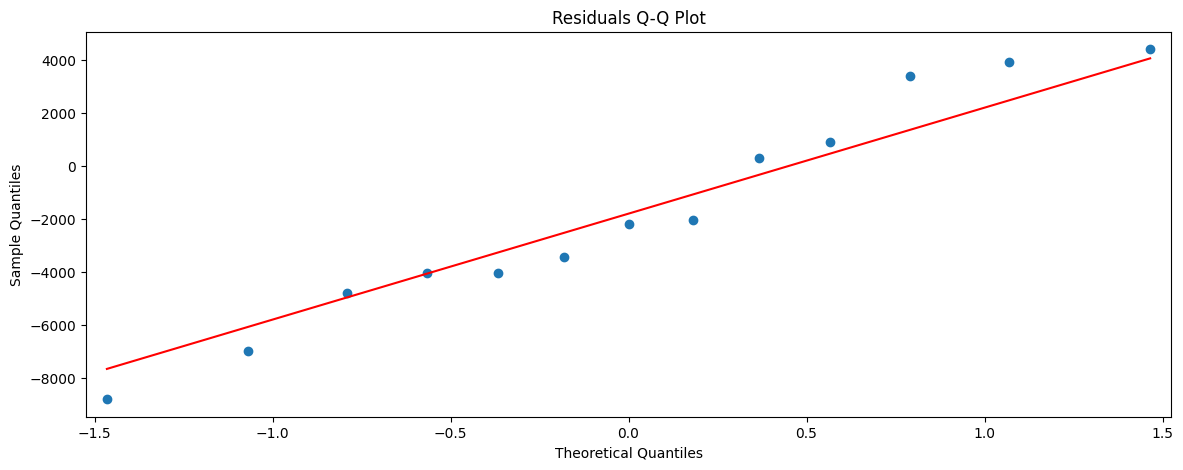

In [1994]:
sm.qqplot(residuals, line = 's').set_size_inches((14,5))
plt.title("Residuals Q-Q Plot")
plt.show()

**Random Walk Pattern of Residuals**

In [1995]:
residuals.describe()
residuals.head(10)

2021-10-03   -7002.788018
2021-10-10   -2032.687823
2021-10-17     913.412372
2021-10-24   -2208.487433
2021-10-31   -8808.387238
2021-11-07   -4791.287043
2021-11-14    3902.813153
2021-11-21     301.913348
2021-11-28   -4028.986457
2021-12-05   -4062.886262
Freq: W-SUN, Name: Units Sold, dtype: float64

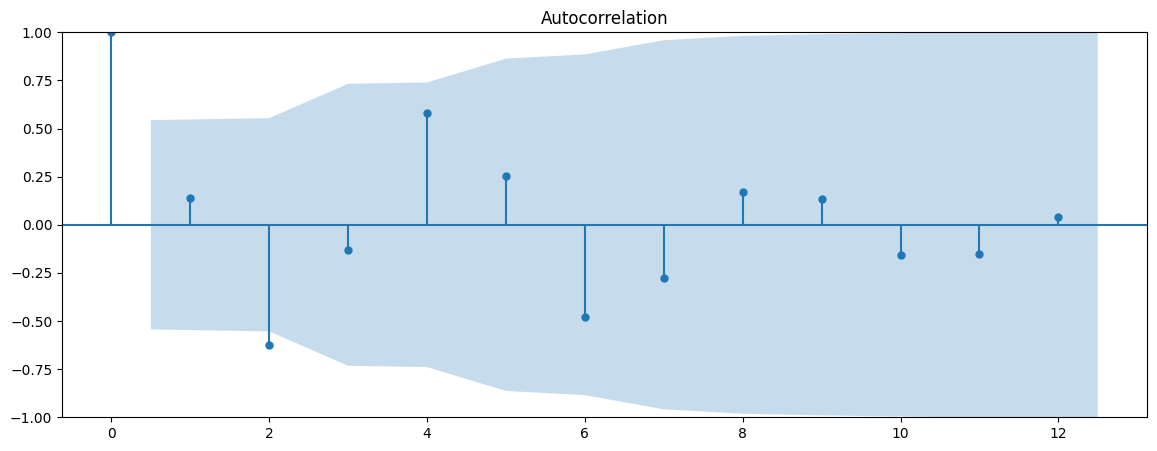

In [1996]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,  # harus Series, bukan DataFrame
    lags=12
).set_size_inches(14, 5)

### Model Evaluation

In [1997]:
mean_absolute_percentage_error(y_test_westgear, y_pred_prophet_westgear) * 100

3.051496113952098e+20

## **SARIMA**

In [1998]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

### **Foot Locker**

In [1999]:
# Daftar nama retailer
retailer_names = ["Foot Locker", "Amazon", "Kohl's", "Sports Direct", "Walmart", "West Gear"]

# Fungsi bantu untuk menambahkan kolom tanggal dan set index
def add_period_index(df):
    df['Year-Month_Day'] = df['year'].astype(str) + '-' + \
                           df['month'].astype(str).str.zfill(2) + '_' + \
                           df['day'].astype(str).str.zfill(2)
    df.set_index('Year-Month_Day', inplace=True)
    df.index = pd.PeriodIndex(df.index.str.replace('_', '-'), freq='D')
    return df

# Buat masing-masing DataFrame
footlocker_df = add_period_index(daily_df[daily_df["Retailer"] == "Foot Locker"].copy())
amazon_df = add_period_index(daily_df[daily_df["Retailer"] == "Amazon"].copy())
kohls_df = add_period_index(daily_df[daily_df["Retailer"] == "Kohl's"].copy())
sportsdirect_df = add_period_index(daily_df[daily_df["Retailer"] == "Sports Direct"].copy())
walmart_df = add_period_index(daily_df[daily_df["Retailer"] == "Walmart"].copy())
westgear_df = add_period_index(daily_df[daily_df["Retailer"] == "West Gear"].copy())

# Cek salah satu
footlocker_df.head()

,Retailer,year,month,day,Total Sales,Units Sold,Date
Year-Month_Day,,,,,,,
2020-01-01,Foot Locker,2020,1,1,845141.0,2361,2020-01-01
2020-01-02,Foot Locker,2020,1,2,523740.0,1580,2020-01-02
2020-01-03,Foot Locker,2020,1,3,420200.0,1600,2020-01-03
2020-01-04,Foot Locker,2020,1,4,402743.0,1378,2020-01-04
2020-01-05,Foot Locker,2020,1,5,566028.0,1440,2020-01-05


In [2000]:
# Set 'Date' sebagai index
footlocker_df = footlocker_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
footlocker_df.index = pd.DatetimeIndex(footlocker_df.index, freq='infer')

footlocker = footlocker_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original footlocker
footlocker = footlocker.resample('W').sum()

In [2001]:
# Do train-test split
y_train_fl, y_test_fl = temporal_train_test_split(footlocker, test_size=13)


In [2002]:
model = SARIMAX(y_train_fl,
                order=(1,1,1),                # p,d,q
                seasonal_order=(1,1,1,52),     # P,D,Q,s (weekly seasonality)
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit()

In [2003]:
y_pred_sarima_fl = sarima_result.get_forecast(steps=len(y_test_fl))
y_pred_sarima_mean_fl = y_pred_sarima_fl.predicted_mean
y_pred_sarima_ci_fl = y_pred_sarima_fl.conf_int()

In [2004]:
mae = mean_absolute_error(y_test_fl, y_pred_sarima_mean_fl)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 6,123.66


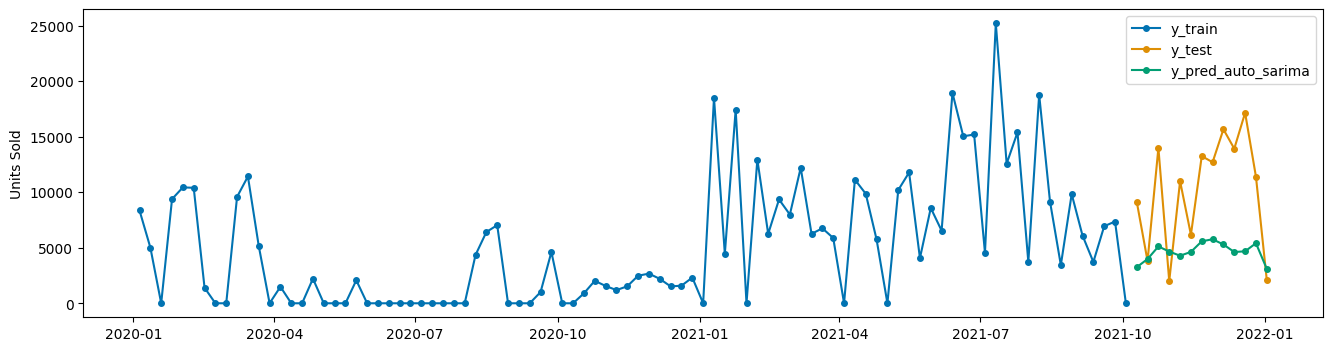

In [2005]:
# plot the forecast result
# Plot
plot_series(y_train_fl, y_test_fl, y_pred_sarima_mean_fl, labels=["y_train", "y_test", "y_pred_auto_sarima"]);

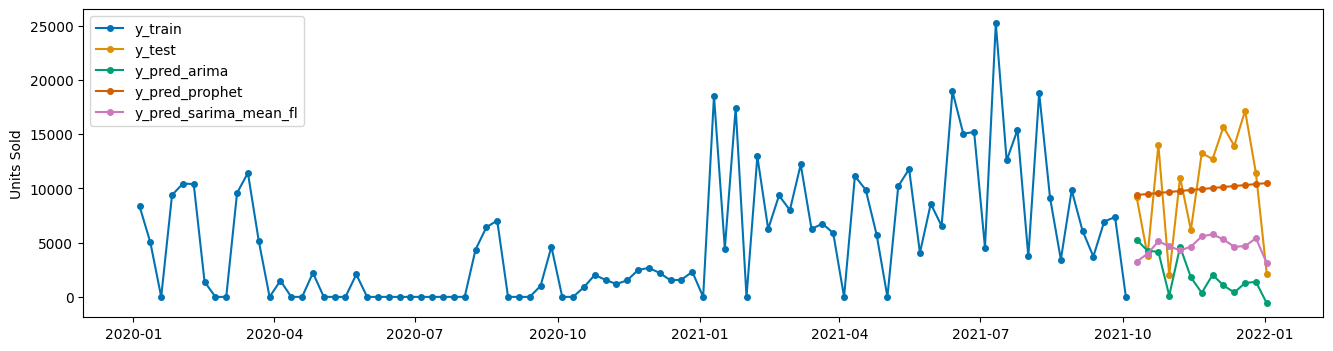

In [2006]:
# plot the forecast result
plot_series(
    y_train_fl, y_test_fl, y_pred_arima_fl, y_pred_prophet_fl,y_pred_sarima_mean_fl,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet","y_pred_sarima_mean_fl"]
);

In [2007]:
mean_absolute_percentage_error(y_test_fl, y_pred_sarima_mean_fl) * 100

59.264530462432695

### **Amazon**

In [2008]:
# Do train-test split
y_train_amazon, y_test_amazon = temporal_train_test_split(amazon, test_size=13)

In [2009]:
model = SARIMAX(y_train_amazon,
                order=(1,1,1),                # p,d,q
                seasonal_order=(1,1,1,52),     # P,D,Q,s (weekly seasonality)
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit()

In [2010]:
y_pred_sarima_amazon = sarima_result.get_forecast(steps=len(y_test_amazon))
y_pred_sarima_mean_amazon = y_pred_sarima_amazon.predicted_mean
y_pred_sarima_ci_amazon = y_pred_sarima_amazon.conf_int()

In [2011]:
mae = mean_absolute_error(y_test_amazon, y_pred_sarima_mean_amazon)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 4,524.15


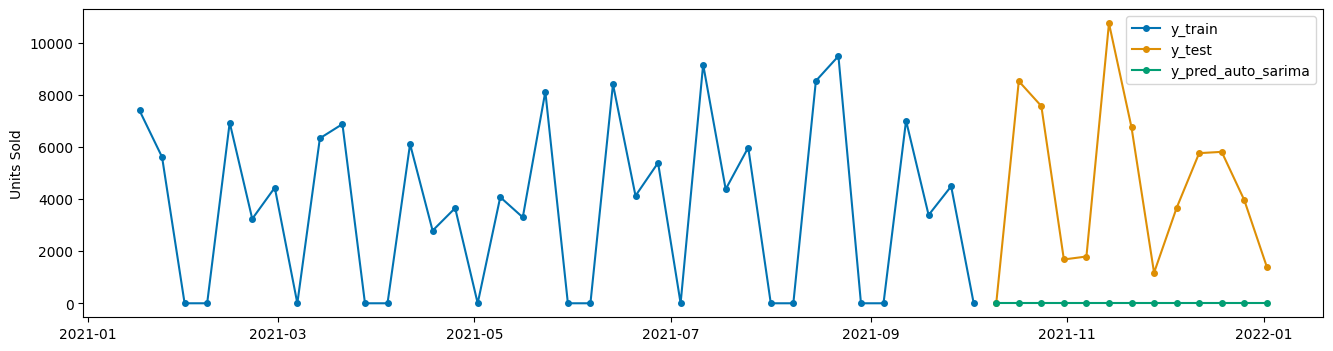

In [2012]:
# plot the forecast result
# Plot
plot_series(y_train_amazon, y_test_amazon, y_pred_sarima_mean_amazon, labels=["y_train", "y_test", "y_pred_auto_sarima"]);

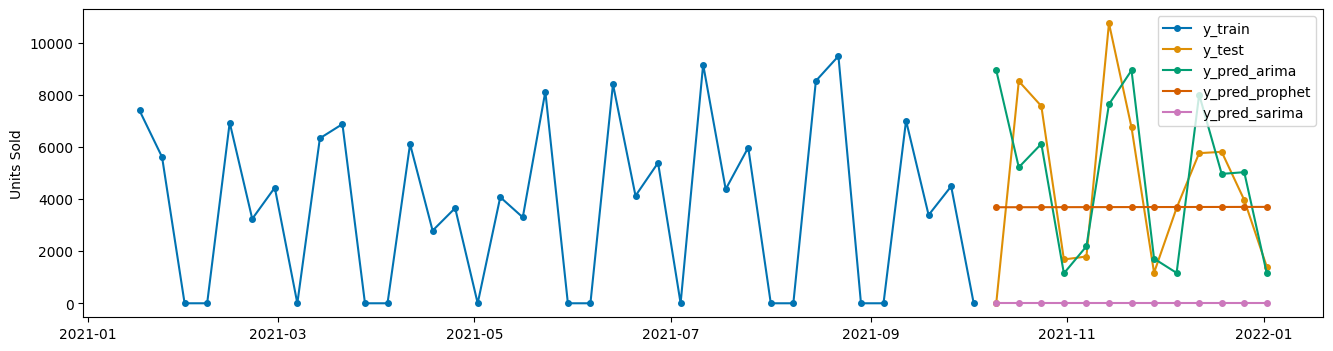

In [2013]:
# plot the forecast result
plot_series(
    y_train_amazon, y_test_amazon, y_pred_arima_amazon, y_pred_prophet_amazon,y_pred_sarima_mean_amazon,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet","y_pred_sarima"]
);

In [2014]:
mean_absolute_percentage_error(y_test_amazon, y_pred_sarima_mean_amazon) * 100

15846.153846153846

### **Kohl's**

In [2045]:
# Do train-test split
y_train_kohls, y_test_kohls = temporal_train_test_split(kohls, test_size=13)

In [2046]:
model = SARIMAX(y_train_kohls,
                order=(1,1,1),                # p,d,q
                seasonal_order=(1,1,1,52),     # P,D,Q,s (weekly seasonality)
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit()

In [2047]:
y_pred_sarima_kohls = sarima_result.get_forecast(steps=len(y_test_kohls))
y_pred_sarima_mean_kohls = y_pred_sarima_kohls.predicted_mean
y_pred_sarima_ci_kohls = y_pred_sarima_kohls.conf_int()

In [2048]:
mae = mean_absolute_error(y_test_kohls, y_pred_sarima_mean_kohls)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 3,765.38


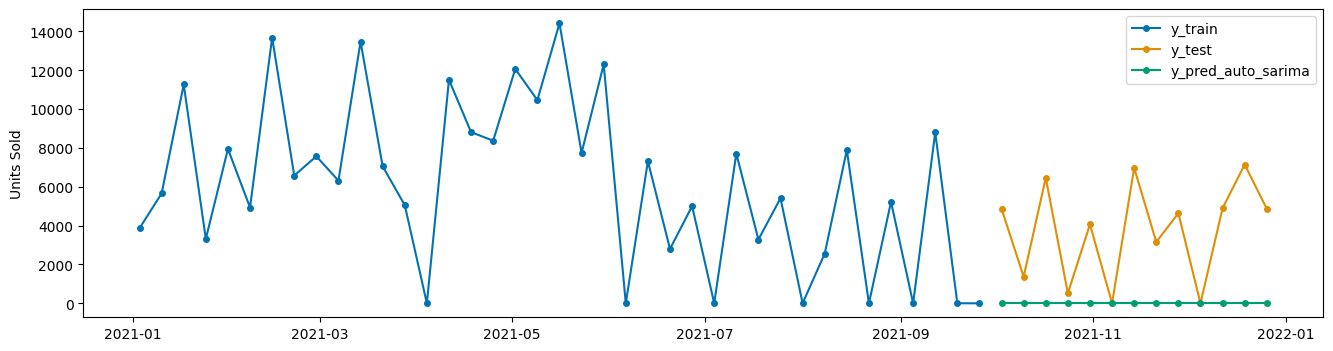

In [2049]:
# plot the forecast result
# Plot
plot_series(y_train_kohls, y_test_kohls, y_pred_sarima_mean_kohls, labels=["y_train", "y_test", "y_pred_auto_sarima"]);

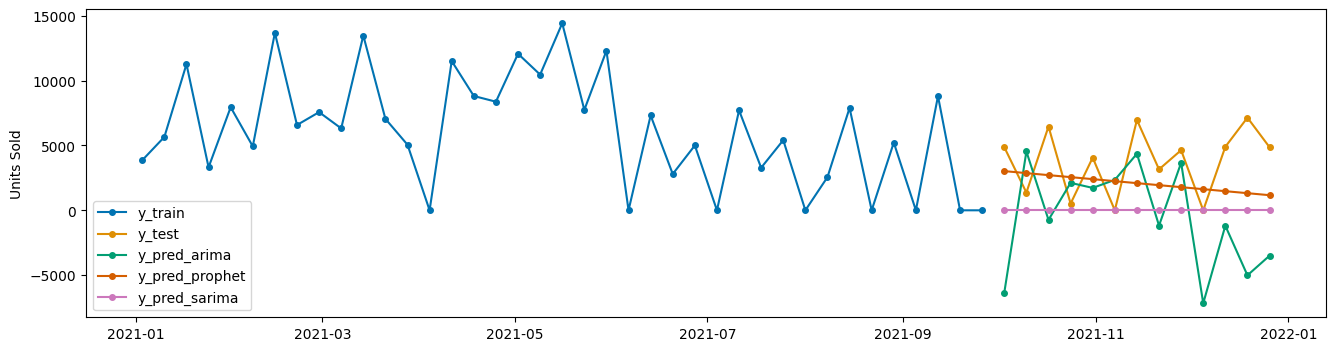

In [2053]:
# plot the forecast result
plot_series(
    y_train_kohls, y_test_kohls, y_pred_arima_kohls, y_pred_prophet_kohls,y_pred_sarima_mean_kohls,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet","y_pred_sarima"]
);

In [2054]:
mean_absolute_percentage_error(y_test_kohls, y_pred_sarima_mean_kohls) * 100

84.61538461538461

### **Sports Direct**

In [2022]:
# Set 'Date' sebagai index
sportsdirect_df = sportsdirect_df.set_index('Date')

# Pastikan indexnya bertipe datetime index dengan frekuensi otomatis (infer)
sportsdirect_df.index = pd.DatetimeIndex(sportsdirect_df.index, freq='infer')

sportsdirect = sportsdirect_df['Units Sold']  # ini akan menjadi Series numerik yang valid

# Replace original sportsdirect
sportsdirect = sportsdirect.resample('W').sum()

In [2023]:
sportsdirect_df_cut = sportsdirect[sportsdirect.index.year >= 2021]

In [2024]:
# Do train-test split
y_train_sportsdirect, y_test_sportsdirect = temporal_train_test_split(sportsdirect_df_cut, test_size=13)

In [2025]:
model = SARIMAX(y_train_sportsdirect,
                order=(1,1,1),                # p,d,q
                seasonal_order=(1,1,1,52),     # P,D,Q,s (weekly seasonality)
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit()

In [2026]:
y_pred_sarima_sportsdirect = sarima_result.get_forecast(steps=len(y_test_sportsdirect))
y_pred_sarima_mean_sportsdirect = y_pred_sarima_sportsdirect.predicted_mean
y_pred_sarima_ci_sportsdirect = y_pred_sarima_sportsdirect.conf_int()

In [2027]:
mae = mean_absolute_error(y_test_sportsdirect, y_pred_sarima_mean_sportsdirect)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 7,680.15


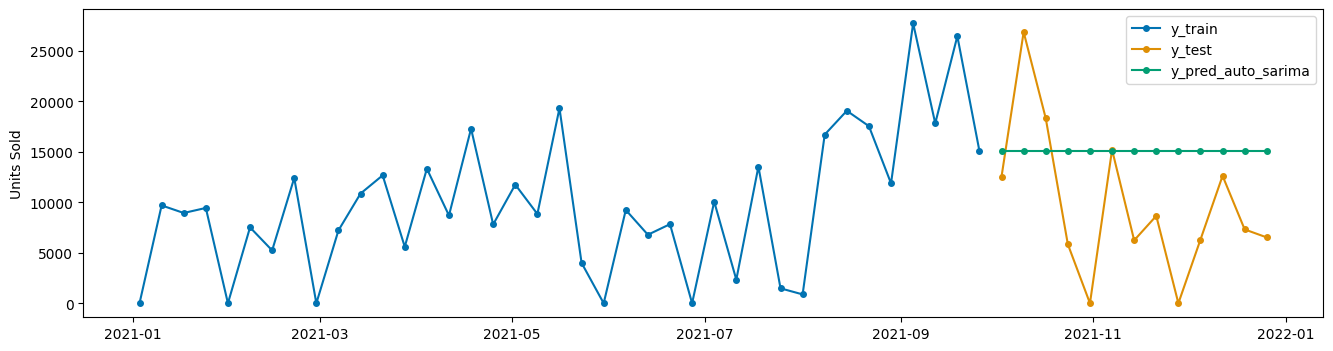

In [2028]:
# plot the forecast result
# Plot
plot_series(y_train_sportsdirect, y_test_sportsdirect, y_pred_sarima_mean_sportsdirect, labels=["y_train", "y_test", "y_pred_auto_sarima"]);

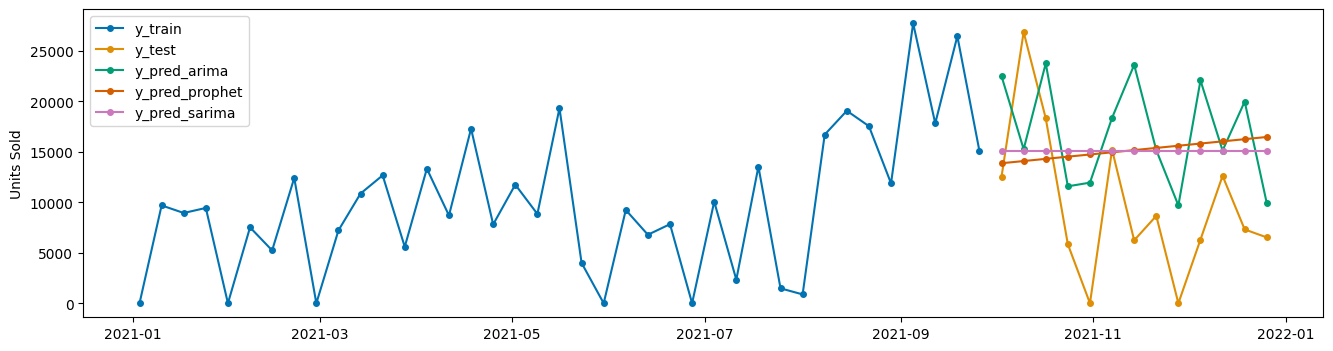

In [2029]:
# plot the forecast result
plot_series(
    y_train_sportsdirect, y_test_sportsdirect, y_pred_arima_sportsdirect, y_pred_prophet_sportsdirect,y_pred_sarima_mean_sportsdirect,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet","y_pred_sarima"]
);

In [2030]:
mean_absolute_percentage_error(y_test_sportsdirect, y_pred_sarima_mean_sportsdirect) * 100

1.0442115382169346e+21

### **Walmart**

In [2031]:
# Do train-test split
y_train_walmart, y_test_walmart = temporal_train_test_split(walmart, test_size=13)

In [2032]:
model = SARIMAX(y_train_walmart,
                order=(1,1,1),                # p,d,q
                seasonal_order=(1,1,1,52),     # P,D,Q,s (weekly seasonality)
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit()

In [2033]:
y_pred_sarima_walmart = sarima_result.get_forecast(steps=len(y_test_walmart))
y_pred_sarima_mean_walmart = y_pred_sarima_walmart.predicted_mean
y_pred_sarima_ci_walmart = y_pred_sarima_walmart.conf_int()

In [2034]:
mae = mean_absolute_error(y_test_walmart, y_pred_sarima_mean_walmart)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 15,822.24


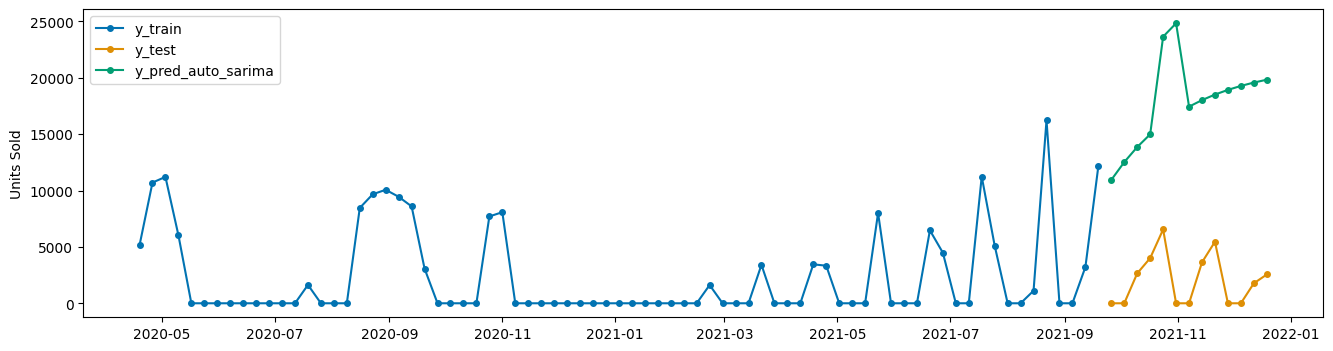

In [2035]:
# plot the forecast result
# Plot
plot_series(y_train_walmart, y_test_walmart, y_pred_sarima_mean_walmart, labels=["y_train", "y_test", "y_pred_auto_sarima"]);

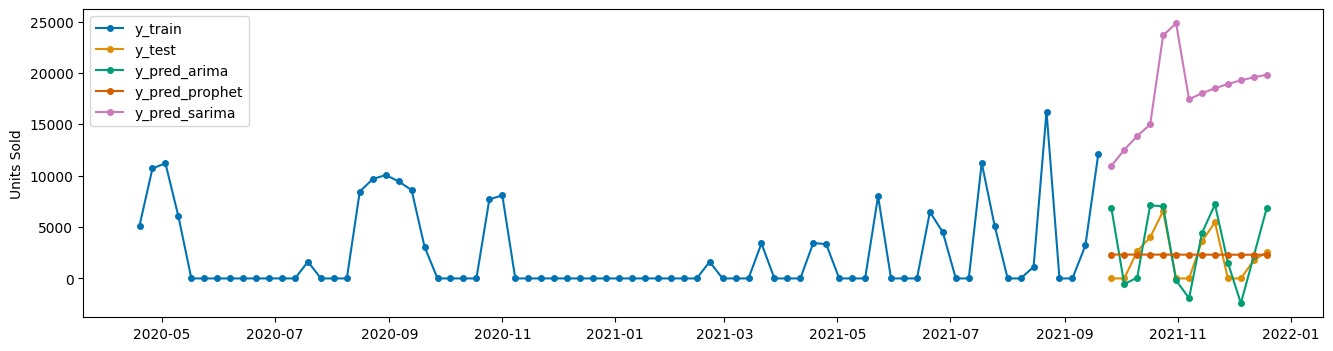

In [2036]:
# plot the forecast result
plot_series(
    y_train_walmart, y_test_walmart, y_pred_arima_walmart, y_pred_prophet_walmart,y_pred_sarima_mean_walmart,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet","y_pred_sarima"]
);

In [2037]:
mean_absolute_percentage_error(y_test_walmart, y_pred_sarima_mean_walmart) * 100

3.5999487692729913e+21

### **West Gear**

In [2038]:
# Do train-test split
y_train_westgear, y_test_westgear = temporal_train_test_split(westgear, test_size=13)

In [2039]:
model = SARIMAX(y_train_westgear,
                order=(1,1,1),                # p,d,q
                seasonal_order=(1,1,1,52),     # P,D,Q,s (weekly seasonality)
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_result = model.fit()

In [2040]:
y_pred_sarima_westgear = sarima_result.get_forecast(steps=len(y_test_westgear))
y_pred_sarima_mean_westgear = y_pred_sarima_westgear.predicted_mean
y_pred_sarima_ci_westgear = y_pred_sarima_westgear.conf_int()

In [2041]:
mae = mean_absolute_error(y_test_westgear, y_pred_sarima_mean_westgear)
print(f"Mean Absolute Error (MAE): {mae:,.2f}")

Mean Absolute Error (MAE): 5,271.55


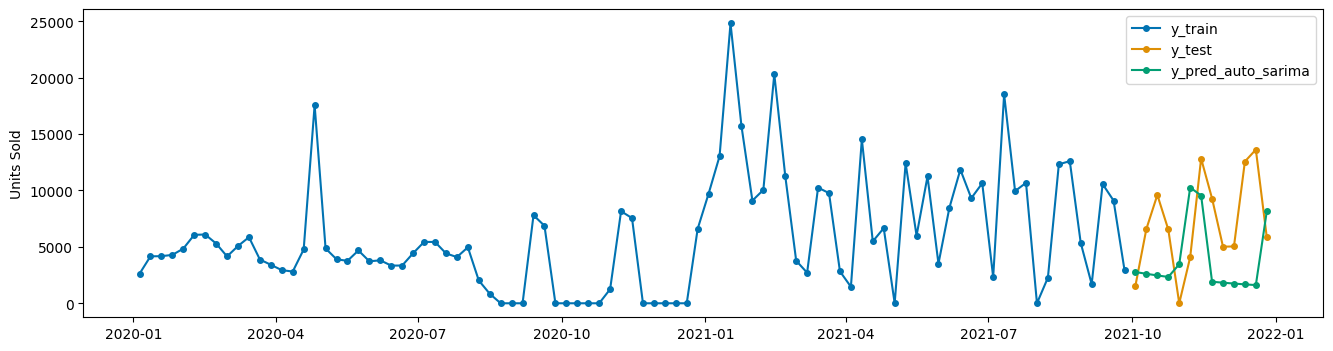

In [2042]:
# plot the forecast result
# Plot
plot_series(y_train_westgear, y_test_westgear, y_pred_sarima_mean_westgear, labels=["y_train", "y_test", "y_pred_auto_sarima"]);

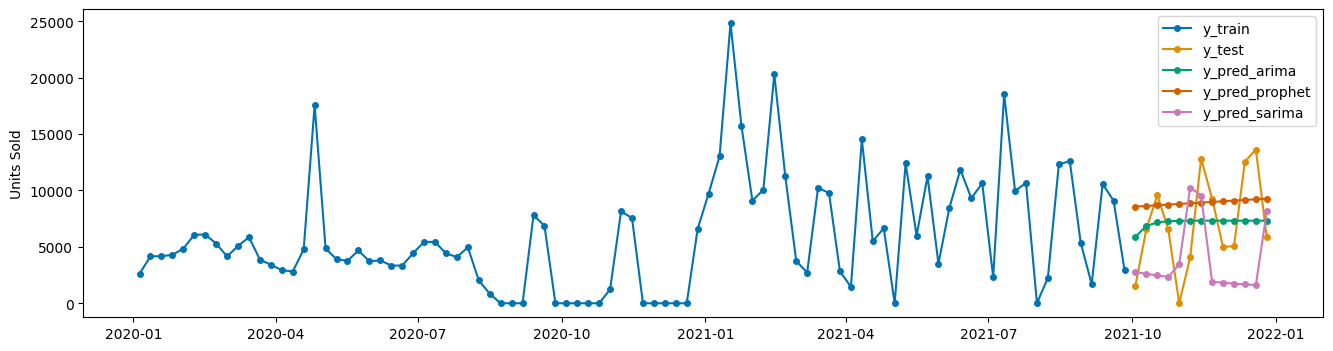

In [2043]:
# plot the forecast result
plot_series(
    y_train_westgear, y_test_westgear, y_pred_arima_westgear, y_pred_prophet_westgear,y_pred_sarima_mean_westgear,
    labels=["y_train", "y_test", "y_pred_arima", "y_pred_prophet","y_pred_sarima"]
);

In [2044]:
mean_absolute_percentage_error(y_test_westgear, y_pred_sarima_mean_westgear) * 100

1.1993769792655778e+20